<a href="https://colab.research.google.com/github/Qalani/Dissertation/blob/main/Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Winam Gulf full-stack WH classifier workflow: spatial CV, batch GeoTIFF classification, and area time series

This notebook trains/selects the Route B classifiers using spatial block cross-validation, then runs a **post-export full-stack workflow** over all Sentinel predictor GeoTIFFs already exported to Google Drive.

## Core workflow

1. **Train or load S2 and S1/SCC classifiers.** The training section uses spatial block cross-validation with repeated splits, tie-aware production-model selection, saved model bundles, and probability-raster support.
2. **Discover exported imagery automatically.** The batch section points at the validated snapshot folder produced by `Batch_Export.ipynb` (`GEE_Exports_validated_snapshots`) and scans for every exported predictor GeoTIFF matching that notebook's single-date naming pattern, including tiled Earth Engine shards.
3. **Validate and group exports by sensor/date window.** Tiled shards are grouped as one date-window dataset; Google Drive duplicate-collision files such as `file (1).tif` are rejected by default to avoid double counting, and the run manifest from `Batch_Export.ipynb` is used to annotate inventory rows when present.
4. **Classify every valid date window locally.** For each S2 and S1/SCC predictor dataset, the selected model is applied block-by-block, optional probability rasters are written, and the corresponding paper-rule classification is also generated.
5. **Calculate WH/floating-plant area through time.** The workflow outputs per-class area tables, floating-class time series, confidence-thresholded area tables, inventory/QA logs, summary statistics, quicklook PNGs, and time-series figures.

## Main outputs

Outputs are written under:

`/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/`

Important files include:

- `winam_full_stack_area_by_class_all_dates_<version>.csv`
- `winam_full_stack_floating_area_timeseries_<version>.csv`
- `winam_full_stack_confidence_area_all_dates_<version>.csv`
- `winam_full_stack_export_inventory_<version>.csv`
- `winam_full_stack_run_log_<version>.csv`
- `figures/winam_full_stack_floating_area_timeseries_<version>.png`
- `classified_geotiffs/` containing model, probability, and rule-classification GeoTIFFs
- `quicklooks/` containing lightweight classification PNGs

## Recommended use

For a normal post-export run, leave:

```python
RUN_SINGLE_PERIOD_WORKFLOW = False
RUN_BATCH_POST_EXPORT_WORKFLOW = True
```

That mode does **not** start Earth Engine predictor exports. It loads the validated single-date snapshot predictor GeoTIFFs already created by `Batch_Export.ipynb` in `/content/drive/MyDrive/GEE_Exports_validated_snapshots` and processes them end-to-end, writing only local classified rasters, tables, figures, and quicklooks.


## 1. Google Drive, Earth Engine, AOI, and top-level options

In [1]:
%%capture
!pip install earthengine-api geemap pandas numpy scikit-learn rasterio scipy joblib matplotlib geopandas pyogrio

In [2]:
import json
import os
import re
import shutil
import urllib.request
from contextlib import ExitStack, contextmanager
from pathlib import Path
from uuid import uuid4

import ee
import geemap
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from scipy import ndimage
from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
    cohen_kappa_score,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from rasterio.merge import merge
from rasterio.windows import Window
import rasterio.features
from rasterio.warp import transform_geom

# Bound GDAL's block cache. By default GDAL sizes its cache as a fraction of
# total RAM, which on a high-RAM Colab runtime is several GB. Streaming large,
# striped Earth Engine predictor GeoTIFFs block-by-block can then keep whole
# full-width strips cached and push peak memory past even a high-RAM runtime.
# A modest fixed cap keeps block I/O streaming without letting the cache grow
# unbounded. Set GDAL_CACHEMAX in the environment beforehand to override.
os.environ.setdefault('GDAL_CACHEMAX', '512MB')

'512MB'

In [3]:
from google.colab import drive
# Force a fresh Drive FUSE mount. This avoids stale Colab endpoints that can
# still let some Drive files read while writes fail with Errno 107.
drive.mount('/content/drive', force_remount=True)


def _is_transport_endpoint_error(exc):
    """Return True for Colab/Drive stale FUSE endpoint errors.

    Errno 107 can be wrapped by helper functions, so inspect the exception,
    its message, and chained causes/contexts before deciding whether fallback
    handling should run.
    """
    seen = set()
    current = exc
    while isinstance(current, BaseException) and id(current) not in seen:
        seen.add(id(current))
        message = str(current)
        if (
            isinstance(current, OSError)
            and (
                getattr(current, 'errno', None) == 107
                or 'Transport endpoint is not connected' in message
                or 'Drive FUSE endpoint is stale' in message
            )
        ):
            return True
        current = getattr(current, '__cause__', None) or getattr(current, '__context__', None)
    return False


def _remount_drive(mount_point='/content/drive'):
    """Force-remount Google Drive to recover from a stale Colab FUSE endpoint.

    Colab sometimes drops the Drive FUSE mount mid-run, after which Drive paths
    raise OSError Errno 107. A force-remount re-establishes the endpoint without
    re-prompting for authorization within the same session. Returns True if the
    remount was attempted, or False when the Colab drive helper is unavailable
    (for example when not running in Colab) so callers can decide whether
    recovery is possible.
    """
    try:
        drive.mount(mount_point, force_remount=True)
        return True
    except Exception as exc:
        print(f'Google Drive force-remount failed ({type(exc).__name__}: {exc}).')
        return False


# ---------------------------------------------------------------------
# Local raster staging: keep heavy GeoTIFF block I/O off the Drive FUSE mount.
#
# Google Drive's Colab FUSE driver is built for sequential, whole-file access,
# not the sustained random-access reads/writes that rasterio/GDAL issue while
# streaming a tiled, compressed (Big)GeoTIFF block-by-block. Doing that directly
# against /content/drive is what makes the Drive endpoint go stale
# (OSError Errno 107 / "Transport endpoint is not connected") and previously
# forced near-constant force-remounts. Instead we stage on local /content:
#   * reads  -> copy the Drive file to /content once (a single sequential read
#               the FUSE layer handles well), then open the local copy for block I/O;
#   * writes -> build the GeoTIFF on /content, then copy the finished file to Drive once.
# Only whole-file copies, directory listings and small CSV/PNG writes still touch
# Drive, so the FUSE endpoint stays healthy and remounts become rare.
# ---------------------------------------------------------------------
_DRIVE_MOUNT_ROOT = Path('/content/drive')
LOCAL_RASTER_SCRATCH_DIR = Path('/content/winam_local_raster_scratch')


def _path_is_on_drive(path):
    """Return True when ``path`` lives under the Colab Google Drive FUSE mount."""
    candidate = Path(path).expanduser()
    if not candidate.is_absolute():
        candidate = Path('/content') / candidate
    try:
        candidate.relative_to(_DRIVE_MOUNT_ROOT)
        return True
    except ValueError:
        return False


def _local_scratch_path(name):
    """Return a unique scratch path on fast, local /content storage."""
    LOCAL_RASTER_SCRATCH_DIR.mkdir(parents=True, exist_ok=True)
    return LOCAL_RASTER_SCRATCH_DIR / f'{uuid4().hex}_{Path(name).name}'


def _copy_whole_file_through_drive(source, dest, context):
    """Whole-file copy that force-remounts and retries on a stale Drive endpoint.

    A single sequential copy is the access pattern Drive's FUSE layer handles
    reliably (unlike block-by-block rasterio I/O), so this is used both to stage
    Drive inputs onto /content and to publish finished /content outputs to Drive.
    """
    source = Path(source)
    dest = Path(dest)

    def _do_copy():
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copyfile(source, dest)
        return dest

    runner = globals().get('_run_with_drive_remount_retry')
    if runner is not None:
        return runner(_do_copy, context=context)
    # Fallback if a copy ever runs before the batch helpers are defined.
    try:
        return _do_copy()
    except Exception as exc:
        if not _is_transport_endpoint_error(exc):
            raise
        _remount_drive()
        return _do_copy()


def _safe_remove(path):
    try:
        Path(path).unlink(missing_ok=True)
    except OSError:
        pass


# Per-dataset cache of staged Drive rasters (drive path -> local copy). While
# active, each raster is copied across the FUSE mount only once: outputs are
# still published to Drive the moment they are written, and the later
# area/confidence/quicklook passes reuse the local copy instead of re-reading it
# from Drive. The cache is scoped to a single dataset, so a runtime disconnect
# still loses at most the dataset in progress and every completed dataset stays
# on Drive for resume.
_DRIVE_STAGE_CACHE = None


@contextmanager
def drive_stage_cache():
    """Activate a per-dataset local cache of staged Drive rasters."""
    global _DRIVE_STAGE_CACHE
    if _DRIVE_STAGE_CACHE is not None:
        # Already inside a cache scope; reuse it rather than nesting a new one.
        yield _DRIVE_STAGE_CACHE
        return
    _DRIVE_STAGE_CACHE = {}
    try:
        yield _DRIVE_STAGE_CACHE
    finally:
        cache, _DRIVE_STAGE_CACHE = _DRIVE_STAGE_CACHE, None
        for local in cache.values():
            _safe_remove(local)



@contextmanager
def staged_drive_read(path):
    """Yield a locally-readable path for ``path``.

    Drive paths are copied to local scratch first (one sequential read) and the
    local copy is opened for block I/O. Non-Drive paths are yielded unchanged, so
    this is safe to wrap around every raster read. Inside a ``drive_stage_cache``
    scope the copy is reused for the rest of the dataset and freed with the cache;
    otherwise it is removed as soon as the read finishes.
    """
    path = Path(path)
    if not _path_is_on_drive(path):
        yield path
        return
    cache = _DRIVE_STAGE_CACHE
    key = str(path)
    if cache is not None and key in cache and Path(cache[key]).exists():
        yield cache[key]
        return
    local = _local_scratch_path(path.name)
    try:
        _copy_whole_file_through_drive(path, local, context=f'staging {path.name} for reading')
    except Exception:
        _safe_remove(local)
        raise
    keep = False
    try:
        if cache is not None:
            cache[key] = local
            keep = True
        yield local
    finally:
        if not keep:
            _safe_remove(local)


@contextmanager
def staged_drive_write(path):
    """Yield a local path to write ``path`` to, publishing it to Drive on success.

    Building the GeoTIFF on local /content and copying the finished file to Drive
    once keeps block-by-block write I/O off the FUSE mount. Non-Drive targets are
    written in place. The Drive copy happens only on a clean exit, so a failed
    write never leaves a half-written file on Drive. Inside a ``drive_stage_cache``
    scope the published copy is also kept locally so later reads of the same
    output in this dataset reuse it instead of downloading it again.
    """
    path = Path(path)
    if not _path_is_on_drive(path):
        _ensure_writable_dir(path.parent, 'output folder')
        yield path
        return
    cache = _DRIVE_STAGE_CACHE
    local = _local_scratch_path(path.name)
    keep = False
    try:
        yield local
        if Path(local).exists():
            _copy_whole_file_through_drive(local, path, context=f'writing {path.name}')
            if cache is not None:
                previous = cache.get(str(path))
                if previous is not None and previous != local:
                    _safe_remove(previous)
                cache[str(path)] = local
                keep = True
    finally:
        if not keep:
            _safe_remove(local)


def _ensure_writable_dir(path, label='folder'):
    """Create a directory and verify that pandas/rasterio can write there."""
    path = Path(path)
    try:
        path.mkdir(parents=True, exist_ok=True)
        probe = path / '.winam_write_probe'
        probe.write_text('ok', encoding='utf-8')
        probe.unlink(missing_ok=True)
    except OSError as exc:
        if _is_transport_endpoint_error(exc):
            raise OSError(
                f"Colab cannot write to the {label} at {path} because that Drive FUSE endpoint is stale. "
                "Re-run the setup cell to force-remount Drive, or let the batch workflow fall back to /content."
            ) from exc
        raise
    return path

DRIVE_ROOT = Path('/content/drive/MyDrive/Winam_RF_Training_Data')
S2_CSV = DRIVE_ROOT / 'SV_S2_Training.csv'
S1_CSV = DRIVE_ROOT / 'SV_S1_Training.csv'

LOCAL_OUTPUT_DIR = _ensure_writable_dir(DRIVE_ROOT / 'outputs', 'main output folder')
LOCAL_MODEL_DIR = _ensure_writable_dir(DRIVE_ROOT / 'models', 'model folder')

# Match the default output folder produced by Batch_Export.ipynb.
EE_EXPORT_FOLDER = 'GEE_Exports_validated_snapshots'
GEE_EXPORT_DIR = Path('/content/drive/MyDrive') / EE_EXPORT_FOLDER
BATCH_EXPORT_RUN_MANIFEST_PATH = GEE_EXPORT_DIR / 'winam_snapshot_validated_predictor_manifest.csv'
BATCH_EXPORT_PLANNED_MANIFEST_PATH = GEE_EXPORT_DIR / 'winam_snapshot_validated_predictor_planned_rows.csv'
EE_PROJECT = 'ee-bmillwardsadler1'

ee.Authenticate()
ee.Initialize(project=EE_PROJECT)

# Study AOI. The western edge is set to lon 34.2046673170698 (lining up
# with the point lat/lon -0.41757704207237595, 34.2046673170698) so the
# open-lake south-west arm is dropped and the AOI focuses on the gulf.
winam = ee.Geometry.Rectangle([34.2046673170698, -0.55, 34.9, 0], geodesic=False)

# Classification/input-raster settings. Predictor exports are handled only by Batch_Export.ipynb.
PREDICTOR_NODATA_VALUE = -9999.0
NODATA_VALUE = 255
FLOATING_CLASS_CODE = 2


# Full-stack post-export workflow settings.
# The single-period workflow is kept as an optional diagnostic path.
RUN_SINGLE_PERIOD_WORKFLOW = False
RUN_BATCH_POST_EXPORT_WORKFLOW = True

# Both Drive reads (predictor GeoTIFFs) and Drive writes (all batch outputs) are
# kept on Google Drive. A stale Colab Drive FUSE endpoint (Errno 107 /
# "Transport endpoint is not connected") can make Drive fail mid-run; instead of
# marking files invalid or diverting outputs to ephemeral /content storage, the
# batch workflow force-remounts Drive and retries. This caps how many automatic
# remounts a single batch run will attempt; scanning a large archive can hit a
# stale endpoint several times, so the budget is generous.
BATCH_MAX_DRIVE_REMOUNTS = 25

BATCH_OUTPUT_DIR = LOCAL_OUTPUT_DIR / 'full_stack_batch'
BATCH_CLASSIFIED_DIR = BATCH_OUTPUT_DIR / 'classified_geotiffs'
BATCH_TABLE_DIR = BATCH_OUTPUT_DIR / 'tables'
BATCH_FIGURE_DIR = BATCH_OUTPUT_DIR / 'figures'
BATCH_QUICKLOOK_DIR = BATCH_OUTPUT_DIR / 'quicklooks'
# Always create the batch output folders on Google Drive. If Drive's FUSE mount
# is stale at setup, fail loudly here rather than silently writing to ephemeral
# /content storage; the batch workflow additionally force-remounts Drive and
# retries mid-run so that every output is written to Drive.
for _batch_dir in [BATCH_OUTPUT_DIR, BATCH_CLASSIFIED_DIR, BATCH_TABLE_DIR, BATCH_FIGURE_DIR, BATCH_QUICKLOOK_DIR]:
    _ensure_writable_dir(_batch_dir, 'batch output folder')

# Batch filtering. Use None to process everything found.
BATCH_SENSOR_FILTER = ['S2']       # None, ['S2'], ['S1'], or ['S2', 'S1']
BATCH_START_DATE = None          # e.g. '2018-01-01'
BATCH_END_DATE = None            # e.g. '2025-12-31'
BATCH_MAX_DATASETS = None        # set an integer for a smoke test, e.g. 3

# Batch execution behaviour.
# When present, read Batch_Export.ipynb's run manifest to annotate the export inventory
# with coverage QA/status fields from the export notebook. Classification still uses
# the GeoTIFFs that actually exist in GEE_EXPORT_DIR, so stale queued statuses do not
# hide completed Drive files.
USE_BATCH_EXPORT_RUN_MANIFEST = True
BATCH_OVERWRITE_EXISTING = True
# When True, datasets whose per-dataset area CSV already exists on Drive are
# skipped and their prior results loaded directly. Enables clean resume after
# a disconnection without re-reading classification TIFs or recomputing area
# tables. Set to False to recompute area tables even when the CSVs exist.
BATCH_SKIP_COMPLETED = True
BATCH_STOP_ON_ERROR = False
BATCH_WRITE_QUICKLOOKS = True
BATCH_VALIDATION_MODE = 'first_block'  # 'first_block' is much faster than all-block validation for large archives
# Fixed window size (pixels) for streaming predictor reads during classification.
# Earth Engine GeoTIFFs are often striped so a single native block is the whole
# image; reading that at once can exhaust even a high-RAM runtime. Reading in
# fixed-size tiles caps peak RAM. S2 has a 16-band predictor stack, so keep the
# default conservative; set to 256 if Colab still runs out of memory, or 0/None
# to restore whole-image/native-block reads.
PREDICTOR_READ_BLOCKSIZE = 512
# Hard cap on pixels read per streaming window. Predictor reads are issued as
# full-width strips (see _iter_fixed_windows); this bounds peak RAM per read at
# roughly PREDICTOR_READ_MAX_PIXELS * bands * 4 bytes no matter how wide the
# scene is. Lower it if Colab still runs out of memory.
PREDICTOR_READ_MAX_PIXELS = 8_000_000
BATCH_SUMMARY_ROLLING_WINDOW = 3       # number of observations for rolling median summary

# Local classifier settings.
USE_SAVED_LOCAL_CLASSIFIERS = False
SAVE_LOCAL_CLASSIFIERS = True
SAVE_CLASSIFIER_METADATA = True

# Model selection metric. 'floating_f1' is usually the most relevant for hyacinth/floating-plant work.
# Other valid choices: 'kappa', 'macro_f1', 'weighted_f1', 'accuracy', 'balanced_accuracy'.
MODEL_SELECTION_METRIC = 'floating_f1'
USE_SELECTED_MODEL_FOR_RASTER_CLASSIFICATION = True

# Spatial block cross-validation settings.
# Spatial blocks group nearby training points together. Grouped k-fold CV then ensures
# that the test fold never contains points from the same block as the train fold, which
# breaks the auto-correlation leakage that inflates random-split scores.
SPATIAL_BLOCK_DEGREES = 0.1   # ~11 km at the equator. Tune in 1c if needed.
SPATIAL_CV_N_SPLITS = 5
SPATIAL_CV_N_REPEATS = 10     # repeated shuffles for variance estimates
SPATIAL_CV_RANDOM_STATE = 42
ALSO_RUN_RANDOM_CV_FOR_COMPARISON = True   # keep the i.i.d. random split as a diagnostic

# Tie-aware production model selection.
# A "tie" is defined as: mean(metric) within TIE_TOLERANCE_STD * std(metric_of_leader) of the leader.
# Among tied models, the simplest in PRODUCTION_PARSIMONY_ORDER is chosen.
TIE_TOLERANCE_STD = 1.0
PRODUCTION_PARSIMONY_ORDER = [
    'Logistic Regression baseline',
    'Random Forest',
    'Class-weighted RF',
    'Hist Gradient Boosting',
    'Gradient Boosting',
    'Extra Trees',
    'RBF SVM',
]
# Toggle: check/compare all candidate classifiers, or restrict to Logistic Regression only.
#   True  -> the spatial-CV step evaluates the full candidate set (Random Forest,
#            Class-weighted RF, Extra Trees, Gradient Boosting, Hist Gradient
#            Boosting and Logistic Regression) and any of them may be selected as
#            the production raster classifier.
#   False -> only Logistic Regression is trained/evaluated and used for raster
#            classification/export (much faster; skips RF/Extra Trees/GB/HistGB).
# The comparison only runs when models are trained from scratch, so to re-run it on
# an existing project set USE_SAVED_LOCAL_CLASSIFIERS = False or bump CLASSIFIER_VERSION.
CHECK_ALL_CLASSIFIERS = True

# Set to None to let any candidate become the production raster classifier.
PRODUCTION_CLASSIFIER_CANDIDATE_NAMES = None if CHECK_ALL_CLASSIFIERS else ['Logistic Regression baseline']

# Probability raster and confidence-masked area settings.
WRITE_PROBABILITY_RASTER = True   # only effective for models exposing predict_proba
CONFIDENCE_THRESHOLDS = [0.5, 0.6, 0.7, 0.8]  # area reported at each threshold

# Robust GeoTIFF output settings for local classification/mosaics.
OUTPUT_TIFF_COMPRESS = 'lzw'
OUTPUT_TIFF_BIGTIFF = 'YES'
OUTPUT_TIFF_TILED = True
OUTPUT_TIFF_BLOCKSIZE = 512

# Predictor GeoTIFF validation settings.
VALIDATE_PREDICTOR_TIFS = True
PREDICTOR_VALIDATION_MODE = 'all_blocks'   # 'first_block' is faster
PREFER_EE_TILED_EXPORTS = True
# S2 predictor exports with very little unmasked coverage are usually partial/bad exports.
# Count pixels as valid only when every predictor band is finite and not the predictor nodata value.
S2_MIN_VALID_PREDICTOR_PIXELS = 100_000
# Drive collision-marker filter, see find_exported_geotiffs in section 13.
REJECT_DRIVE_COLLISION_DUPLICATES = True

# Persistent predictor-validation log.
# Validating a predictor GeoTIFF stages the whole file from Drive and scans it,
# which is slow. Once a file passes validation its identity (name, size, mtime)
# and the validation settings used are recorded in this log, and later runs skip
# re-validating an unchanged file. The log lives on Drive so it survives Colab
# disconnects and fresh runtimes. A file is re-validated automatically if it
# changes on Drive, or if the validation settings (band count, mode, minimum
# valid pixels) change. Delete the log file to force a full re-validation.
REUSE_VALIDATION_LOG = True
PREDICTOR_VALIDATION_LOG_PATH = BATCH_TABLE_DIR / 'winam_predictor_validation_log.csv'

# SVM can be useful as a sensitivity test but may be slow. Leave False for normal full-notebook runs.
INCLUDE_SVM_CANDIDATE = False
# Which candidate classifiers the spatial-CV step evaluates/trains. Driven by
# CHECK_ALL_CLASSIFIERS above: None evaluates every candidate, while the LR-only
# list skips RF/Extra Trees/GB/HistGB to save time.
CLASSIFIER_CANDIDATE_NAMES = None if CHECK_ALL_CLASSIFIERS else ['Logistic Regression baseline']
CLASSIFIER_VERSION = 'route_b_s1_scc_spatialcv_proba_v3'

# ---------------------------------------------------------------------
# Manual-correction feedback.
# Fold manually digitised QGIS correction points (saved as GeoPackages, e.g. by
# Winam_Manual_Review_LowConfidence_Masks_With_Date_Filtering.ipynb) into the
# training data and train fresh models that include them. Section 2c loads the
# GeoPackage(s): S2 corrections are sampled from the exported predictor GeoTIFFs
# in GEE_EXPORT_DIR, while S1 corrections contribute their point + label + date
# and are re-sampled from Earth Engine alongside the other S1 training points.
# When enabled and correction GeoPackages are found, CLASSIFIER_VERSION is
# suffixed so corrected models are saved as new, separate bundles instead of
# overwriting the baseline ones (and USE_SAVED_LOCAL_CLASSIFIERS then trains the
# new corrected models from scratch because their bundles do not yet exist).
USE_MANUAL_CORRECTIONS = True
MANUAL_CORRECTION_VERSION = 'v1'
# Folder searched for correction GeoPackages when MANUAL_CORRECTION_GPKGS is None.
# Matches where the manual-review notebook saves manual_corrections_*.gpkg.
MANUAL_CORRECTIONS_DIR = DRIVE_ROOT / 'outputs' / 'manual_review'
# Either None (auto-discover '*.gpkg' under MANUAL_CORRECTIONS_DIR) or an explicit
# list of GeoPackage paths.
MANUAL_CORRECTION_GPKGS = None
# Layer name inside the GeoPackage(s). None uses the default/first layer.
MANUAL_CORRECTIONS_LAYER = None
# Keep points flagged validation_only = 1 out of the training set by default.
MANUAL_CORRECTION_INCLUDE_VALIDATION_ONLY = False
# Diagnostic: compare the production corrected training set against the original
# CSV-only baseline on the same spatial-CV design. S2 is cheap because predictors
# are already in the CSV/GeoTIFF-sampled rows. S1 requires a second Earth Engine
# re-sampling pass for the baseline rows, so it is opt-in.
RUN_MANUAL_CORRECTION_COMPARISON = True
RUN_S1_MANUAL_CORRECTION_COMPARISON = False


def _discover_manual_correction_gpkgs():
    if not USE_MANUAL_CORRECTIONS:
        return []
    if MANUAL_CORRECTION_GPKGS is not None:
        candidates = [Path(p) for p in MANUAL_CORRECTION_GPKGS]
    elif Path(MANUAL_CORRECTIONS_DIR).exists():
        candidates = sorted(Path(MANUAL_CORRECTIONS_DIR).glob('*.gpkg'))
    else:
        candidates = []
    return [p for p in candidates if Path(p).exists()]


MANUAL_CORRECTION_GPKG_PATHS = _discover_manual_correction_gpkgs()
MANUAL_CORRECTIONS_ENABLED = bool(MANUAL_CORRECTION_GPKG_PATHS)
# Corrected models are versioned separately so the baseline bundles are never
# overwritten and so saved-bundle reuse retrains them from scratch.
if MANUAL_CORRECTIONS_ENABLED:
    CLASSIFIER_VERSION = f'{CLASSIFIER_VERSION}_corr_{MANUAL_CORRECTION_VERSION}'

S2_LOCAL_MODEL_PATH = LOCAL_MODEL_DIR / f'winam_s2_model_{CLASSIFIER_VERSION}.joblib'
S1_LOCAL_MODEL_PATH = LOCAL_MODEL_DIR / f'winam_s1_model_{CLASSIFIER_VERSION}.joblib'

print('S2 CSV:', S2_CSV)
print('S1 CSV:', S1_CSV)
print('Local output folder:', LOCAL_OUTPUT_DIR)
print('Local model folder:', LOCAL_MODEL_DIR)
print('Expected validated snapshot export folder:', GEE_EXPORT_DIR)
print('Batch export run manifest:', BATCH_EXPORT_RUN_MANIFEST_PATH)
print('Classifier version:', CLASSIFIER_VERSION)
print('Manual corrections enabled:', MANUAL_CORRECTIONS_ENABLED)
if MANUAL_CORRECTIONS_ENABLED:
    print('Manual correction GeoPackage(s):', [str(p) for p in MANUAL_CORRECTION_GPKG_PATHS])
print('Spatial block size (degrees):', SPATIAL_BLOCK_DEGREES)
print('Spatial CV: {} splits x {} repeats'.format(SPATIAL_CV_N_SPLITS, SPATIAL_CV_N_REPEATS))
print('Probability raster output:', WRITE_PROBABILITY_RASTER)
print('Single-period diagnostic workflow:', RUN_SINGLE_PERIOD_WORKFLOW)
print('Full-stack batch post-export workflow:', RUN_BATCH_POST_EXPORT_WORKFLOW)
print('Predictor TIFF export from this notebook: disabled; use Batch_Export.ipynb')
print('Batch output folder:', BATCH_OUTPUT_DIR)

assert S2_CSV.exists(), f'Could not find {S2_CSV}'
assert S1_CSV.exists(), f'Could not find {S1_CSV}'

Map = geemap.Map(center=[-0.25, 34.45], zoom=9)
Map.addLayer(winam, {}, 'Adjusted Winam Gulf AOI')
Map

Mounted at /content/drive
S2 CSV: /content/drive/MyDrive/Winam_RF_Training_Data/SV_S2_Training.csv
S1 CSV: /content/drive/MyDrive/Winam_RF_Training_Data/SV_S1_Training.csv
Local output folder: /content/drive/MyDrive/Winam_RF_Training_Data/outputs
Local model folder: /content/drive/MyDrive/Winam_RF_Training_Data/models
Expected validated snapshot export folder: /content/drive/MyDrive/GEE_Exports_validated_snapshots
Batch export run manifest: /content/drive/MyDrive/GEE_Exports_validated_snapshots/winam_snapshot_validated_predictor_manifest.csv
Classifier version: route_b_s1_scc_spatialcv_proba_v3_corr_v1
Manual corrections enabled: True
Manual correction GeoPackage(s): ['/content/drive/MyDrive/Winam_RF_Training_Data/outputs/manual_review/2019-01-02.gpkg', '/content/drive/MyDrive/Winam_RF_Training_Data/outputs/manual_review/2019-05-17.gpkg', '/content/drive/MyDrive/Winam_RF_Training_Data/outputs/manual_review/2019-07-21.gpkg', '/content/drive/MyDrive/Winam_RF_Training_Data/outputs/manual_

Map(center=[-0.25, 34.45], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## 2. Load CSVs and create Route B cleaned labels

In [4]:
s2_df_raw = pd.read_csv(S2_CSV)
s1_df_raw = pd.read_csv(S1_CSV)

LABEL_COLUMN = 'dominant_class'
CLASS_COLUMN = 'class'
TRAIN_LOCATION_FILTER = 'Winam'

S2_RAW_CLASS_MAPPING = {'W': 0, 'T': 1, 'F2': 2, 'A': 3}  # F1 excluded
S2_CLASS_NAMES = {0: 'Open water', 1: 'LEV', 2: 'Floating plants', 3: 'Surface algae'}

S1_RAW_CLASS_MAPPING = {'W': 0, 'A': 0, 'T': 1, 'F1': 2}  # F2 excluded
S1_CLASS_NAMES = {0: 'Open water / surface algae', 1: 'LEV', 2: 'Floating plants'}


def prepare_route_b_raw_df(df, class_mapping, location_filter=None):
    df = df.copy()
    if 'Date' in df.columns:
        df['date'] = pd.to_datetime(df['Date'], errors='coerce').dt.strftime('%Y-%m-%d')
    df[CLASS_COLUMN] = df[LABEL_COLUMN].map(class_mapping)
    df = df.dropna(subset=[CLASS_COLUMN, '.geo']).copy()
    df[CLASS_COLUMN] = df[CLASS_COLUMN].astype(int)
    if location_filter is not None:
        df = df[df['Location'].astype(str).eq(location_filter)].copy()
    return df


s2_clean_df = prepare_route_b_raw_df(s2_df_raw, S2_RAW_CLASS_MAPPING, TRAIN_LOCATION_FILTER)
s1_clean_df = prepare_route_b_raw_df(s1_df_raw, S1_RAW_CLASS_MAPPING, TRAIN_LOCATION_FILTER)

print('S2 raw shape:', s2_df_raw.shape)
print('S1 raw shape:', s1_df_raw.shape)
print('\nS2 cleaned class counts:')
display(s2_clean_df[[LABEL_COLUMN, CLASS_COLUMN]].value_counts().sort_index())
print('\nS1 cleaned class counts before GEE SCC re-sampling:')
display(s1_clean_df[[LABEL_COLUMN, CLASS_COLUMN]].value_counts().sort_index())
print('\nS2 dates:', sorted(s2_clean_df['date'].dropna().unique()))
print('\nS1 dates:', sorted(s1_clean_df['date'].dropna().unique()))

S2 raw shape: (1718, 24)
S1 raw shape: (1686, 14)

S2 cleaned class counts:


,,count
dominant_class,class,
A,3,60
F2,2,60
T,1,57
W,0,61



S1 cleaned class counts before GEE SCC re-sampling:


,,count
dominant_class,class,
A,0,58
F1,2,60
T,1,57
W,0,61



S2 dates: ['2020-01-17', '2020-02-21', '2020-03-12', '2020-04-26', '2020-05-11', '2020-06-25', '2020-07-10', '2020-08-19', '2020-09-13', '2020-10-23', '2020-11-12', '2020-12-22']

S1 dates: ['2020-01-17', '2020-02-21', '2020-03-12', '2020-04-26', '2020-05-11', '2020-06-25', '2020-07-10', '2020-08-19', '2020-09-13', '2020-10-23', '2020-11-12', '2020-12-22']


## 2c. Fold in manual correction points (optional)

Load manually digitised QGIS correction points saved as GeoPackages and append them to the cleaned training tables before model training.

- **S2 corrections** are sampled from the exported predictor GeoTIFFs in `GEE_EXPORT_DIR` (by scene `prefix`), so their predictor values match exactly what the raster classifier sees at inference.
- **S1 corrections** contribute only their point, label and date; their predictors are re-sampled from Earth Engine with the other S1 training points in section 8.

Controlled by the `USE_MANUAL_CORRECTIONS` / `MANUAL_CORRECTION_*` settings in section 1. The expected GeoPackage schema is the `manual_corrections` layer written by `Winam_Manual_Review_LowConfidence_Masks_With_Date_Filtering.ipynb` (`sensor`, `prefix`, `dominant_class`, `include`, `validation_only`, ...). Points with `include = 0`, and (unless `MANUAL_CORRECTION_INCLUDE_VALIDATION_ONLY` is True) `validation_only = 1`, are excluded from training. `dominant_class` may be a letter label (`W`/`T`/`F2`/`A`, or `W`/`A`/`T`/`F1` for S1) or the numeric class code.

When correction GeoPackages are found, `CLASSIFIER_VERSION` is suffixed with `_corr_<version>` (section 1) so the resulting models save as new bundles and are trained from scratch rather than overwriting the baseline models.

In [5]:
# =====================================================================
# Section 2c: manual-correction ingestion.
#
# Reusable, self-contained loader so the classifier can train on manually
# corrected QGIS points without re-running the manual-review notebook. The S2
# branch samples the exported predictor GeoTIFFs; the S1 branch only carries the
# point/label/date because section 8 re-samples S1 predictors from Earth Engine.
# =====================================================================
from contextlib import nullcontext

# Predictor band order used as a fallback when an exported GeoTIFF carries no
# band descriptions. Must match S2_SUPERVISED_PREDICTORS_CANDIDATE in section 5.
S2_CORRECTION_PREDICTORS = [
    'AWEI_p95', 'AWEI', 'AWEInsh', 'NDMI', 'MNDWI', 'NDVI',
    'B', 'G', 'R', 'RE1', 'RE2', 'RE3', 'RE4', 'NIR', 'SWIR', 'SWIR2'
]

# Matches Google Drive's collision marker, e.g. "foo (1).tif".
_CORR_DRIVE_COLLISION_RE = re.compile(r'\s\(\d+\)(\.[^.]+)?$')


def _corr_discover_predictor_tifs(prefix, export_dir):
    """Find predictor GeoTIFFs for a scene prefix directly from the export folder.

    Handles a single '{prefix}.tif' or tiled '{prefix}-<row>-<col>.tif' shards,
    extensionless EE exports, and skips Google Drive collision duplicates.
    """
    export_dir = Path(export_dir)
    if not export_dir.exists():
        raise FileNotFoundError(f'Predictor export folder does not exist: {export_dir}')
    prefix = str(prefix)
    paths = []
    for path in sorted(export_dir.iterdir(), key=lambda p: p.name):
        if not path.is_file():
            continue
        if path.suffix.lower() not in {'.tif', '.tiff', ''}:
            continue
        if _CORR_DRIVE_COLLISION_RE.search(path.name):
            continue
        stem = path.stem
        if stem != prefix and not stem.startswith(prefix + '-'):
            continue
        paths.append(path)
    if not paths:
        raise FileNotFoundError(f'No predictor GeoTIFFs found for prefix {prefix!r} in {export_dir}')
    return paths


def _corr_band_names(src, expected_names=None):
    names = list(src.descriptions) if src.descriptions else []
    names = [n if n not in (None, '') else None for n in names]
    if expected_names is not None and (not names or any(n is None for n in names)):
        if len(expected_names) >= src.count:
            names = list(expected_names[:src.count])
    if not names or any(n is None for n in names):
        names = [f'band_{i}' for i in range(1, src.count + 1)]
    return names


def _corr_sample_points(points_gdf, predictor_tifs, expected_names, reader=None):
    """Sample predictor bands for points, trying each (possibly tiled) GeoTIFF."""
    out_rows = []
    for raster_path in predictor_tifs:
        ctx = reader(raster_path) if reader is not None else nullcontext(raster_path)
        with ctx as local_path:
            with rasterio.open(local_path) as src:
                band_names = _corr_band_names(src, expected_names)
                pts = points_gdf.to_crs(src.crs) if points_gdf.crs != src.crs else points_gdf.copy()
                nodata = src.nodata
                bounds = src.bounds
                for idx, geom in pts.geometry.items():
                    if geom is None or geom.is_empty:
                        continue
                    x, y = geom.x, geom.y
                    if not (bounds.left <= x <= bounds.right and bounds.bottom <= y <= bounds.top):
                        continue
                    values = next(src.sample([(x, y)], indexes=list(range(1, src.count + 1)))).astype('float64')
                    if nodata is not None and np.all(values == nodata):
                        continue
                    if np.all(~np.isfinite(values)):
                        continue
                    row = {'_manual_index': idx}
                    for name, val in zip(band_names, values):
                        row[name] = np.nan if (nodata is not None and val == nodata) else float(val)
                    out_rows.append(row)
    sampled = pd.DataFrame(out_rows)
    if sampled.empty:
        return sampled
    # Overlapping tiles can sample the same point twice; keep the first valid one.
    return sampled.drop_duplicates(subset=['_manual_index'], keep='first')


def _corr_dominant_class_to_code(value, mapping):
    """Map a dominant_class value to its integer class code.

    Accepts the letter labels in ``mapping`` or the numeric class codes
    themselves. Returns np.nan for blanks or labels matching neither.
    """
    if value is None:
        return np.nan
    if value in mapping:
        return mapping[value]
    if isinstance(value, str):
        stripped = value.strip()
        if stripped in mapping:
            return mapping[stripped]
        if stripped.upper() in mapping:
            return mapping[stripped.upper()]
        if stripped == '':
            return np.nan
        value = stripped
    valid_codes = set(mapping.values())
    try:
        code = int(float(value))
    except (TypeError, ValueError):
        return np.nan
    return code if code in valid_codes else np.nan


def _corr_points_to_geo(gdf_4326):
    geo = []
    for geom in gdf_4326.geometry:
        if geom is None or geom.is_empty:
            geo.append(None)
        else:
            geo.append(json.dumps({'type': 'Point', 'coordinates': [float(geom.x), float(geom.y)]}))
    return geo


def build_manual_correction_rows(manual_gdf, predictor_export_dir,
                                 s2_predictors, s2_class_mapping, s1_class_mapping,
                                 include_validation_only=False, reader=None):
    """Turn a manual-correction point layer into per-sensor training rows.

    Returns ``{'S2': DataFrame, 'S1': DataFrame}`` whose columns line up with the
    cleaned training tables (``.geo``, ``dominant_class``, ``class``, ``Location``,
    ``Date``, ``date``; S2 rows additionally carry the sampled predictor columns).
    """
    if manual_gdf.crs is None:
        raise ValueError('Manual correction layer has no CRS. Set the CRS in QGIS before sampling.')

    manual_gdf = manual_gdf.copy()
    manual_gdf['include'] = pd.to_numeric(manual_gdf.get('include', 1), errors='coerce').fillna(1).astype(int)
    manual_gdf = manual_gdf[manual_gdf['include'].eq(1)].copy()
    if 'validation_only' in manual_gdf.columns and not include_validation_only:
        vo = pd.to_numeric(manual_gdf['validation_only'], errors='coerce').fillna(0).astype(int)
        manual_gdf = manual_gdf[vo.eq(0)].copy()

    required = ['sensor', 'prefix', 'dominant_class']
    missing = [c for c in required if c not in manual_gdf.columns]
    if missing:
        raise ValueError(f'Manual correction layer is missing required fields: {missing}')
    if manual_gdf.empty:
        return {'S2': pd.DataFrame(), 'S1': pd.DataFrame()}

    s2_rows, s1_rows = [], []
    for (sensor, prefix), group in manual_gdf.groupby(['sensor', 'prefix']):
        sensor = str(sensor)
        prefix = str(prefix)
        group_4326 = group.to_crs('EPSG:4326')
        if sensor == 'S2':
            try:
                predictor_tifs = _corr_discover_predictor_tifs(prefix, predictor_export_dir)
            except FileNotFoundError as exc:
                print(f'  Skipping {len(group)} S2 correction point(s) for prefix {prefix!r}: {exc}')
                continue
            sampled = _corr_sample_points(group, predictor_tifs, s2_predictors, reader=reader)
            if sampled.empty:
                print(f'  No valid predictor samples for prefix {prefix!r}; skipping {len(group)} point(s).')
                continue
            attrs = group.drop(columns='geometry').copy()
            attrs['_manual_index'] = attrs.index
            merged = attrs.merge(sampled, on='_manual_index', how='inner')
            geo_by_index = dict(zip(group_4326.index, _corr_points_to_geo(group_4326)))
            merged['.geo'] = merged['_manual_index'].map(geo_by_index)
            merged['class'] = merged['dominant_class'].map(lambda v: _corr_dominant_class_to_code(v, s2_class_mapping))
            print(f'  Sampled {len(merged)} S2 correction point(s) for prefix {prefix}.')
            s2_rows.append(merged)
        elif sensor == 'S1':
            attrs = group.drop(columns='geometry').copy()
            attrs['_manual_index'] = attrs.index
            attrs['.geo'] = _corr_points_to_geo(group_4326)
            attrs['class'] = attrs['dominant_class'].map(lambda v: _corr_dominant_class_to_code(v, s1_class_mapping))
            print(f'  Collected {len(attrs)} S1 correction point(s) for prefix {prefix} (predictors re-sampled in section 8).')
            s1_rows.append(attrs)
        else:
            print(f'  Skipping unknown sensor {sensor!r} for prefix {prefix!r}.')

    out = {}
    for key, rows in (('S2', s2_rows), ('S1', s1_rows)):
        if not rows:
            out[key] = pd.DataFrame()
            continue
        df = pd.concat(rows, ignore_index=True)
        if 'Location' not in df.columns:
            df['Location'] = 'Winam'
        df['Location'] = df['Location'].fillna('Winam')
        if 'Date' not in df.columns:
            df['Date'] = df['start_date'] if 'start_date' in df.columns else ''
        elif 'start_date' in df.columns:
            df['Date'] = df['Date'].fillna(df['start_date'])
        df['date'] = pd.to_datetime(df['Date'], errors='coerce').dt.strftime('%Y-%m-%d')
        df['manual_correction'] = 1
        df = df.dropna(subset=['class', '.geo']).copy()
        df['class'] = df['class'].astype(int)
        out[key] = df.drop(columns=['_manual_index'], errors='ignore')
    return out


# Keep immutable CSV-only baselines so the later CV diagnostic can quantify what
# manual corrections changed. These copies are taken immediately before any
# correction rows are appended.
S2_CLEAN_DF_NO_MANUAL_CORRECTIONS = s2_clean_df.copy()
S1_CLEAN_DF_NO_MANUAL_CORRECTIONS = s1_clean_df.copy()

S2_N_CORRECTIONS = 0
S1_N_CORRECTIONS = 0

if not MANUAL_CORRECTIONS_ENABLED:
    print('Manual corrections disabled or no correction GeoPackages found; '
          'training on the original CSV labels only.')
else:
    try:
        import geopandas as gpd
    except ImportError as exc:
        raise ImportError(
            'geopandas is required to read manual correction GeoPackages. '
            'Re-run the install cell (section 1) or set USE_MANUAL_CORRECTIONS = False.'
        ) from exc

    frames = []
    for gpkg_path in MANUAL_CORRECTION_GPKG_PATHS:
        if MANUAL_CORRECTIONS_LAYER:
            g = gpd.read_file(gpkg_path, layer=MANUAL_CORRECTIONS_LAYER)
        else:
            g = gpd.read_file(gpkg_path)
        if len(g) == 0:
            print(f'Manual correction GeoPackage has no rows, skipping: {gpkg_path}')
            continue
        # Normalise CRS to EPSG:4326 so multiple sources combine cleanly; the
        # sampler reprojects to each raster's CRS as needed.
        if g.crs is None:
            raise ValueError(f'{gpkg_path} has no CRS. Set the CRS in QGIS before training.')
        frames.append(g.to_crs('EPSG:4326'))
        print(f'Loaded {len(g)} correction point(s) from {gpkg_path}')

    if not frames:
        print('No usable correction points found in the discovered GeoPackage(s).')
    else:
        manual_gdf = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs='EPSG:4326')
        if 'S2_SUPERVISED_PREDICTORS_CANDIDATE' in globals() and \
                list(S2_CORRECTION_PREDICTORS) != list(S2_SUPERVISED_PREDICTORS_CANDIDATE):
            print('Warning: S2_CORRECTION_PREDICTORS differs from S2_SUPERVISED_PREDICTORS_CANDIDATE; '
                  'GeoTIFF band-name fallback may be inconsistent.')

        correction_rows = build_manual_correction_rows(
            manual_gdf,
            predictor_export_dir=GEE_EXPORT_DIR,
            s2_predictors=S2_CORRECTION_PREDICTORS,
            s2_class_mapping=S2_RAW_CLASS_MAPPING,
            s1_class_mapping=S1_RAW_CLASS_MAPPING,
            include_validation_only=MANUAL_CORRECTION_INCLUDE_VALIDATION_ONLY,
            reader=staged_drive_read,
        )

        s2_corr_df = correction_rows['S2']
        s1_corr_df = correction_rows['S1']
        S2_N_CORRECTIONS = len(s2_corr_df)
        S1_N_CORRECTIONS = len(s1_corr_df)

        if S2_N_CORRECTIONS:
            s2_clean_df = pd.concat([s2_clean_df, s2_corr_df], ignore_index=True)
        if S1_N_CORRECTIONS:
            s1_clean_df = pd.concat([s1_clean_df, s1_corr_df], ignore_index=True)

        print(f'\nAdded {S2_N_CORRECTIONS} S2 and {S1_N_CORRECTIONS} S1 manual correction row(s).')
        print('S2 rows now:', len(s2_clean_df), '| S1 rows now:', len(s1_clean_df))
        if S2_N_CORRECTIONS:
            print('\nS2 correction class counts:')
            display(s2_corr_df[CLASS_COLUMN].map(S2_CLASS_NAMES).value_counts())
        if S1_N_CORRECTIONS:
            print('\nS1 correction class counts:')
            display(s1_corr_df[CLASS_COLUMN].map(S1_CLASS_NAMES).value_counts())


Loaded 72 correction point(s) from /content/drive/MyDrive/Winam_RF_Training_Data/outputs/manual_review/2019-01-02.gpkg
Loaded 74 correction point(s) from /content/drive/MyDrive/Winam_RF_Training_Data/outputs/manual_review/2019-05-17.gpkg
Loaded 102 correction point(s) from /content/drive/MyDrive/Winam_RF_Training_Data/outputs/manual_review/2019-07-21.gpkg
Loaded 107 correction point(s) from /content/drive/MyDrive/Winam_RF_Training_Data/outputs/manual_review/2019-09-19.gpkg
  Sampled 71 S2 correction point(s) for prefix winam_s2_predictors_2019-01-02_to_2019-01-03.
  Sampled 74 S2 correction point(s) for prefix winam_s2_predictors_2019-05-17_to_2019-05-18.
  Sampled 102 S2 correction point(s) for prefix winam_s2_predictors_2019-07-21_to_2019-07-22.
  Sampled 104 S2 correction point(s) for prefix winam_s2_predictors_2019-09-19_to_2019-09-20.

Added 351 S2 and 0 S1 manual correction row(s).
S2 rows now: 589 | S1 rows now: 236

S2 correction class counts:


,count
class,
Open water,169
Floating plants,79
LEV,60
Surface algae,43


## 2b. F1 / F2 partition rationale

**The S2 and S1 classifiers do not target the same physical floating-plant population.** This is intentional, not a bug, but it has consequences for cross-sensor agreement comparisons and area-trend interpretation.

| Code | Biology / morphology | Sensor that resolves it | Why the other sensor does not |
|------|----------------------|-------------------------|-------------------------------|
| F1   | *(TODO: fill in — e.g. sparse / young mats, low canopy density)* | S1 (SAR penetrates open canopy, VH responds to volume scattering) | *(TODO: e.g. S2 optical signal too close to open water at low cover)* |
| F2   | *(TODO: fill in — e.g. dense / mature mats with closed canopy)* | S2 (NDMI/NDVI contrast against water is strong) | *(TODO: e.g. S1 VH saturates over dense biomass)* |

**Operational consequence:** any S1 vs S2 "agreement" raster compares two definitions of "floating plants" that overlap only partially. Total floating-plant area should be reported separately for each sensor with these definitions stated, not summed or averaged across sensors without explicit treatment of the overlap.

**Action before submission:** fill the TODO cells with biophysical justification grounded in the source literature (Tebbs et al., Dube et al., or whichever reference set you are leaning on). Without this, a marker will read the asymmetry as an unprincipled choice.


## 3. Paper-rule diagnostics at CSV points

In [6]:
def add_s2_paper_rule_labels(df):
    df = df.copy()
    required = ['AWEI_p95', 'AWEI', 'NDMI']
    missing = [c for c in required if c not in df.columns]
    if missing:
        print('Skipping S2 paper-rule diagnostics; missing:', missing)
        return df
    df['paper_rule_class'] = 1
    df['paper_rule_label'] = 'LEV / low-NDMI non-target'
    valid_waterbody = df['AWEI_p95'] >= 0
    lev = df['AWEI_p95'] < 0
    df.loc[lev, 'paper_rule_class'] = 1
    df.loc[lev, 'paper_rule_label'] = 'LEV'
    water = valid_waterbody & (df['AWEI'] >= 0)
    df.loc[water, 'paper_rule_class'] = 0
    df.loc[water, 'paper_rule_label'] = 'Open water'
    algae = valid_waterbody & (df['AWEI'] < 0) & (df['NDMI'] >= 0.63)
    df.loc[algae, 'paper_rule_class'] = 3
    df.loc[algae, 'paper_rule_label'] = 'Surface algae'
    floating = valid_waterbody & (df['AWEI'] < 0) & (df['NDMI'] >= 0.1) & (df['NDMI'] < 0.63)
    df.loc[floating, 'paper_rule_class'] = 2
    df.loc[floating, 'paper_rule_label'] = 'Floating plants'
    df['paper_rule_class'] = df['paper_rule_class'].astype(int)
    return df


def add_s1_paper_rule_labels_from_csv(df, vh_column='VH_corrected'):
    df = df.copy()
    required = ['VH_p5', vh_column]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print('Skipping S1 CSV paper-rule diagnostics; missing:', missing)
        return df
    df['paper_rule_class'] = 0
    df['paper_rule_label'] = 'Open water / surface algae'
    lev = df['VH_p5'] > -17
    df.loc[lev, 'paper_rule_class'] = 1
    df.loc[lev, 'paper_rule_label'] = 'LEV'
    floating = (~lev) & (df[vh_column] > -14)
    df.loc[floating, 'paper_rule_class'] = 2
    df.loc[floating, 'paper_rule_label'] = 'Floating plants'
    df['paper_rule_class'] = df['paper_rule_class'].astype(int)
    return df


s2_clean_df = add_s2_paper_rule_labels(s2_clean_df)
s1_clean_df = add_s1_paper_rule_labels_from_csv(s1_clean_df)

if 'paper_rule_label' in s2_clean_df.columns:
    print('S2 raw label vs paper-rule class, row proportions:')
    display(pd.crosstab(s2_clean_df[LABEL_COLUMN], s2_clean_df['paper_rule_label'], normalize='index').round(3))

if 'paper_rule_label' in s1_clean_df.columns:
    print('S1 raw label vs CSV-based paper-rule diagnostic class, row proportions:')
    display(pd.crosstab(s1_clean_df[LABEL_COLUMN], s1_clean_df['paper_rule_label'], normalize='index').round(3))

S2 raw label vs paper-rule class, row proportions:


paper_rule_label,Floating plants,LEV,LEV / low-NDMI non-target,Open water,Surface algae
dominant_class,,,,,
0,0.077,0.036,0.154,0.734,0.000
1,0.733,0.133,0.083,0.033,0.017
2,0.911,0.000,0.013,0.038,0.038
3,0.093,0.000,0.023,0.395,0.488
A,0.000,0.000,0.000,0.017,0.983
F2,0.933,0.017,0.000,0.017,0.033
T,0.053,0.930,0.000,0.018,0.000
W,0.000,0.000,0.000,0.984,0.016


S1 raw label vs CSV-based paper-rule diagnostic class, row proportions:


paper_rule_label,Floating plants,LEV,Open water / surface algae
dominant_class,,,
A,0.000,0.000,1.000
F1,0.750,0.017,0.233
T,0.053,0.930,0.018
W,0.016,0.066,0.918


## 3b. F1 vs paper-rule disagreement diagnostic

A sizeable share of S1 `F1` labels can be reclassified as `Open water / surface algae` by the paper rules. This cell visualises which F1 points sit near the decision boundary so you can judge whether the disagreement is a threshold-tuning issue or a labelling-noise issue.

If the disagreeing points cluster near `VH_p5 = -17` or `VH_corrected = -14`, the paper thresholds are off for Winam Gulf. If they are scattered through the F1 cloud, the labels themselves are noisy.

Saved diagnostic plot: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s1_f1_paper_rule_disagreement_route_b_s1_scc_spatialcv_proba_v3_corr_v1.png


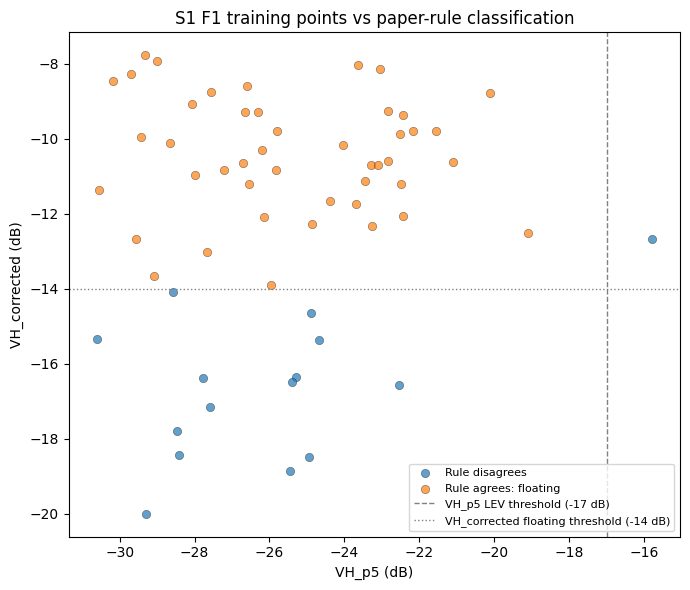


F1 point counts by rule agreement:
paper_rule_agrees_floating
True     45
False    15
Name: count, dtype: int64


In [7]:
def plot_s1_f1_paper_rule_disagreement(df, output_path=None):
    if 'paper_rule_label' not in df.columns:
        print('No paper_rule_label in S1 dataframe; skipping plot.')
        return None
    if 'VH_p5' not in df.columns or 'VH_corrected' not in df.columns:
        print('Missing VH_p5 or VH_corrected; skipping plot.')
        return None

    f1_df = df[df[LABEL_COLUMN].eq('F1')].copy()
    if f1_df.empty:
        print('No F1 points in S1 dataframe; skipping plot.')
        return None
    f1_df['paper_rule_agrees_floating'] = f1_df['paper_rule_label'].eq('Floating plants')

    fig, ax = plt.subplots(figsize=(7, 6))
    for agrees, sub in f1_df.groupby('paper_rule_agrees_floating'):
        ax.scatter(
            sub['VH_p5'], sub['VH_corrected'],
            label=('Rule agrees: floating' if agrees else 'Rule disagrees'),
            alpha=0.7, edgecolor='k', linewidth=0.3
        )
    ax.axvline(-17, color='grey', linestyle='--', linewidth=1, label='VH_p5 LEV threshold (-17 dB)')
    ax.axhline(-14, color='grey', linestyle=':', linewidth=1, label='VH_corrected floating threshold (-14 dB)')
    ax.set_xlabel('VH_p5 (dB)')
    ax.set_ylabel('VH_corrected (dB)')
    ax.set_title('S1 F1 training points vs paper-rule classification')
    ax.legend(loc='lower right', fontsize=8)
    fig.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=150)
        print('Saved diagnostic plot:', output_path)

    plt.show()
    plt.close(fig)

    counts = f1_df['paper_rule_agrees_floating'].value_counts()
    print('\nF1 point counts by rule agreement:')
    print(counts)
    return f1_df


s1_f1_diag_df = plot_s1_f1_paper_rule_disagreement(
    s1_clean_df,
    output_path=LOCAL_OUTPUT_DIR / f'winam_s1_f1_paper_rule_disagreement_{CLASSIFIER_VERSION}.png'
)

## 4. FeatureCollection helpers

In [8]:
def python_scalar(x):
    if pd.isna(x):
        return None
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    return x


def parse_geo_to_ee_geometry(geo_value):
    geom = json.loads(geo_value) if isinstance(geo_value, str) else geo_value
    if isinstance(geom, dict) and geom.get('type') == 'Point':
        return ee.Geometry.Point(geom['coordinates'])
    if isinstance(geom, dict) and geom.get('type') == 'Feature':
        return ee.Geometry(geom['geometry'])
    return ee.Geometry(geom)


def extract_lonlat_from_geo(geo_value):
    """Return (lon, lat) from a CSV .geo cell. Used for spatial block CV."""
    geom = json.loads(geo_value) if isinstance(geo_value, str) else geo_value
    if isinstance(geom, dict):
        if geom.get('type') == 'Point':
            lon, lat = geom['coordinates'][:2]
            return float(lon), float(lat)
        if geom.get('type') == 'Feature':
            lon, lat = geom['geometry']['coordinates'][:2]
            return float(lon), float(lat)
    coords = geom['coordinates']
    return float(coords[0]), float(coords[1])


def df_to_ee_fc(df, predictor_cols=None):
    if predictor_cols is None:
        predictor_cols = []
    base_props = [CLASS_COLUMN, LABEL_COLUMN, 'paper_rule_class', 'paper_rule_label',
                  'Location', 'Date', 'date']
    property_cols = [col for col in predictor_cols + base_props if col in df.columns]
    features = []
    for _, row in df.iterrows():
        geom = parse_geo_to_ee_geometry(row['.geo'])
        props = {col: python_scalar(row[col]) for col in property_cols if col in row.index}
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)

## 5. S2 FeatureCollection from existing CSV predictors

In [9]:
S2_SUPERVISED_PREDICTORS_CANDIDATE = [
    'AWEI_p95', 'AWEI', 'AWEInsh', 'NDMI', 'MNDWI', 'NDVI',
    'B', 'G', 'R', 'RE1', 'RE2', 'RE3', 'RE4', 'NIR', 'SWIR', 'SWIR2'
]


def keep_existing_predictors(df, candidate_predictors, name):
    predictors = [col for col in candidate_predictors if col in df.columns]
    missing = [col for col in candidate_predictors if col not in df.columns]
    print(f'{name} predictors used:', predictors)
    if missing:
        print(f'{name} predictors missing/skipped:', missing)
    return predictors


S2_PREDICTORS = keep_existing_predictors(s2_clean_df, S2_SUPERVISED_PREDICTORS_CANDIDATE, 'S2')
s2_clean_df = s2_clean_df.dropna(subset=S2_PREDICTORS + [CLASS_COLUMN, '.geo']).copy()
s2_fc = df_to_ee_fc(s2_clean_df, S2_PREDICTORS)
print('Usable S2 rows:', len(s2_clean_df))
print('S2 FC size:', s2_fc.size().getInfo())

print('\nS2 final class counts:')
print(s2_clean_df[CLASS_COLUMN].map(S2_CLASS_NAMES).value_counts())

S2 predictors used: ['AWEI_p95', 'AWEI', 'AWEInsh', 'NDMI', 'MNDWI', 'NDVI', 'B', 'G', 'R', 'RE1', 'RE2', 'RE3', 'RE4', 'NIR', 'SWIR', 'SWIR2']
Usable S2 rows: 589
S2 FC size: 589

S2 final class counts:
class
Open water         230
Floating plants    139
LEV                117
Surface algae      103
Name: count, dtype: int64


## 6. S1 exact SCC preprocessing

In [10]:
S1_REF_ANGLE_DEGREES = 38.0
S1_COMPOSITE_START = '2015-11-18'
S1_COMPOSITE_END = '2021-06-01'
S1_PREDICTORS = ['VH_p5', 'VH_corrected', 'VH_smooth']


def add_s1_predictors_exact_scc(img, ref_angle_degrees=S1_REF_ANGLE_DEGREES):
    theta = img.select('angle').multiply(np.pi / 180.0)
    theta_ref = ee.Image.constant(ref_angle_degrees * np.pi / 180.0)
    correction_db = theta_ref.cos().pow(2).divide(theta.cos().pow(2)).log10().multiply(10.0)
    vh_corrected = img.select('VH').add(correction_db).rename('VH_corrected').toFloat()
    vv_corrected = img.select('VV').add(correction_db).rename('VV_corrected').toFloat()
    kernel_5x5 = ee.Kernel.square(radius=2, units='pixels', normalize=False)
    vh_smooth = vh_corrected.focal_median(kernel=kernel_5x5).rename('VH_smooth')
    vv_smooth = vv_corrected.focal_median(kernel=kernel_5x5).rename('VV_smooth')
    return img.addBands([vh_corrected, vv_corrected, vh_smooth, vv_smooth], overwrite=True)


def get_s1_collection(start_date, end_date, aoi):
    return (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .map(add_s1_predictors_exact_scc)
    )


def get_s1_vh_p5(aoi):
    return (
        get_s1_collection(S1_COMPOSITE_START, S1_COMPOSITE_END, aoi)
        .select('VH_corrected')
        .reduce(ee.Reducer.percentile([5]))
        .rename('VH_p5')
    )


def get_s1_predictor_image_for_period(start_date, end_date, aoi, verbose=True):
    collection = get_s1_collection(start_date, end_date, aoi)
    if verbose:
        print('S1 image count:', collection.size().getInfo())
    return collection.median().addBands(get_s1_vh_p5(aoi)).select(S1_PREDICTORS).clip(aoi)

## 7. S1 training-point re-sampling with exact SCC

In [11]:
S1_TRAINING_DAY_WINDOW = 1


def df_to_points_for_date(df, date_string):
    sub = df[df['date'].eq(date_string)].copy()
    return df_to_ee_fc(sub, predictor_cols=[])


def resample_s1_training_by_date(df, aoi, day_window=1):
    date_values = sorted(df['date'].dropna().unique())
    sampled_collections = []
    skipped_dates = []
    for date_string in date_values:
        start = ee.Date(date_string)
        end = start.advance(day_window, 'day')
        collection = get_s1_collection(start, end, aoi)
        count = collection.size().getInfo()
        print(f'Sampling S1 date {date_string} | images in window: {count}')
        if count == 0:
            skipped_dates.append(date_string)
            continue
        points_for_date = df_to_points_for_date(df, date_string)
        predictor_img = collection.median().addBands(get_s1_vh_p5(aoi)).select(S1_PREDICTORS)
        sampled = predictor_img.sampleRegions(
            collection=points_for_date,
            properties=[p for p in [CLASS_COLUMN, LABEL_COLUMN, 'paper_rule_class',
                                    'paper_rule_label', 'Location', 'Date', 'date']
                        if p in df.columns],
            scale=10,
            geometries=True,
            tileScale=16
        )
        sampled_collections.append(sampled)
    if not sampled_collections:
        raise RuntimeError('No S1 training dates had imagery. Increase S1_TRAINING_DAY_WINDOW.')
    return ee.FeatureCollection(sampled_collections).flatten(), skipped_dates

## 8. Spatial block CV, repeated splits, and tie-aware production model selection

For each candidate classifier, we:

1. Assign each training row to a spatial block defined by binning its longitude and latitude to `SPATIAL_BLOCK_DEGREES`.
2. Run a `GroupKFold`-style grouped split (`n_splits=SPATIAL_CV_N_SPLITS`) so the test fold's spatial blocks are disjoint from the train fold's spatial blocks.
3. Repeat this `SPATIAL_CV_N_REPEATS` times with different shuffles of the block-to-fold assignment, accumulating metrics.
4. Report mean ± std for every metric.

The selected production model is then the most parsimonious model whose mean score is within 1 std of the best.

In [12]:
def ee_fc_to_df_with_lonlat(fc):
    """Like geemap.ee_to_df but preserves lon/lat from each point geometry."""
    info = fc.getInfo()
    rows = []
    for feat in info['features']:
        props = dict(feat['properties'])
        geom = feat.get('geometry') or {}
        if geom.get('type') == 'Point':
            props['lon'], props['lat'] = geom['coordinates'][:2]
        else:
            props['lon'], props['lat'] = float('nan'), float('nan')
        rows.append(props)
    return pd.DataFrame(rows)

def assign_spatial_blocks(df, block_degrees=SPATIAL_BLOCK_DEGREES):
    """Add lon/lat and a spatial block id to each training row."""
    df = df.copy()
    if 'lon' not in df.columns or 'lat' not in df.columns:
        if '.geo' not in df.columns:
            raise ValueError(
                'Cannot assign spatial blocks without lon/lat or .geo columns. '
                'For S1 training data sampled via GEE, use ee_fc_to_df_with_lonlat '
                'instead of geemap.ee_to_df.'
            )
        lonlat = df['.geo'].apply(extract_lonlat_from_geo)
        df['lon'] = lonlat.apply(lambda t: t[0])
        df['lat'] = lonlat.apply(lambda t: t[1])

    lon_bin = np.floor(df['lon'].astype(float) / block_degrees).astype(np.int64)
    lat_bin = np.floor(df['lat'].astype(float) / block_degrees).astype(np.int64)
    df['spatial_block'] = (lon_bin * 100000 + lat_bin).astype(np.int64)
    return df

def _safe_stratify(y, test_fraction):
    counts = pd.Series(y).value_counts()
    n_classes = counts.size
    if n_classes <= 1:
        return None
    if counts.min() < 2:
        return None
    if int(np.ceil(len(y) * test_fraction)) < n_classes:
        return None
    return y


def _enabled_candidate_names():
    if CLASSIFIER_CANDIDATE_NAMES is None:
        return None
    return set(CLASSIFIER_CANDIDATE_NAMES)


def make_candidate_classifiers(seed=42, include_svm=False):
    candidates = {
        'Random Forest': RandomForestClassifier(
            n_estimators=500, max_features='sqrt', min_samples_leaf=1, bootstrap=True,
            random_state=seed, n_jobs=-1
        ),
        'Class-weighted RF': RandomForestClassifier(
            n_estimators=500, max_features='sqrt', min_samples_leaf=1, bootstrap=True,
            class_weight='balanced', random_state=seed, n_jobs=-1
        ),
        'Extra Trees': ExtraTreesClassifier(
            n_estimators=500, max_features='sqrt', min_samples_leaf=1,
            class_weight='balanced', random_state=seed, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=3, random_state=seed
        ),
        'Hist Gradient Boosting': HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=300, max_leaf_nodes=31,
            l2_regularization=0.01, random_state=seed
        ),
        'Logistic Regression baseline': make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=3000, class_weight='balanced', solver='lbfgs')
        ),
    }
    if include_svm:
        candidates['RBF SVM'] = make_pipeline(
            StandardScaler(),
            SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced',
                probability=True, random_state=seed)
        )
    enabled = _enabled_candidate_names()
    if enabled is not None:
        candidates = {name: model for name, model in candidates.items() if name in enabled}
    if not candidates:
        raise ValueError('No classifier candidates are enabled. Check CLASSIFIER_CANDIDATE_NAMES.')
    return candidates


def _score_split(model, X_train, y_train, X_test, y_test, labels):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    p, r, floating_f1, support = precision_recall_fscore_support(
        y_test, y_pred, labels=[FLOATING_CLASS_CODE], zero_division=0
    )
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'kappa': cohen_kappa_score(y_test, y_pred, labels=labels),
        'macro_f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'floating_precision': p[0],
        'floating_recall': r[0],
        'floating_f1': floating_f1[0],
        'floating_support': int(support[0]),
    }


def evaluate_with_spatial_cv(
    X, y, groups, candidates, labels,
    n_splits=SPATIAL_CV_N_SPLITS, n_repeats=SPATIAL_CV_N_REPEATS,
    random_state=SPATIAL_CV_RANDOM_STATE, sensor_name='Sensor'
):
    """Run a repeated grouped k-fold split n_repeats times, reshuffling the
    block-to-fold assignment each time; aggregate per-model metrics. This is a
    GroupKFold-style split implemented directly so each repeat reshuffles which
    spatial blocks fall in each fold for variance estimates."""
    rng = np.random.default_rng(random_state)
    unique_groups = np.unique(groups)
    if len(unique_groups) < n_splits:
        raise ValueError(
            f'{sensor_name}: only {len(unique_groups)} spatial blocks but n_splits={n_splits}. '
            'Reduce SPATIAL_BLOCK_DEGREES (smaller blocks) or n_splits.'
        )

    rows = []
    for model_name, model_template in candidates.items():
        per_fold_metrics = []
        for repeat in range(n_repeats):
            # Shuffle groups, then assign each row to a fold based on its (shuffled) group order.
            shuffled = rng.permutation(unique_groups)
            group_to_fold = {g: i % n_splits for i, g in enumerate(shuffled)}
            fold_assignments = np.array([group_to_fold[g] for g in groups])
            for fold in range(n_splits):
                test_idx = np.where(fold_assignments == fold)[0]
                train_idx = np.where(fold_assignments != fold)[0]
                if len(test_idx) == 0 or len(train_idx) == 0:
                    continue
                # Folds where a class is absent from the train split are kept, not skipped:
                # the model still predicts and zero_division=0 handles the undefined
                # floating_f1 for that fold.
                model = clone(model_template)
                metrics = _score_split(
                    model,
                    X[train_idx], y[train_idx],
                    X[test_idx], y[test_idx],
                    labels
                )
                metrics['repeat'] = repeat
                metrics['fold'] = fold
                per_fold_metrics.append(metrics)

        per_fold_df = pd.DataFrame(per_fold_metrics)
        agg = {'sensor': sensor_name, 'model': model_name,
               'n_folds_evaluated': len(per_fold_df)}
        for col in ['accuracy', 'balanced_accuracy', 'kappa', 'macro_f1', 'weighted_f1',
                    'floating_precision', 'floating_recall', 'floating_f1']:
            agg[f'{col}_mean'] = per_fold_df[col].mean()
            agg[f'{col}_std'] = per_fold_df[col].std()
        rows.append(agg)

    return pd.DataFrame(rows)


def evaluate_with_random_split(
    X, y, candidates, labels, sensor_name='Sensor', seed=42, train_fraction=0.7
):
    """I.i.d. random split, kept as a diagnostic baseline to compare against spatial CV."""
    test_fraction = 1.0 - train_fraction
    stratify = _safe_stratify(y, test_fraction)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=train_fraction, random_state=seed, stratify=stratify
    )
    rows = []
    for model_name, model_template in candidates.items():
        model = clone(model_template)
        metrics = _score_split(model, X_train, y_train, X_test, y_test, labels)
        metrics.update({'sensor': sensor_name, 'model': model_name,
                        'train_rows': len(y_train), 'test_rows': len(y_test)})
        rows.append(metrics)
    return pd.DataFrame(rows)


def select_production_model_tie_aware(spatial_results_df, preferred_metric=MODEL_SELECTION_METRIC,
                                       tie_tolerance_std=TIE_TOLERANCE_STD,
                                       parsimony_order=PRODUCTION_PARSIMONY_ORDER,
                                       allowed_models=PRODUCTION_CLASSIFIER_CANDIDATE_NAMES):
    """Pick the production model: among models whose mean score is within
    tie_tolerance_std * std of the leader, return the most parsimonious."""
    df = spatial_results_df.copy()
    if allowed_models is not None:
        df = df[df['model'].isin(set(allowed_models))].copy()
        if df.empty:
            print('Warning: PRODUCTION_CLASSIFIER_CANDIDATE_NAMES excludes every evaluated model. '
                  'Falling back to all evaluated models.')
            df = spatial_results_df.copy()

    mean_col = f'{preferred_metric}_mean'
    std_col = f'{preferred_metric}_std'
    if mean_col not in df.columns:
        raise ValueError(f'Preferred metric column {mean_col} not in results.')

    df = df.sort_values(mean_col, ascending=False).reset_index(drop=True)
    leader_mean = df.loc[0, mean_col]
    leader_std = df.loc[0, std_col]
    threshold = leader_mean - tie_tolerance_std * leader_std
    print(f"Production selection: leader mean={leader_mean:.4f}, std={leader_std:.4f}, "
          f"tie threshold (mean >= {threshold:.4f}):")
    tied = df[df[mean_col] >= threshold].copy()
    display(tied[['model', mean_col, std_col]])

    # Pick the most parsimonious among tied models.
    for candidate in parsimony_order:
        if candidate in set(tied['model']):
            print(f"Selected production model by parsimony tiebreak: {candidate}")
            return candidate
    # Fallback: highest mean score.
    fallback = df.loc[0, 'model']
    print(f"Parsimony order did not match any tied model; falling back to leader: {fallback}")
    return fallback


def model_feature_importance(model, predictors):
    estimator = model
    if hasattr(model, 'named_steps'):
        estimator = list(model.named_steps.values())[-1]
    if hasattr(estimator, 'feature_importances_'):
        importance = estimator.feature_importances_
        return pd.DataFrame({
            'predictor': predictors,
            'importance': importance,
            'importance_type': 'tree_feature_importance'
        }).sort_values('importance', ascending=False)
    if hasattr(estimator, 'coef_'):
        coef = np.asarray(estimator.coef_)
        if coef.ndim == 1:
            importance = np.abs(coef)
        else:
            importance = np.mean(np.abs(coef), axis=0)
        return pd.DataFrame({
            'predictor': predictors,
            'importance': importance,
            'importance_type': 'mean_absolute_standardised_coefficient'
        }).sort_values('importance', ascending=False)
    print('Selected model does not expose built-in feature importances.')
    return pd.DataFrame(columns=['predictor', 'importance', 'importance_type'])

### 8b. Run spatial CV, optional random-split diagnostic, train selected model on all data

In [13]:
def train_with_spatial_cv(df, predictors, class_names=None, sensor_name='Sensor', seed=42):
    missing = [col for col in predictors + [CLASS_COLUMN] if col not in df.columns]
    if missing:
        raise ValueError(f'{sensor_name} training data is missing columns: {missing}')

    df = assign_spatial_blocks(df, block_degrees=SPATIAL_BLOCK_DEGREES)
    df = df.dropna(subset=predictors + [CLASS_COLUMN, 'spatial_block']).copy()
    if df.empty:
        raise ValueError(f'{sensor_name}: no usable rows after dropping NaNs.')

    X = df[predictors].astype(np.float32).to_numpy()
    y = df[CLASS_COLUMN].astype(int).to_numpy()
    groups = df['spatial_block'].to_numpy()
    labels = sorted(class_names.keys()) if class_names else sorted(np.unique(y))

    n_blocks = len(np.unique(groups))
    print(f'{sensor_name}: {len(df)} rows across {n_blocks} spatial blocks '
          f'(block size ~{SPATIAL_BLOCK_DEGREES} degrees)')

    candidates = make_candidate_classifiers(seed=seed, include_svm=INCLUDE_SVM_CANDIDATE)

    print(f'\n=== {sensor_name}: spatial block CV ({SPATIAL_CV_N_SPLITS} splits x '
          f'{SPATIAL_CV_N_REPEATS} repeats) ===')
    spatial_results = evaluate_with_spatial_cv(
        X, y, groups, candidates, labels,
        n_splits=SPATIAL_CV_N_SPLITS, n_repeats=SPATIAL_CV_N_REPEATS,
        random_state=SPATIAL_CV_RANDOM_STATE, sensor_name=sensor_name
    )
    spatial_results = spatial_results.sort_values(
        f'{MODEL_SELECTION_METRIC}_mean', ascending=False
    ).reset_index(drop=True)
    print(f'\n{sensor_name} spatial CV results, sorted by {MODEL_SELECTION_METRIC}_mean:')
    display(spatial_results)

    random_results = None
    if ALSO_RUN_RANDOM_CV_FOR_COMPARISON:
        print(f'\n=== {sensor_name}: random split diagnostic (for comparison only) ===')
        random_results = evaluate_with_random_split(
            X, y, candidates, labels, sensor_name=sensor_name, seed=seed
        )
        random_results = random_results.sort_values(MODEL_SELECTION_METRIC, ascending=False)
        display(random_results)

    if USE_SELECTED_MODEL_FOR_RASTER_CLASSIFICATION:
        selected_model_name = select_production_model_tie_aware(spatial_results)
    else:
        selected_model_name = 'Random Forest'
        print(f'USE_SELECTED_MODEL_FOR_RASTER_CLASSIFICATION is False; '
              f'forcing {selected_model_name}.')

    if selected_model_name not in candidates:
        raise ValueError(f"Selected model '{selected_model_name}' not in candidate set.")

    final_model = clone(candidates[selected_model_name])
    final_model.fit(X, y)
    importance_df = model_feature_importance(final_model, predictors)
    print(f'\nFinal {sensor_name} model trained on all usable rows: {len(y)}')
    print('Selected model for raster classification:', selected_model_name)
    if not importance_df.empty:
        print('\nVariable importance / coefficients:')
        display(importance_df)

    return final_model, importance_df, df, spatial_results, random_results, selected_model_name


def save_local_classifier_bundle(model, predictors, class_names, model_path,
                                  importance_df=None, model_name=None,
                                  spatial_results=None, random_results=None):
    bundle = {
        'model': model,
        'model_name': model_name,
        'predictors': list(predictors),
        'class_names': dict(class_names),
        'classifier_version': CLASSIFIER_VERSION,
        'manual_corrections_enabled': globals().get('MANUAL_CORRECTIONS_ENABLED', False),
        'manual_correction_version': globals().get('MANUAL_CORRECTION_VERSION'),
        'manual_correction_gpkgs': [str(p) for p in globals().get('MANUAL_CORRECTION_GPKG_PATHS', [])],
        's2_manual_correction_rows': int(globals().get('S2_N_CORRECTIONS', 0)),
        's1_manual_correction_rows': int(globals().get('S1_N_CORRECTIONS', 0)),
        'model_selection_metric': MODEL_SELECTION_METRIC,
        'use_selected_model_for_raster_classification': USE_SELECTED_MODEL_FOR_RASTER_CLASSIFICATION,
        'production_classifier_candidate_names': PRODUCTION_CLASSIFIER_CANDIDATE_NAMES,
        'spatial_block_degrees': SPATIAL_BLOCK_DEGREES,
        'spatial_cv_n_splits': SPATIAL_CV_N_SPLITS,
        'spatial_cv_n_repeats': SPATIAL_CV_N_REPEATS,
        'tie_tolerance_std': TIE_TOLERANCE_STD,
        'parsimony_order': PRODUCTION_PARSIMONY_ORDER,
    }
    if importance_df is not None:
        bundle['feature_importance'] = importance_df.to_dict(orient='records')
    if spatial_results is not None:
        bundle['spatial_cv_results'] = spatial_results.to_dict(orient='records')
    if random_results is not None:
        bundle['random_split_results'] = random_results.to_dict(orient='records')
    joblib.dump(bundle, model_path)
    print('Saved local classifier bundle:', model_path)


def load_local_classifier_bundle(model_path, expected_predictors, model_name):
    if not Path(model_path).exists():
        raise FileNotFoundError(f'Could not find saved {model_name} model: {model_path}')
    bundle = joblib.load(model_path)
    predictors = bundle.get('predictors')
    if predictors != list(expected_predictors):
        raise ValueError(
            f'{model_name} predictor mismatch.\nExpected: {list(expected_predictors)}\n'
            f'Loaded:   {predictors}'
        )
    print(f'Loaded saved local {model_name} classifier bundle:', model_path)
    print('Loaded model type/name:', bundle.get('model_name', type(bundle["model"]).__name__))
    return bundle['model'], bundle


def _cv_ready_frame(df, predictors, class_column=CLASS_COLUMN):
    """Return rows usable by the spatial-CV helpers without mutating the source."""
    required = list(predictors) + [class_column, '.geo']
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f'Manual-correction comparison is missing columns: {missing}')
    return df.dropna(subset=required).copy()


def run_spatial_cv_diagnostic(df, predictors, class_names, sensor_name, seed=42):
    """Run the same grouped spatial CV as production, but do not fit/save a final model."""
    ready = _cv_ready_frame(df, predictors)
    ready = assign_spatial_blocks(ready, block_degrees=SPATIAL_BLOCK_DEGREES)
    ready = ready.dropna(subset=list(predictors) + [CLASS_COLUMN, 'spatial_block']).copy()
    if ready.empty:
        raise ValueError(f'{sensor_name}: no usable rows for manual-correction comparison.')

    X = ready[predictors].astype(np.float32).to_numpy()
    y = ready[CLASS_COLUMN].astype(int).to_numpy()
    groups = ready['spatial_block'].to_numpy()
    labels = sorted(class_names.keys())
    candidates = make_candidate_classifiers(seed=seed, include_svm=INCLUDE_SVM_CANDIDATE)

    print(f'\n=== {sensor_name}: manual-correction comparison spatial CV ===')
    print(f'{sensor_name}: {len(ready)} rows across {len(np.unique(groups))} spatial blocks')
    results = evaluate_with_spatial_cv(
        X, y, groups, candidates, labels,
        n_splits=SPATIAL_CV_N_SPLITS, n_repeats=SPATIAL_CV_N_REPEATS,
        random_state=SPATIAL_CV_RANDOM_STATE, sensor_name=sensor_name
    )
    return results.sort_values(f'{MODEL_SELECTION_METRIC}_mean', ascending=False).reset_index(drop=True)


def summarise_manual_correction_comparison(baseline_results, corrected_results, sensor_name):
    """Pair baseline/corrected CV rows by model and compute corrected-minus-baseline deltas."""
    metrics = ['accuracy', 'balanced_accuracy', 'kappa', 'macro_f1', 'weighted_f1', 'floating_f1']
    baseline = baseline_results.copy().add_prefix('baseline_')
    corrected = corrected_results.copy().add_prefix('corrected_')
    comparison = baseline.merge(
        corrected,
        left_on='baseline_model', right_on='corrected_model', how='inner'
    )
    comparison.insert(0, 'sensor', sensor_name)
    comparison.insert(1, 'model', comparison['baseline_model'])
    for metric in metrics:
        b_col = f'baseline_{metric}_mean'
        c_col = f'corrected_{metric}_mean'
        if b_col in comparison.columns and c_col in comparison.columns:
            comparison[f'delta_{metric}_mean'] = comparison[c_col] - comparison[b_col]
    keep = ['sensor', 'model']
    for metric in metrics:
        keep.extend([
            f'baseline_{metric}_mean', f'corrected_{metric}_mean', f'delta_{metric}_mean'
        ])
    keep = [col for col in keep if col in comparison.columns]
    return comparison[keep].sort_values(f'corrected_{MODEL_SELECTION_METRIC}_mean', ascending=False)


_use_saved_classifiers = USE_SAVED_LOCAL_CLASSIFIERS
if _use_saved_classifiers and not (Path(S2_LOCAL_MODEL_PATH).exists() and Path(S1_LOCAL_MODEL_PATH).exists()):
    print('USE_SAVED_LOCAL_CLASSIFIERS is True but saved classifier bundle(s) were not found; '
          'training from scratch instead (bundles are saved for reuse when SAVE_LOCAL_CLASSIFIERS is True).')
    _use_saved_classifiers = False

if _use_saved_classifiers:
    s2_classifier_final, s2_model_bundle = load_local_classifier_bundle(
        S2_LOCAL_MODEL_PATH, S2_PREDICTORS, 'S2')
    s1_classifier_final, s1_model_bundle = load_local_classifier_bundle(
        S1_LOCAL_MODEL_PATH, S1_PREDICTORS, 'S1')
    s2_selected_model_name = s2_model_bundle.get('model_name', 'Saved classifier')
    s1_selected_model_name = s1_model_bundle.get('model_name', 'Saved classifier')
    s2_spatial_results = pd.DataFrame(s2_model_bundle.get('spatial_cv_results', []))
    s1_spatial_results = pd.DataFrame(s1_model_bundle.get('spatial_cv_results', []))
    s2_random_results = pd.DataFrame(s2_model_bundle.get('random_split_results', []))
    s1_random_results = pd.DataFrame(s1_model_bundle.get('random_split_results', []))
    s2_importance_df = pd.DataFrame(s2_model_bundle.get('feature_importance', []))
    s1_importance_df = pd.DataFrame(s1_model_bundle.get('feature_importance', []))
    s1_fc_exact = None
    s1_training_df_local = None
else:
    (s2_classifier_final, s2_importance_df, s2_training_df_local,
     s2_spatial_results, s2_random_results, s2_selected_model_name) = train_with_spatial_cv(
        s2_clean_df, S2_PREDICTORS, class_names=S2_CLASS_NAMES, sensor_name='S2 Route B'
    )

    s1_fc_exact, skipped_s1_dates = resample_s1_training_by_date(
        s1_clean_df, winam, S1_TRAINING_DAY_WINDOW
    )
    print('\nExact SCC-resampled S1 training rows:', s1_fc_exact.size().getInfo())
    if skipped_s1_dates:
        print('Skipped S1 dates:', skipped_s1_dates)
    s1_training_df_local = ee_fc_to_df_with_lonlat(s1_fc_exact)
    print('\nS1 class counts after SCC re-sampling:')
    display(s1_training_df_local[CLASS_COLUMN].map(S1_CLASS_NAMES).value_counts())

    (s1_classifier_final, s1_importance_df, s1_training_df_local,
     s1_spatial_results, s1_random_results, s1_selected_model_name) = train_with_spatial_cv(
        s1_training_df_local, S1_PREDICTORS, class_names=S1_CLASS_NAMES, sensor_name='S1 Route B SCC'
    )

    spatial_csv = LOCAL_OUTPUT_DIR / f'winam_classifier_spatial_cv_{CLASSIFIER_VERSION}.csv'
    pd.concat([s2_spatial_results.assign(stage='spatial_cv'),
               s1_spatial_results.assign(stage='spatial_cv')], ignore_index=True).to_csv(spatial_csv, index=False)
    print('Saved spatial CV comparison table:', spatial_csv)

    if s2_random_results is not None and s1_random_results is not None:
        random_csv = LOCAL_OUTPUT_DIR / f'winam_classifier_random_split_{CLASSIFIER_VERSION}.csv'
        pd.concat([s2_random_results, s1_random_results], ignore_index=True).to_csv(random_csv, index=False)
        print('Saved random-split diagnostic table:', random_csv)

    if SAVE_LOCAL_CLASSIFIERS:
        save_local_classifier_bundle(
            s2_classifier_final, S2_PREDICTORS, S2_CLASS_NAMES, S2_LOCAL_MODEL_PATH,
            s2_importance_df, model_name=s2_selected_model_name,
            spatial_results=s2_spatial_results, random_results=s2_random_results
        )
        save_local_classifier_bundle(
            s1_classifier_final, S1_PREDICTORS, S1_CLASS_NAMES, S1_LOCAL_MODEL_PATH,
            s1_importance_df, model_name=s1_selected_model_name,
            spatial_results=s1_spatial_results, random_results=s1_random_results
        )


manual_correction_comparison = None
if MANUAL_CORRECTIONS_ENABLED and RUN_MANUAL_CORRECTION_COMPARISON:
    comparison_frames = []

    s2_baseline_results = run_spatial_cv_diagnostic(
        S2_CLEAN_DF_NO_MANUAL_CORRECTIONS, S2_PREDICTORS, S2_CLASS_NAMES,
        'S2 Route B — without manual corrections'
    )
    s2_comparison = summarise_manual_correction_comparison(
        s2_baseline_results, s2_spatial_results, 'S2 Route B'
    )
    comparison_frames.append(s2_comparison)
    print('\nS2 manual-correction comparison (corrected minus baseline):')
    display(s2_comparison)

    if RUN_S1_MANUAL_CORRECTION_COMPARISON:
        s1_baseline_fc, s1_baseline_skipped_dates = resample_s1_training_by_date(
            S1_CLEAN_DF_NO_MANUAL_CORRECTIONS, winam, S1_TRAINING_DAY_WINDOW
        )
        if s1_baseline_skipped_dates:
            print('S1 baseline skipped dates:', s1_baseline_skipped_dates)
        s1_baseline_training_df = ee_fc_to_df_with_lonlat(s1_baseline_fc)
        s1_baseline_results = run_spatial_cv_diagnostic(
            s1_baseline_training_df, S1_PREDICTORS, S1_CLASS_NAMES,
            'S1 Route B SCC — without manual corrections'
        )
        s1_comparison = summarise_manual_correction_comparison(
            s1_baseline_results, s1_spatial_results, 'S1 Route B SCC'
        )
        comparison_frames.append(s1_comparison)
        print('\nS1 manual-correction comparison (corrected minus baseline):')
        display(s1_comparison)
    elif S1_N_CORRECTIONS:
        print('S1 manual corrections are present, but RUN_S1_MANUAL_CORRECTION_COMPARISON=False; '
              'set it True to run the extra Earth Engine baseline re-sampling pass.')

    manual_correction_comparison = pd.concat(comparison_frames, ignore_index=True)
    correction_comparison_csv = LOCAL_OUTPUT_DIR / f'winam_manual_correction_cv_comparison_{CLASSIFIER_VERSION}.csv'
    manual_correction_comparison.to_csv(correction_comparison_csv, index=False)
    print('Saved manual-correction CV comparison table:', correction_comparison_csv)
elif RUN_MANUAL_CORRECTION_COMPARISON:
    print('Manual-correction comparison skipped because no correction GeoPackages are enabled.')


if SAVE_CLASSIFIER_METADATA:
    metadata = {
        'classifier_version': CLASSIFIER_VERSION,
        'ee_project': EE_PROJECT,
        's2_local_model_path': str(S2_LOCAL_MODEL_PATH),
        's1_local_model_path': str(S1_LOCAL_MODEL_PATH),
        's2_selected_model_name': s2_selected_model_name,
        's1_selected_model_name': s1_selected_model_name,
        'model_selection_metric': MODEL_SELECTION_METRIC,
        'spatial_block_degrees': SPATIAL_BLOCK_DEGREES,
        'spatial_cv_n_splits': SPATIAL_CV_N_SPLITS,
        'spatial_cv_n_repeats': SPATIAL_CV_N_REPEATS,
        'tie_tolerance_std': TIE_TOLERANCE_STD,
        'parsimony_order': PRODUCTION_PARSIMONY_ORDER,
        'include_svm_candidate': INCLUDE_SVM_CANDIDATE,
        'production_classifier_candidate_names': PRODUCTION_CLASSIFIER_CANDIDATE_NAMES,
        'write_probability_raster': WRITE_PROBABILITY_RASTER,
        'confidence_thresholds': CONFIDENCE_THRESHOLDS,
        'reject_drive_collision_duplicates': REJECT_DRIVE_COLLISION_DUPLICATES,
        's2_predictors': S2_PREDICTORS,
        's1_predictors': S1_PREDICTORS,
        's2_class_names': S2_CLASS_NAMES,
        's1_class_names': S1_CLASS_NAMES,
        'aoi': [34.2046673170698, -0.55, 34.9, 0],
        'notes': 'Spatial block CV, repeated splits, tie-aware selection, probability rasters, '
                 'and Drive duplicate-tile guard.'
    }
    metadata_path = LOCAL_OUTPUT_DIR / f'winam_classifier_metadata_{CLASSIFIER_VERSION}.json'
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print('Saved classifier metadata:', metadata_path)

S2 Route B: 589 rows across 36 spatial blocks (block size ~0.1 degrees)

=== S2 Route B: spatial block CV (5 splits x 10 repeats) ===

S2 Route B spatial CV results, sorted by floating_f1_mean:


,sensor,model,n_folds_evaluated,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,kappa_mean,kappa_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,floating_precision_mean,floating_precision_std,floating_recall_mean,floating_recall_std,floating_f1_mean,floating_f1_std
0,S2 Route B,Logistic Regression baseline,50,0.852500,0.067010,0.848135,0.064493,0.790115,0.091103,0.834825,0.067460,0.853554,0.067190,0.758652,0.156328,0.902565,0.085681,0.810503,0.096620
1,S2 Route B,Hist Gradient Boosting,50,0.850949,0.070925,0.849944,0.068373,0.784477,0.096385,0.830541,0.072444,0.854197,0.070111,0.783102,0.142043,0.862934,0.117971,0.806588,0.088732
2,S2 Route B,Gradient Boosting,50,0.845555,0.068351,0.836404,0.063585,0.776498,0.091138,0.829507,0.060595,0.846883,0.067643,0.772061,0.126214,0.839952,0.116209,0.793785,0.086612
3,S2 Route B,Random Forest,50,0.844828,0.070646,0.840293,0.069044,0.781085,0.094059,0.830414,0.067361,0.846378,0.069790,0.771563,0.159663,0.849316,0.133980,0.789178,0.099769
4,S2 Route B,Extra Trees,50,0.844331,0.071405,0.845830,0.071814,0.779731,0.097133,0.829799,0.069946,0.847468,0.070616,0.766392,0.169425,0.849937,0.098046,0.789135,0.101512
5,S2 Route B,Class-weighted RF,50,0.846238,0.064680,0.842369,0.061016,0.780836,0.084465,0.827586,0.059931,0.849302,0.063787,0.770580,0.133527,0.836141,0.148418,0.783652,0.090040



=== S2 Route B: random split diagnostic (for comparison only) ===


,accuracy,balanced_accuracy,kappa,macro_f1,weighted_f1,floating_precision,floating_recall,floating_f1,floating_support,sensor,model,train_rows,test_rows
5,0.870056,0.880869,0.822576,0.867610,0.871393,0.844444,0.904762,0.873563,42,S2 Route B,Logistic Regression baseline,412,177
3,0.847458,0.846769,0.790376,0.842189,0.850538,0.825000,0.785714,0.804878,42,S2 Route B,Gradient Boosting,412,177
4,0.847458,0.851211,0.791036,0.843826,0.851151,0.825000,0.785714,0.804878,42,S2 Route B,Hist Gradient Boosting,412,177
2,0.847458,0.851211,0.791283,0.843134,0.851551,0.804878,0.785714,0.795181,42,S2 Route B,Extra Trees,412,177
1,0.841808,0.844336,0.783259,0.837321,0.845436,0.800000,0.761905,0.780488,42,S2 Route B,Class-weighted RF,412,177
0,0.836158,0.836272,0.775145,0.831107,0.839618,0.800000,0.761905,0.780488,42,S2 Route B,Random Forest,412,177


Production selection: leader mean=0.8105, std=0.0966, tie threshold (mean >= 0.7139):


...

Selected production model by parsimony tiebreak: Logistic Regression baseline

Final S1 Route B SCC model trained on all usable rows: 236
Selected model for raster classification: Logistic Regression baseline

Variable importance / coefficients:


,predictor,importance,importance_type
0,VH_p5,1.571804,mean_absolute_standardised_coefficient
1,VH_corrected,1.126347,mean_absolute_standardised_coefficient
2,VH_smooth,0.716049,mean_absolute_standardised_coefficient


Saved spatial CV comparison table: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_classifier_spatial_cv_route_b_s1_scc_spatialcv_proba_v3_corr_v1.csv
Saved random-split diagnostic table: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_classifier_random_split_route_b_s1_scc_spatialcv_proba_v3_corr_v1.csv
Saved local classifier bundle: /content/drive/MyDrive/Winam_RF_Training_Data/models/winam_s2_model_route_b_s1_scc_spatialcv_proba_v3_corr_v1.joblib
Saved local classifier bundle: /content/drive/MyDrive/Winam_RF_Training_Data/models/winam_s1_model_route_b_s1_scc_spatialcv_proba_v3_corr_v1.joblib

=== S2 Route B — without manual corrections: manual-correction comparison spatial CV ===
S2 Route B — without manual corrections: 238 rows across 25 spatial blocks

S2 manual-correction comparison (corrected minus baseline):


,sensor,model,baseline_accuracy_mean,corrected_accuracy_mean,delta_accuracy_mean,baseline_balanced_accuracy_mean,corrected_balanced_accuracy_mean,delta_balanced_accuracy_mean,baseline_kappa_mean,corrected_kappa_mean,delta_kappa_mean,baseline_macro_f1_mean,corrected_macro_f1_mean,delta_macro_f1_mean,baseline_weighted_f1_mean,corrected_weighted_f1_mean,delta_weighted_f1_mean,baseline_floating_f1_mean,corrected_floating_f1_mean,delta_floating_f1_mean
0,S2 Route B,Logistic Regression baseline,0.973334,0.852500,-0.120834,0.969011,0.848135,-0.120876,0.963095,0.790115,-0.172979,0.969816,0.834825,-0.134991,0.973172,0.853554,-0.119617,0.959215,0.810503,-0.148712
2,S2 Route B,Hist Gradient Boosting,0.958819,0.850949,-0.107870,0.956670,0.849944,-0.106727,0.943401,0.784477,-0.158924,0.955811,0.830541,-0.125270,0.958876,0.854197,-0.104679,0.929290,0.806588,-0.122702
5,S2 Route B,Gradient Boosting,0.955281,0.845555,-0.109726,0.951399,0.836404,-0.114995,0.938654,0.776498,-0.162156,0.951333,0.829507,-0.121825,0.955360,0.846883,-0.108477,0.910990,0.793785,-0.117205
1,S2 Route B,Random Forest,0.970559,0.844828,-0.125730,0.969590,0.840293,-0.129297,0.959835,0.781085,-0.178750,0.969073,0.830414,-0.138659,0.970605,0.846378,-0.124226,0.931654,0.789178,-0.142476
4,S2 Route B,Extra Trees,0.964617,0.844331,-0.120286,0.964576,0.845830,-0.118746,0.951736,0.779731,-0.172005,0.956891,0.829799,-0.127092,0.965233,0.847468,-0.117765,0.919233,0.789135,-0.130098
3,S2 Route B,Class-weighted RF,0.966557,0.846238,-0.120319,0.961857,0.842369,-0.119488,0.954264,0.780836,-0.173428,0.959691,0.827586,-0.132105,0.966467,0.849302,-0.117164,0.923499,0.783652,-0.139847


Saved manual-correction CV comparison table: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_manual_correction_cv_comparison_route_b_s1_scc_spatialcv_proba_v3_corr_v1.csv
Saved classifier metadata: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_classifier_metadata_route_b_s1_scc_spatialcv_proba_v3_corr_v1.json



S2 more-training-data diagnostics input: 589 rows across 36 spatial blocks; manual/corrected rows=351.

S2 fixed-validation fair comparison:


,model,train_arm,train_rows,validation_rows,accuracy,balanced_accuracy,kappa,macro_f1,weighted_f1,floating_precision,floating_recall,floating_f1
0,Logistic Regression baseline,old_uncorrected_subset_only,175,154,0.701299,0.756761,0.605018,0.720504,0.692267,0.649123,0.973684,0.778947
1,Logistic Regression baseline,corrected_full_excluding_validation,435,154,0.863636,0.871216,0.813774,0.861540,0.867678,0.903226,0.736842,0.811594


Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_fixed_validation_diagnostic_more_training_data_check.csv
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_fixed_validation_predictions_manual_corrected_confusion_matrix.csv


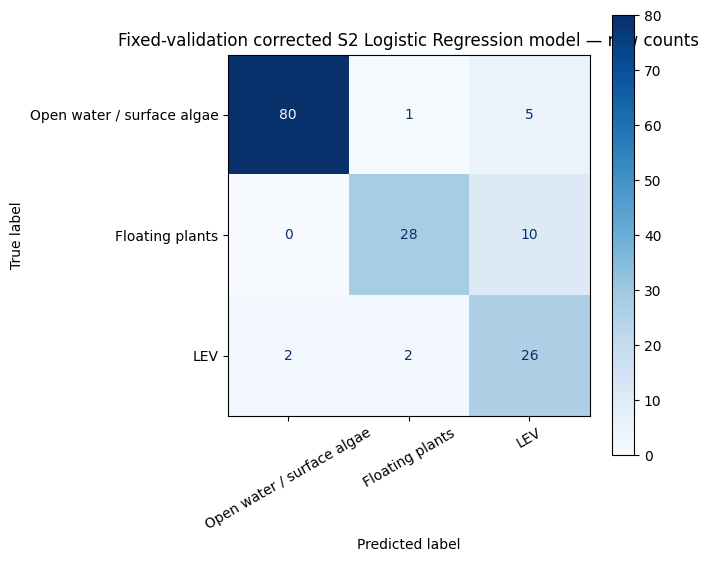

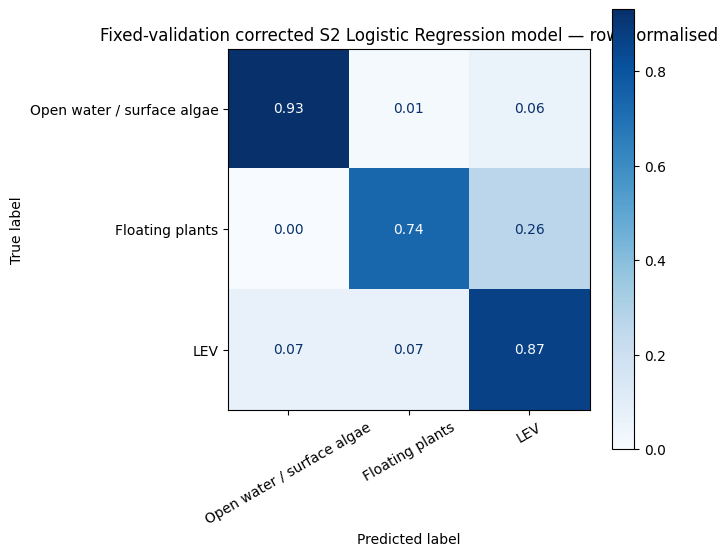


Fixed-validation corrected S2 Logistic Regression model raw counts:


,Open water / surface algae,Floating plants,LEV
Open water / surface algae,80,1,5
Floating plants,0,28,10
LEV,2,2,26



Fixed-validation corrected S2 Logistic Regression model row-normalised proportions:


,Open water / surface algae,Floating plants,LEV
Open water / surface algae,0.930233,0.011628,0.058140
Floating plants,0.000000,0.736842,0.263158
LEV,0.066667,0.066667,0.866667


Fixed-validation corrected S2 Logistic Regression model: Floating plants correct=28, confused as Open water / surface algae=0, confused as LEV=10; mainly confused with LEV.
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_fixed_validation_corrected_model_raw_counts_manual_corrected_confusion_matrix.csv
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_fixed_validation_corrected_model_row_normalised_manual_corrected_confusion_matrix.csv
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_fixed_validation_corrected_model_raw_counts_manual_corrected_confusion_matrix.png
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_fixed_validation_corrected_model_row_normalised_manual_corrected_confusion_matrix.png


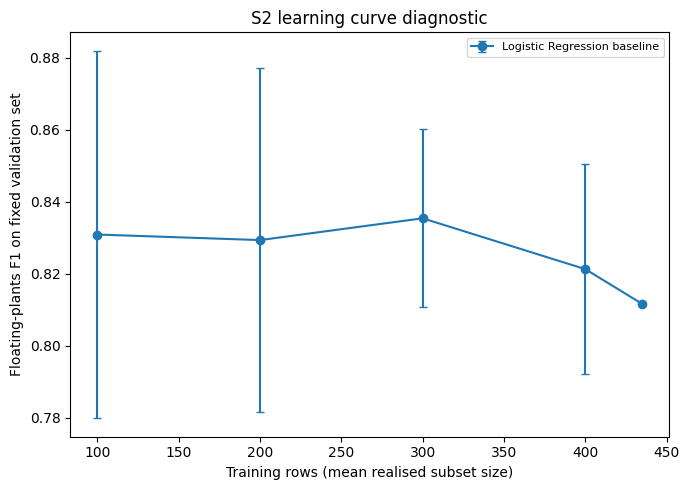


S2 learning-curve summary:


,model,requested_train_size,train_rows_mean,train_blocks_mean,floating_f1_mean,floating_f1_std,accuracy_mean,balanced_accuracy_mean
0,Logistic Regression baseline,100,100.0,7.3,0.830891,0.051122,0.856494,0.863066
1,Logistic Regression baseline,200,200.0,13.1,0.829346,0.047911,0.848701,0.860950
2,Logistic Regression baseline,300,300.0,19.4,0.835403,0.024723,0.859091,0.869061
3,Logistic Regression baseline,400,400.0,26.2,0.821265,0.029108,0.861688,0.870379
4,Logistic Regression baseline,all,435.0,28.0,0.811594,NaN,0.863636,0.871216


Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_learning_curve_summary_diagnostic_more_training_data_check.csv
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_learning_curve_repeats_diagnostic_more_training_data_check.csv
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_learning_curve_floating_f1_diagnostic_more_training_data_check.png

S2 corrected-vs-original point difficulty (spatial-CV predictions):


,correction_source,unique_points,spatial_blocks,accuracy,balanced_accuracy,kappa,macro_f1,weighted_f1,floating_precision,floating_recall,floating_f1
0,manual_corrected_added,351,33,0.777778,0.726569,0.670719,0.729162,0.775243,0.629493,0.864557,0.728533
1,original_accepted,238,25,0.956723,0.957077,0.942296,0.956764,0.956703,0.998201,0.925000,0.960208


Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_point_difficulty_diagnostic_more_training_data_check.csv
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_point_difficulty_predictions_diagnostic_more_training_data_check.csv
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_spatial_cv_oof_predictions_manual_corrected_confusion_matrix.csv


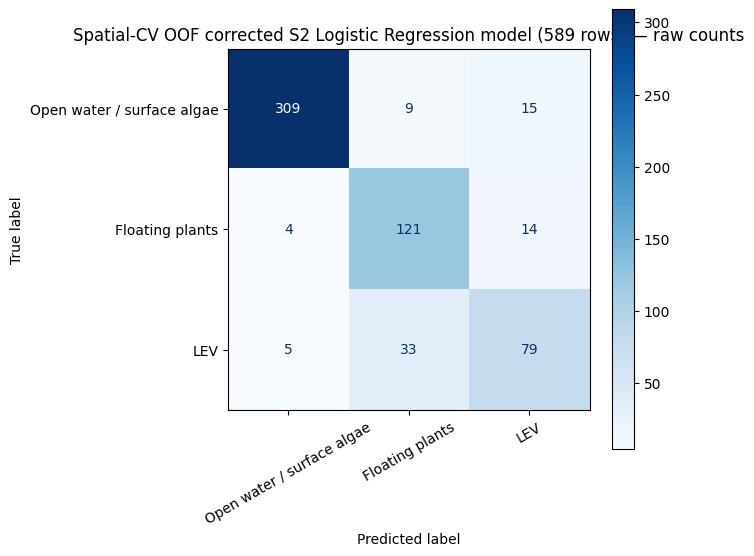

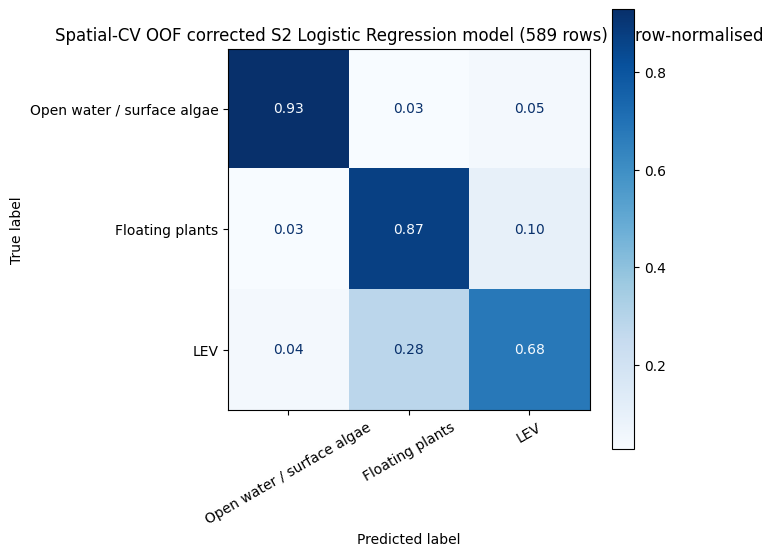


Spatial-CV OOF corrected S2 Logistic Regression model (589 rows) raw counts:


,Open water / surface algae,Floating plants,LEV
Open water / surface algae,309,9,15
Floating plants,4,121,14
LEV,5,33,79



Spatial-CV OOF corrected S2 Logistic Regression model (589 rows) row-normalised proportions:


,Open water / surface algae,Floating plants,LEV
Open water / surface algae,0.927928,0.027027,0.045045
Floating plants,0.028777,0.870504,0.100719
LEV,0.042735,0.282051,0.675214


Spatial-CV OOF corrected S2 Logistic Regression model (589 rows): Floating plants correct=121, confused as Open water / surface algae=4, confused as LEV=14; mainly confused with LEV.
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_spatial_cv_oof_all_corrected_data_raw_counts_manual_corrected_confusion_matrix.csv
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_spatial_cv_oof_all_corrected_data_row_normalised_manual_corrected_confusion_matrix.csv
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_spatial_cv_oof_all_corrected_data_raw_counts_manual_corrected_confusion_matrix.png
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_spatial_cv_oof_all_corrected_data_row_normalised_manual_corrected_confusion_matrix.png


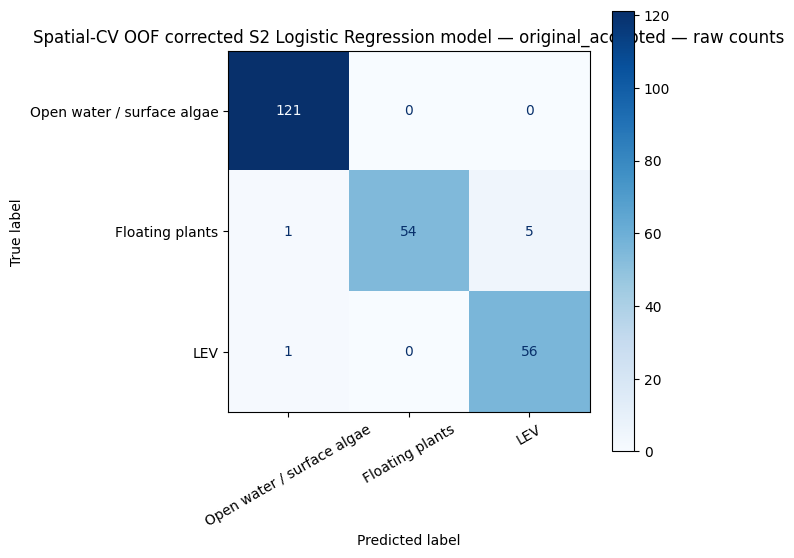

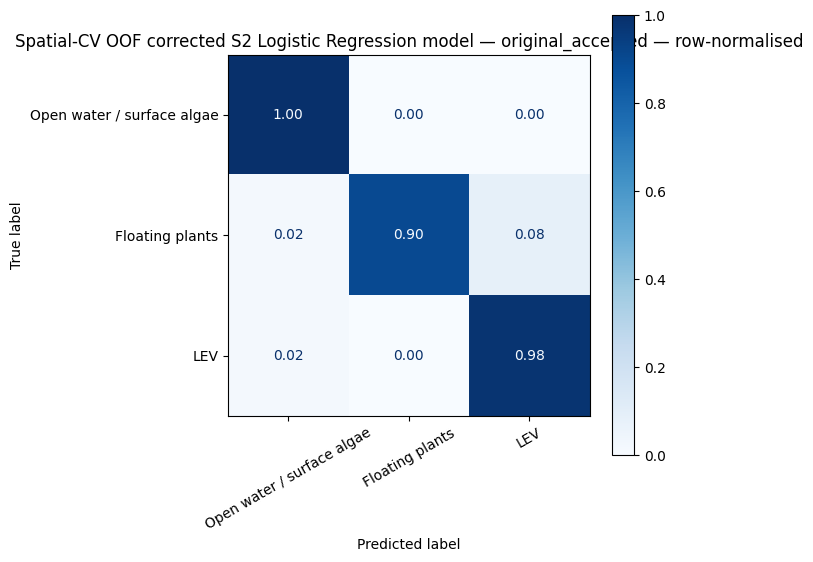


Spatial-CV OOF corrected S2 Logistic Regression model — original_accepted raw counts:


,Open water / surface algae,Floating plants,LEV
Open water / surface algae,121,0,0
Floating plants,1,54,5
LEV,1,0,56



Spatial-CV OOF corrected S2 Logistic Regression model — original_accepted row-normalised proportions:


,Open water / surface algae,Floating plants,LEV
Open water / surface algae,1.000000,0.0,0.000000
Floating plants,0.016667,0.9,0.083333
LEV,0.017544,0.0,0.982456


Spatial-CV OOF corrected S2 Logistic Regression model — original_accepted: Floating plants correct=54, confused as Open water / surface algae=1, confused as LEV=5; mainly confused with LEV.
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_spatial_cv_oof_original_accepted_raw_counts_manual_corrected_confusion_matrix.csv
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_spatial_cv_oof_original_accepted_row_normalised_manual_corrected_confusion_matrix.csv
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_spatial_cv_oof_original_accepted_raw_counts_manual_corrected_confusion_matrix.png
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_spatial_cv_oof_original_accepted_row_normalised_manual_corrected_confusion_matrix.png


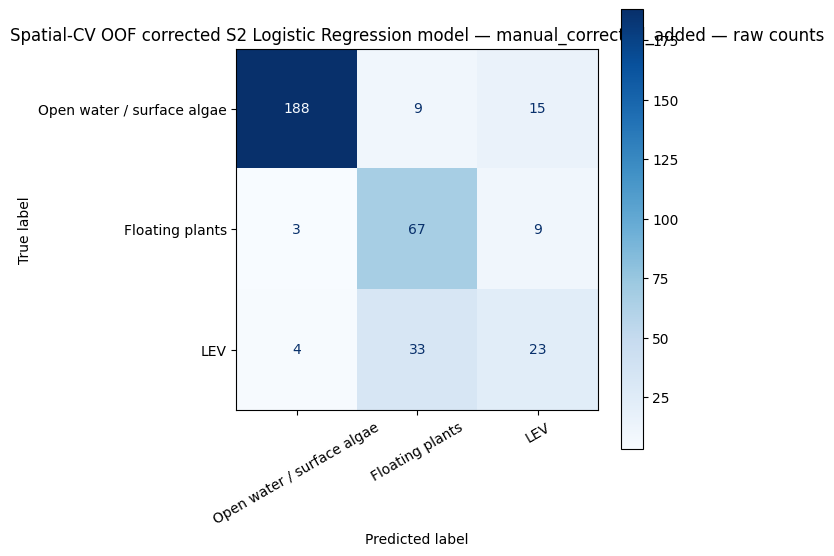

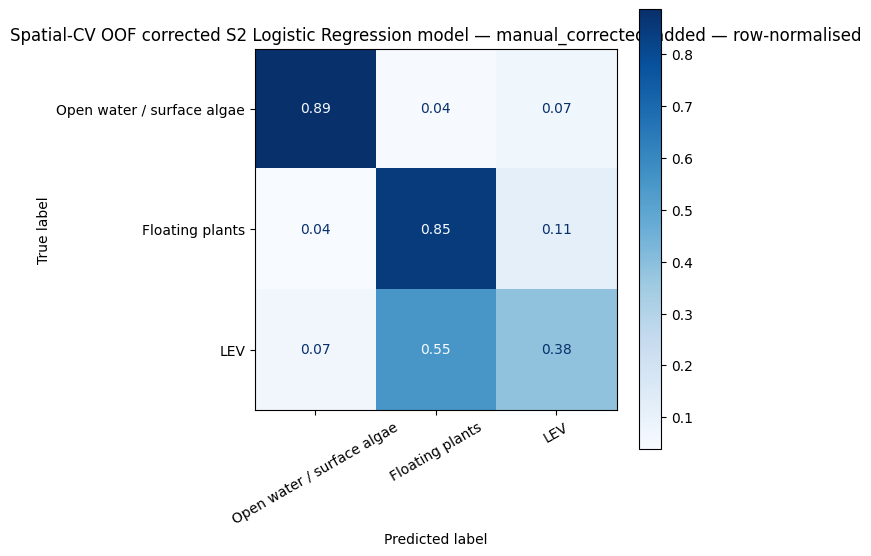


Spatial-CV OOF corrected S2 Logistic Regression model — manual_corrected_added raw counts:


,Open water / surface algae,Floating plants,LEV
Open water / surface algae,188,9,15
Floating plants,3,67,9
LEV,4,33,23



Spatial-CV OOF corrected S2 Logistic Regression model — manual_corrected_added row-normalised proportions:


,Open water / surface algae,Floating plants,LEV
Open water / surface algae,0.886792,0.042453,0.070755
Floating plants,0.037975,0.848101,0.113924
LEV,0.066667,0.550000,0.383333


Spatial-CV OOF corrected S2 Logistic Regression model — manual_corrected_added: Floating plants correct=67, confused as Open water / surface algae=3, confused as LEV=9; mainly confused with LEV.
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_spatial_cv_oof_manual_corrected_added_raw_counts_manual_corrected_confusion_matrix.csv
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_spatial_cv_oof_manual_corrected_added_row_normalised_manual_corrected_confusion_matrix.csv
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_spatial_cv_oof_manual_corrected_added_raw_counts_manual_corrected_confusion_matrix.png
Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_spatial_cv_oof_manual_corrected_added_row_normalised_manual_corrected_confusion_matrix.png

Interpretation summary:
Fixed-validation corrected-minus-old floating F1 delta:
model
Logistic Regression baseline    0.032647
dtype: float64
Manual/corrected-minus-ori

In [14]:

# =====================================================================
# 8d. S2 more-training-data diagnostics
#
# These checks diagnose whether lower S2 Route B scores after adding manual
# correction rows reflect a degraded classifier or a harder, more spatially
# diverse evaluation set. Outputs are written with the suffix
# "_diagnostic_more_training_data_check" so existing result files are not
# overwritten.
# =====================================================================

RUN_S2_MORE_TRAINING_DATA_DIAGNOSTICS = MANUAL_CORRECTIONS_ENABLED
S2_DIAGNOSTIC_SUFFIX = '_diagnostic_more_training_data_check'
S2_DIAGNOSTIC_MODEL_NAME = 'Logistic Regression baseline'
S2_DIAGNOSTIC_VALIDATION_FRACTION = 0.25
S2_DIAGNOSTIC_LEARNING_SIZES = [100, 200, 300, 400, 500, 'all']
S2_DIAGNOSTIC_LEARNING_REPEATS = 10
S2_DIAGNOSTIC_RANDOM_STATE = SPATIAL_CV_RANDOM_STATE + 711
S2_DIAGNOSTIC_RUN_ALL_CANDIDATES = False


def _s2_diag_candidate_models(seed=S2_DIAGNOSTIC_RANDOM_STATE):
    candidates = make_candidate_classifiers(seed=seed, include_svm=INCLUDE_SVM_CANDIDATE)
    if S2_DIAGNOSTIC_RUN_ALL_CANDIDATES:
        return candidates
    if S2_DIAGNOSTIC_MODEL_NAME not in candidates:
        raise ValueError(f'{S2_DIAGNOSTIC_MODEL_NAME!r} is not available in candidate classifiers.')
    return {S2_DIAGNOSTIC_MODEL_NAME: candidates[S2_DIAGNOSTIC_MODEL_NAME]}


def _s2_diag_ready_df(df, predictors):
    ready = df.copy()
    if 'manual_correction' not in ready.columns:
        ready['manual_correction'] = 0
    ready['manual_correction'] = pd.to_numeric(ready['manual_correction'], errors='coerce').fillna(0).astype(int)
    ready['correction_source'] = np.where(ready['manual_correction'].eq(1), 'manual_corrected_added', 'original_accepted')
    ready = assign_spatial_blocks(ready, block_degrees=SPATIAL_BLOCK_DEGREES)
    ready = ready.dropna(subset=list(predictors) + [CLASS_COLUMN, 'spatial_block']).copy()
    ready['_s2_diag_row_id'] = np.arange(len(ready), dtype=int)
    return ready


def _metric_row(y_true, y_pred, labels, prefix=None):
    p, r, floating_f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[FLOATING_CLASS_CODE], zero_division=0
    )
    row = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'kappa': cohen_kappa_score(y_true, y_pred, labels=labels),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'floating_precision': p[0],
        'floating_recall': r[0],
        'floating_f1': floating_f1[0],
        'floating_support': int(support[0]),
        'n_rows': int(len(y_true)),
    }
    if prefix:
        row = {f'{prefix}{k}': v for k, v in row.items()}
    return row


S2_MANUAL_CONFUSION_SUFFIX = '_manual_corrected_confusion_matrix'
S2_MANUAL_CONFUSION_LABELS = [
    'Open water / surface algae',
    'Floating plants',
    'LEV',
]
S2_MANUAL_CONFUSION_CODE_TO_LABEL = {
    0: 'Open water / surface algae',
    3: 'Open water / surface algae',
    2: 'Floating plants',
    1: 'LEV',
}


def _s2_main_label_series(values):
    """Collapse S2 Route B class codes to the three main reporting labels."""
    mapped = pd.Series(values).astype(int).map(S2_MANUAL_CONFUSION_CODE_TO_LABEL)
    if mapped.isna().any():
        missing = sorted(pd.Series(values)[mapped.isna()].astype(int).unique())
        raise ValueError(f'Unexpected S2 class code(s) for confusion matrix: {missing}')
    return mapped


def _s2_confusion_table(y_true, y_pred, normalize=None):
    cm = confusion_matrix(
        _s2_main_label_series(y_true),
        _s2_main_label_series(y_pred),
        labels=S2_MANUAL_CONFUSION_LABELS,
        normalize=normalize,
    )
    return pd.DataFrame(cm, index=S2_MANUAL_CONFUSION_LABELS, columns=S2_MANUAL_CONFUSION_LABELS)


def _s2_confusion_interpretation(title, counts):
    floating_row = counts.loc['Floating plants']
    water_confusions = int(floating_row.get('Open water / surface algae', 0))
    lev_confusions = int(floating_row.get('LEV', 0))
    correct = int(floating_row.get('Floating plants', 0))
    if water_confusions > lev_confusions:
        dominant = 'mainly confused with Open water / surface algae'
    elif lev_confusions > water_confusions:
        dominant = 'mainly confused with LEV'
    elif water_confusions == lev_confusions == 0:
        dominant = 'not confused with either Open water / surface algae or LEV'
    else:
        dominant = 'split evenly between Open water / surface algae and LEV'
    return (
        f'{title}: Floating plants correct={correct}, confused as '
        f'Open water / surface algae={water_confusions}, confused as LEV={lev_confusions}; '
        f'{dominant}.'
    )


def _save_s2_confusion_outputs(records, stem, title):
    """Save count/proportion CSVs and PNGs for S2 three-label confusion matrices."""
    records = records.copy()
    if records.empty:
        print(f'{title}: no records; confusion matrix not saved.')
        return None, None
    counts = _s2_confusion_table(records['true_class'], records['predicted_class'])
    proportions = _s2_confusion_table(records['true_class'], records['predicted_class'], normalize='true')
    counts_path = LOCAL_OUTPUT_DIR / f'{stem}_raw_counts{S2_MANUAL_CONFUSION_SUFFIX}.csv'
    proportions_path = LOCAL_OUTPUT_DIR / f'{stem}_row_normalised{S2_MANUAL_CONFUSION_SUFFIX}.csv'
    counts_png = LOCAL_OUTPUT_DIR / f'{stem}_raw_counts{S2_MANUAL_CONFUSION_SUFFIX}.png'
    proportions_png = LOCAL_OUTPUT_DIR / f'{stem}_row_normalised{S2_MANUAL_CONFUSION_SUFFIX}.png'
    counts.to_csv(counts_path)
    proportions.to_csv(proportions_path, float_format='%.6f')
    for matrix, path, values_format, plot_title in [
        (counts, counts_png, 'd', f'{title} — raw counts'),
        (proportions, proportions_png, '.2f', f'{title} — row-normalised'),
    ]:
        fig, ax = plt.subplots(figsize=(7, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=matrix.to_numpy(), display_labels=S2_MANUAL_CONFUSION_LABELS)
        disp.plot(ax=ax, cmap='Blues', values_format=values_format, colorbar=True)
        ax.set_title(plot_title)
        ax.tick_params(axis='x', rotation=30)
        fig.tight_layout()
        fig.savefig(path, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)
    print(f'\n{title} raw counts:')
    display(counts)
    print(f'\n{title} row-normalised proportions:')
    display(proportions)
    print(_s2_confusion_interpretation(title, counts))
    for path in [counts_path, proportions_path, counts_png, proportions_png]:
        print('Saved:', path)
    return counts, proportions


def _spatial_validation_row_ids(df, validation_fraction=S2_DIAGNOSTIC_VALIDATION_FRACTION,
                                random_state=S2_DIAGNOSTIC_RANDOM_STATE):
    """Choose held-out spatial blocks, then adjust within the selected blocks when possible.

    The primary split unit is spatial_block. Because a 36-block/589-row dataset can have
    uneven class counts per block, exact class stratification is not always feasible; the
    summary table records the realised class/block composition.
    """
    rng = np.random.default_rng(random_state)
    blocks = df['spatial_block'].drop_duplicates().to_numpy()
    block_stats = df.groupby('spatial_block').agg(n=('_s2_diag_row_id', 'size')).reset_index()
    target_n = max(1, int(round(len(df) * validation_fraction)))
    best_blocks, best_score = None, np.inf
    overall_class = df[CLASS_COLUMN].value_counts(normalize=True).sort_index()
    for _ in range(1000):
        shuffled = rng.permutation(blocks)
        chosen, total = [], 0
        for b in shuffled:
            chosen.append(b)
            total += int(block_stats.loc[block_stats['spatial_block'].eq(b), 'n'].iloc[0])
            if total >= target_n:
                break
        sub = df[df['spatial_block'].isin(chosen)]
        class_share = sub[CLASS_COLUMN].value_counts(normalize=True).reindex(overall_class.index, fill_value=0)
        score = abs(len(sub) - target_n) / len(df) + (class_share - overall_class).abs().sum()
        if score < best_score:
            best_blocks, best_score = chosen, score
    return set(df.loc[df['spatial_block'].isin(best_blocks), '_s2_diag_row_id'])


def run_s2_fixed_validation_diagnostic(df, predictors, class_names):
    labels = sorted(class_names.keys())
    ready = _s2_diag_ready_df(df, predictors)
    validation_ids = _spatial_validation_row_ids(ready)
    valid = ready[ready['_s2_diag_row_id'].isin(validation_ids)].copy()
    train_full = ready[~ready['_s2_diag_row_id'].isin(validation_ids)].copy()
    train_original = train_full[train_full['correction_source'].eq('original_accepted')].copy()
    candidates = _s2_diag_candidate_models()
    rows = []
    corrected_validation_predictions = []
    for model_name, template in candidates.items():
        for arm, train_df in [('old_uncorrected_subset_only', train_original),
                              ('corrected_full_excluding_validation', train_full)]:
            model = clone(template)
            model.fit(train_df[predictors].astype(np.float32), train_df[CLASS_COLUMN].astype(int))
            pred = model.predict(valid[predictors].astype(np.float32))
            row = _metric_row(valid[CLASS_COLUMN].astype(int), pred, labels)
            row.update({
                'sensor': 'S2 Route B', 'diagnostic': 'fixed_validation_set', 'model': model_name,
                'train_arm': arm, 'train_rows': len(train_df), 'train_blocks': train_df['spatial_block'].nunique(),
                'validation_rows': len(valid), 'validation_blocks': valid['spatial_block'].nunique(),
                'validation_manual_rows': int(valid['manual_correction'].sum()),
            })
            rows.append(row)
            if model_name == S2_DIAGNOSTIC_MODEL_NAME and arm == 'corrected_full_excluding_validation':
                pred_df = valid[['_s2_diag_row_id', 'correction_source', 'manual_correction', 'spatial_block', CLASS_COLUMN]].copy()
                pred_df = pred_df.rename(columns={CLASS_COLUMN: 'true_class'})
                pred_df['predicted_class'] = pred.astype(int)
                corrected_validation_predictions.append(pred_df)
    out = pd.DataFrame(rows)
    path = LOCAL_OUTPUT_DIR / f'winam_s2_fixed_validation{S2_DIAGNOSTIC_SUFFIX}.csv'
    out.to_csv(path, index=False)
    print('\nS2 fixed-validation fair comparison:')
    display(out[['model', 'train_arm', 'train_rows', 'validation_rows', 'accuracy', 'balanced_accuracy', 'kappa', 'macro_f1', 'weighted_f1', 'floating_precision', 'floating_recall', 'floating_f1']])
    print('Saved:', path)
    if corrected_validation_predictions:
        fixed_preds = pd.concat(corrected_validation_predictions, ignore_index=True)
        fixed_preds_path = LOCAL_OUTPUT_DIR / f'winam_s2_fixed_validation_predictions{S2_MANUAL_CONFUSION_SUFFIX}.csv'
        fixed_preds.to_csv(fixed_preds_path, index=False)
        print('Saved:', fixed_preds_path)
        _save_s2_confusion_outputs(
            fixed_preds,
            'winam_s2_fixed_validation_corrected_model',
            'Fixed-validation corrected S2 Logistic Regression model',
        )
    return out


def _sample_spatial_training_subset(df, target_size, rng):
    if target_size == 'all' or int(target_size) >= len(df):
        return df.copy()
    target_size = int(target_size)
    blocks = rng.permutation(df['spatial_block'].drop_duplicates().to_numpy())
    chosen = []
    for b in blocks:
        chosen.append(b)
        if len(df[df['spatial_block'].isin(chosen)]) >= target_size:
            break
    sub = df[df['spatial_block'].isin(chosen)].copy()
    if len(sub) > target_size:
        stratify = _safe_stratify(sub[CLASS_COLUMN], 1 - target_size / len(sub))
        sub, _ = train_test_split(sub, train_size=target_size, random_state=int(rng.integers(0, 1_000_000)), stratify=stratify)
    return sub.copy()


def run_s2_learning_curve_diagnostic(df, predictors, class_names):
    labels = sorted(class_names.keys())
    ready = _s2_diag_ready_df(df, predictors)
    validation_ids = _spatial_validation_row_ids(ready)
    valid = ready[ready['_s2_diag_row_id'].isin(validation_ids)].copy()
    train_pool = ready[~ready['_s2_diag_row_id'].isin(validation_ids)].copy()
    rng = np.random.default_rng(S2_DIAGNOSTIC_RANDOM_STATE)
    candidates = _s2_diag_candidate_models()
    rows = []
    for size in S2_DIAGNOSTIC_LEARNING_SIZES:
        if size != 'all' and int(size) > len(train_pool):
            continue
        repeats = 1 if size == 'all' else S2_DIAGNOSTIC_LEARNING_REPEATS
        for repeat in range(repeats):
            subset = _sample_spatial_training_subset(train_pool, size, rng)
            for model_name, template in candidates.items():
                model = clone(template)
                model.fit(subset[predictors].astype(np.float32), subset[CLASS_COLUMN].astype(int))
                pred = model.predict(valid[predictors].astype(np.float32))
                row = _metric_row(valid[CLASS_COLUMN].astype(int), pred, labels)
                row.update({'sensor': 'S2 Route B', 'diagnostic': 'learning_curve', 'model': model_name,
                            'requested_train_size': size, 'repeat': repeat, 'train_rows': len(subset),
                            'train_blocks': subset['spatial_block'].nunique(), 'validation_rows': len(valid)})
                rows.append(row)
    per_repeat = pd.DataFrame(rows)
    metric_cols = ['accuracy', 'balanced_accuracy', 'kappa', 'macro_f1', 'weighted_f1',
                   'floating_precision', 'floating_recall', 'floating_f1']
    agg = per_repeat.groupby(['sensor', 'diagnostic', 'model', 'requested_train_size'], dropna=False).agg(
        train_rows_mean=('train_rows', 'mean'), train_blocks_mean=('train_blocks', 'mean'),
        repeats=('repeat', 'nunique'), **{f'{m}_mean': (m, 'mean') for m in metric_cols},
        **{f'{m}_std': (m, 'std') for m in metric_cols}
    ).reset_index()
    per_repeat_path = LOCAL_OUTPUT_DIR / f'winam_s2_learning_curve_repeats{S2_DIAGNOSTIC_SUFFIX}.csv'
    agg_path = LOCAL_OUTPUT_DIR / f'winam_s2_learning_curve_summary{S2_DIAGNOSTIC_SUFFIX}.csv'
    plot_path = LOCAL_OUTPUT_DIR / f'winam_s2_learning_curve_floating_f1{S2_DIAGNOSTIC_SUFFIX}.png'
    per_repeat.to_csv(per_repeat_path, index=False)
    agg.to_csv(agg_path, index=False)
    fig, ax = plt.subplots(figsize=(7, 5))
    for model_name, sub in agg.groupby('model'):
        x = sub['train_rows_mean'].astype(float)
        y = sub['floating_f1_mean'].astype(float)
        yerr = sub['floating_f1_std'].fillna(0).astype(float)
        ax.errorbar(x, y, yerr=yerr, marker='o', capsize=3, label=model_name)
    ax.set_xlabel('Training rows (mean realised subset size)')
    ax.set_ylabel('Floating-plants F1 on fixed validation set')
    ax.set_title('S2 learning curve diagnostic')
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(plot_path, dpi=150)
    plt.show()
    plt.close(fig)
    print('\nS2 learning-curve summary:')
    display(agg[['model', 'requested_train_size', 'train_rows_mean', 'train_blocks_mean', 'floating_f1_mean', 'floating_f1_std', 'accuracy_mean', 'balanced_accuracy_mean']])
    print('Saved:', agg_path)
    print('Saved:', per_repeat_path)
    print('Saved:', plot_path)
    return agg, per_repeat


def run_s2_point_difficulty_diagnostic(df, predictors, class_names):
    labels = sorted(class_names.keys())
    ready = _s2_diag_ready_df(df, predictors)
    X = ready[predictors].astype(np.float32).to_numpy()
    y = ready[CLASS_COLUMN].astype(int).to_numpy()
    groups = ready['spatial_block'].to_numpy()
    model_template = _s2_diag_candidate_models()[S2_DIAGNOSTIC_MODEL_NAME]
    rng = np.random.default_rng(S2_DIAGNOSTIC_RANDOM_STATE)
    unique_groups = np.unique(groups)
    pred_rows = []
    for repeat in range(SPATIAL_CV_N_REPEATS):
        shuffled = rng.permutation(unique_groups)
        group_to_fold = {g: i % SPATIAL_CV_N_SPLITS for i, g in enumerate(shuffled)}
        fold_assignments = np.array([group_to_fold[g] for g in groups])
        for fold in range(SPATIAL_CV_N_SPLITS):
            test_idx = np.where(fold_assignments == fold)[0]
            train_idx = np.where(fold_assignments != fold)[0]
            if len(test_idx) == 0 or len(train_idx) == 0:
                continue
            model = clone(model_template)
            model.fit(X[train_idx], y[train_idx])
            pred = model.predict(X[test_idx])
            fold_df = ready.iloc[test_idx][['_s2_diag_row_id', 'correction_source', 'manual_correction', 'spatial_block', CLASS_COLUMN]].copy()
            fold_df['prediction'] = pred
            fold_df['repeat'] = repeat
            fold_df['fold'] = fold
            pred_rows.append(fold_df)
    preds = pd.concat(pred_rows, ignore_index=True)
    rows = []
    for source, sub in preds.groupby('correction_source'):
        row = _metric_row(sub[CLASS_COLUMN].astype(int), sub['prediction'].astype(int), labels)
        row.update({'sensor': 'S2 Route B', 'diagnostic': 'point_difficulty_spatial_cv',
                    'model': S2_DIAGNOSTIC_MODEL_NAME, 'correction_source': source,
                    'unique_points': sub['_s2_diag_row_id'].nunique(), 'spatial_blocks': sub['spatial_block'].nunique()})
        rows.append(row)
    metrics = pd.DataFrame(rows)
    metrics_path = LOCAL_OUTPUT_DIR / f'winam_s2_point_difficulty{S2_DIAGNOSTIC_SUFFIX}.csv'
    preds_path = LOCAL_OUTPUT_DIR / f'winam_s2_point_difficulty_predictions{S2_DIAGNOSTIC_SUFFIX}.csv'
    metrics.to_csv(metrics_path, index=False)
    preds.to_csv(preds_path, index=False)
    print('\nS2 corrected-vs-original point difficulty (spatial-CV predictions):')
    display(metrics[['correction_source', 'unique_points', 'spatial_blocks', 'accuracy', 'balanced_accuracy', 'kappa', 'macro_f1', 'weighted_f1', 'floating_precision', 'floating_recall', 'floating_f1']])
    print('Saved:', metrics_path)
    print('Saved:', preds_path)
    return metrics, preds


def run_s2_manual_corrected_oof_confusion_matrices(df, predictors):
    """Save one-repeat spatial-CV out-of-fold confusion matrices for all corrected S2 rows."""
    ready = _s2_diag_ready_df(df, predictors)
    X = ready[predictors].astype(np.float32).to_numpy()
    y = ready[CLASS_COLUMN].astype(int).to_numpy()
    groups = ready['spatial_block'].to_numpy()
    model_template = _s2_diag_candidate_models()[S2_DIAGNOSTIC_MODEL_NAME]
    rng = np.random.default_rng(S2_DIAGNOSTIC_RANDOM_STATE)
    unique_groups = rng.permutation(np.unique(groups))
    group_to_fold = {g: i % SPATIAL_CV_N_SPLITS for i, g in enumerate(unique_groups)}
    fold_assignments = np.array([group_to_fold[g] for g in groups])
    pred_rows = []
    for fold in range(SPATIAL_CV_N_SPLITS):
        test_idx = np.where(fold_assignments == fold)[0]
        train_idx = np.where(fold_assignments != fold)[0]
        model = clone(model_template)
        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        fold_df = ready.iloc[test_idx][['_s2_diag_row_id', 'correction_source', 'manual_correction', 'spatial_block', CLASS_COLUMN]].copy()
        fold_df = fold_df.rename(columns={CLASS_COLUMN: 'true_class'})
        fold_df['predicted_class'] = pred.astype(int)
        fold_df['fold'] = fold
        pred_rows.append(fold_df)
    oof = pd.concat(pred_rows, ignore_index=True).sort_values('_s2_diag_row_id').reset_index(drop=True)
    if oof['_s2_diag_row_id'].nunique() != len(ready):
        raise ValueError('Spatial-CV OOF predictions do not cover each corrected S2 row exactly once.')
    oof_path = LOCAL_OUTPUT_DIR / f'winam_s2_spatial_cv_oof_predictions{S2_MANUAL_CONFUSION_SUFFIX}.csv'
    oof.to_csv(oof_path, index=False)
    print('Saved:', oof_path)
    _save_s2_confusion_outputs(oof, 'winam_s2_spatial_cv_oof_all_corrected_data', f'Spatial-CV OOF corrected S2 Logistic Regression model ({len(oof)} rows)')
    for source in ['original_accepted', 'manual_corrected_added']:
        sub = oof[oof['correction_source'].eq(source)].copy()
        _save_s2_confusion_outputs(sub, f'winam_s2_spatial_cv_oof_{source}', f'Spatial-CV OOF corrected S2 Logistic Regression model — {source}')
    return oof


s2_more_training_fixed_validation = None
s2_more_training_learning_curve = None
s2_more_training_point_difficulty = None
if RUN_S2_MORE_TRAINING_DATA_DIAGNOSTICS:
    s2_diag_ready_preview = _s2_diag_ready_df(s2_clean_df, S2_PREDICTORS)
    print(f"\nS2 more-training-data diagnostics input: {len(s2_diag_ready_preview)} rows across "
          f"{s2_diag_ready_preview['spatial_block'].nunique()} spatial blocks; "
          f"manual/corrected rows={int(s2_diag_ready_preview['manual_correction'].sum())}.")
    s2_more_training_fixed_validation = run_s2_fixed_validation_diagnostic(
        s2_clean_df, S2_PREDICTORS, S2_CLASS_NAMES
    )
    s2_more_training_learning_curve, s2_more_training_learning_curve_repeats = run_s2_learning_curve_diagnostic(
        s2_clean_df, S2_PREDICTORS, S2_CLASS_NAMES
    )
    s2_more_training_point_difficulty, s2_more_training_point_predictions = run_s2_point_difficulty_diagnostic(
        s2_clean_df, S2_PREDICTORS, S2_CLASS_NAMES
    )
    s2_manual_corrected_oof_predictions = run_s2_manual_corrected_oof_confusion_matrices(
        s2_clean_df, S2_PREDICTORS
    )

    fixed_wide = s2_more_training_fixed_validation.pivot_table(
        index='model', columns='train_arm', values='floating_f1', aggfunc='first'
    )
    difficulty_wide = s2_more_training_point_difficulty.set_index('correction_source')['floating_f1']
    if {'old_uncorrected_subset_only', 'corrected_full_excluding_validation'}.issubset(fixed_wide.columns):
        delta = fixed_wide['corrected_full_excluding_validation'] - fixed_wide['old_uncorrected_subset_only']
        print('\nInterpretation summary:')
        print('Fixed-validation corrected-minus-old floating F1 delta:')
        print(delta)
    if {'manual_corrected_added', 'original_accepted'}.issubset(difficulty_wide.index):
        hard_delta = difficulty_wide['manual_corrected_added'] - difficulty_wide['original_accepted']
        print(f'Manual/corrected-minus-original spatial-CV floating F1 delta: {hard_delta:.3f}')
        if hard_delta < 0:
            print('Added rows appear harder and/or more spatially diverse; a lower aggregate CV score is therefore more consistent with a harder evaluation distribution than with classifier degradation.')
        else:
            print('Manual/corrected rows are not harder by floating F1 in this diagnostic; investigate label consistency or model fit if fixed-validation performance also drops.')
else:
    print('S2 more-training-data diagnostics skipped because manual corrections are not enabled.')


### 8c. Training-data scope ablation — should the other lakes help train the Winam classifier?

The training CSVs contain eight lakes, but the production classifier trains on **Winam only** (`TRAIN_LOCATION_FILTER = 'Winam'` in section 2). Because the classifier is **only ever deployed on Winam**, the right question is not "does more data raise the cross-lake score?" but "does adding the other lakes raise accuracy **on Winam**?" This section answers that empirically.

**Design.** Every arm is scored on **held-out Winam spatial blocks** (the same ~0.1° grouped k-fold used in 8b, repeated `ABLATION_N_REPEATS` times). The arms differ only in what is allowed into the *training* fold, so the held-out Winam test points are identical across arms and the comparison is **paired**:

| Arm | Trains on | Question it answers |
|-----|-----------|---------------------|
| **A — Winam-only** | the other Winam blocks | the production baseline |
| **B — Pooled** | other Winam blocks **+ all seven other lakes** | does external data help Winam? |
| **C — Leave-Winam-out** | the seven other lakes **only** | how far does a purely cross-site model transfer to Winam? |

**Why paired deltas.** A, B and C predict the *same* Winam points each fold, so the honest test is the per-fold difference `floating_f1(B) − floating_f1(A)` (and `C − A`), not a contrast of aggregated means against a marginal SD — the latter buries a real effect inside between-fold variance. The verdict reports the mean paired delta with its standard error and the fold win-rate.

**Decision rule.** If B beats A on held-out Winam by more than ~1 SE for the production-selected model, pooling is justified — set `TRAIN_LOCATION_FILTER = None` in section 2 and re-run. If the delta is ≤ 0 (negative transfer) or within ±1 SE of zero (no benefit), keep `'Winam'`: the simpler, locally-trained model is the defensible choice for a Winam-only deliverable.

**Feature-provenance note (S1).** The ablation uses the predictor columns exactly as stored in the training CSVs — `S2_PREDICTORS` for S2 and the stored SCC columns `S1_PREDICTORS` (`VH_p5, VH_corrected, VH_smooth`) for S1 — applied identically to every lake and arm, so the contrast isolates training-data **scope** with no Earth Engine round-trip. The production S1 model re-derives those predictors through GEE for Winam (section 7); because all three arms share one feature definition here, the *scope* conclusion is unaffected, though the S1 arm's absolute floating-F1 is a close proxy for, not a reproduction of, the production S1 pipeline.

**Scope.** This is a diagnostic and does not change the production model. It writes `winam_training_scope_ablation_<version>.csv` and prints, per sensor, a model×arm table plus the paired verdict. Set `RUN_TRAINING_SCOPE_ABLATION = False` to skip it on routine batch runs.

In [ ]:
# =====================================================================
# 8c. Training-data scope ablation: does adding the other lakes help Winam?
#
# The production classifier trains on Winam only (TRAIN_LOCATION_FILTER='Winam').
# The training CSVs also hold seven other lakes. This diagnostic answers, on the
# only distribution we deploy to (Winam), whether pooling those lakes helps.
#
# Every arm is SCORED on held-out Winam spatial blocks; the arms differ only in
# which rows are allowed into the TRAIN fold:
#   A_winam_only       train on the other Winam blocks
#   B_pooled           train on the other Winam blocks + all seven other lakes
#   C_leave_winam_out  train on the seven other lakes only (pure cross-site transfer)
# Identical Winam test points per fold => a paired A/B/C comparison and an honest,
# Winam-specific floating_f1 (not a pooled average dominated by off-target lakes).
#
# Feature provenance: the ablation uses the predictor columns as stored in the
# training CSVs (S2_PREDICTORS for S2; the stored SCC columns S1_PREDICTORS for
# S1), applied identically to every lake and every arm, so the contrast isolates
# training-data SCOPE with no Earth Engine round-trip. The production S1 model
# re-derives its predictors via GEE for Winam; because all three arms share one
# feature definition here, the scope conclusion (does external data help Winam?)
# is unaffected.
#
# Acting on the result: if B beats A on held-out Winam floating_f1 by more than
# ~1 SD for the production-selected model, pooling is justified -- set
# TRAIN_LOCATION_FILTER=None in section 2 and re-run. Otherwise keep 'Winam'.
# =====================================================================

RUN_TRAINING_SCOPE_ABLATION = False         # disabled: keep this notebook Winam-Gulf-only (the ablation trains on the other lakes)
ABLATION_TARGET_LOCATION = TRAIN_LOCATION_FILTER   # deployment domain = Winam
ABLATION_N_SPLITS = SPATIAL_CV_N_SPLITS
ABLATION_N_REPEATS = 5                       # repeated block->fold shuffles for variance
ABLATION_RANDOM_STATE = SPATIAL_CV_RANDOM_STATE
# Candidate models to run under each arm. None = every candidate from
# make_candidate_classifiers(); the default trims to a representative, faster set.
ABLATION_MODELS = ['Random Forest', 'Class-weighted RF',
                   'Hist Gradient Boosting', 'Logistic Regression baseline']
ABLATION_METRIC = MODEL_SELECTION_METRIC     # 'floating_f1' by default
ABLATION_RESULTS_CSV = LOCAL_OUTPUT_DIR / f'winam_training_scope_ablation_{CLASSIFIER_VERSION}.csv'
_ABLATION_ARM_ORDER = ['A_winam_only', 'B_pooled', 'C_leave_winam_out']


def _target_heldout_block_folds(blocks_target, n_splits, n_repeats, random_state):
    """Grouped k-fold over the target-location spatial blocks, reshuffling the
    block->fold assignment each repeat. Yields (repeat, fold, test_mask)."""
    rng = np.random.default_rng(random_state)
    unique_blocks = np.unique(blocks_target)
    if len(unique_blocks) < n_splits:
        raise ValueError(
            f'Only {len(unique_blocks)} {ABLATION_TARGET_LOCATION} spatial blocks but '
            f'ABLATION_N_SPLITS={n_splits}. Reduce SPATIAL_BLOCK_DEGREES or ABLATION_N_SPLITS.'
        )
    for repeat in range(n_repeats):
        shuffled = rng.permutation(unique_blocks)
        block_to_fold = {b: i % n_splits for i, b in enumerate(shuffled)}
        fold_of_row = np.array([block_to_fold[b] for b in blocks_target])
        for fold in range(n_splits):
            yield repeat, fold, (fold_of_row == fold)


def run_training_scope_ablation(df_raw, class_mapping, predictors, class_names, sensor_name):
    """Paired A/B/C scope ablation, scored on held-out target-location blocks."""
    full = prepare_route_b_raw_df(df_raw, class_mapping, location_filter=None)
    full = assign_spatial_blocks(full, block_degrees=SPATIAL_BLOCK_DEGREES)
    full = full.dropna(subset=predictors + [CLASS_COLUMN, 'spatial_block']).copy()

    is_target = full['Location'].astype(str).eq(ABLATION_TARGET_LOCATION).to_numpy()
    target = full[is_target].reset_index(drop=True)
    other = full[~is_target].reset_index(drop=True)
    if target.empty:
        raise ValueError(f'{sensor_name}: no {ABLATION_TARGET_LOCATION} rows for the ablation.')
    if other.empty:
        raise ValueError(f'{sensor_name}: no non-{ABLATION_TARGET_LOCATION} rows to pool.')

    Xt = target[predictors].astype(np.float32).to_numpy()
    yt = target[CLASS_COLUMN].astype(int).to_numpy()
    blocks_t = target['spatial_block'].to_numpy()
    Xo = other[predictors].astype(np.float32).to_numpy()
    yo = other[CLASS_COLUMN].astype(int).to_numpy()
    labels = sorted(class_names.keys()) if class_names else sorted(np.unique(yt))

    other_locs = sorted(other['Location'].astype(str).unique())
    print(f'\n=== {sensor_name}: training-scope ablation (scored on held-out '
          f'{ABLATION_TARGET_LOCATION}) ===')
    print(f'{ABLATION_TARGET_LOCATION}: {len(target)} rows / {len(np.unique(blocks_t))} '
          f'spatial blocks | other lakes: {len(other)} rows from {len(other_locs)} sites '
          f'({", ".join(other_locs)})')

    candidates = make_candidate_classifiers(seed=ABLATION_RANDOM_STATE,
                                            include_svm=INCLUDE_SVM_CANDIDATE)
    if ABLATION_MODELS is not None:
        candidates = {k: v for k, v in candidates.items() if k in set(ABLATION_MODELS)}
    if not candidates:
        raise ValueError('ABLATION_MODELS matched no candidates from make_candidate_classifiers().')

    rows = []
    for repeat, fold, test_mask in _target_heldout_block_folds(
            blocks_t, ABLATION_N_SPLITS, ABLATION_N_REPEATS, ABLATION_RANDOM_STATE):
        train_mask = ~test_mask
        if test_mask.sum() == 0 or train_mask.sum() == 0:
            continue
        X_test, y_test = Xt[test_mask], yt[test_mask]
        arms = {
            'A_winam_only': (Xt[train_mask], yt[train_mask]),
            'B_pooled': (np.vstack([Xt[train_mask], Xo]),
                         np.concatenate([yt[train_mask], yo])),
            'C_leave_winam_out': (Xo, yo),
        }
        for model_name, template in candidates.items():
            for arm, (X_tr, y_tr) in arms.items():
                if len(np.unique(y_tr)) < 2:
                    continue
                metrics = _score_split(clone(template), X_tr, y_tr, X_test, y_test, labels)
                metrics.update({'sensor': sensor_name, 'model': model_name, 'arm': arm,
                                'repeat': repeat, 'fold': fold,
                                'n_train': len(y_tr), 'n_test_target': len(y_test)})
                rows.append(metrics)
    return pd.DataFrame(rows)


def summarise_training_scope_ablation(per_fold):
    metric_cols = ['floating_f1', 'floating_precision', 'floating_recall',
                   'accuracy', 'macro_f1', 'kappa', 'floating_support']
    agg = {f'{c}_mean': (c, 'mean') for c in metric_cols}
    agg.update({f'{c}_std': (c, 'std') for c in ['floating_f1', 'accuracy', 'macro_f1']})
    agg.update({'n_folds': ('floating_f1', 'size'),
                'n_train': ('n_train', 'median'),
                'n_test_target': ('n_test_target', 'median')})
    return (per_fold.groupby(['sensor', 'model', 'arm']).agg(**agg).reset_index())


def print_training_scope_verdict(per_fold, summary, sensor_name, metric=ABLATION_METRIC):
    """Paired per-fold verdict: A/B/C share identical held-out target folds, so
    compare them as paired per-fold deltas (more powerful and correct than
    contrasting aggregated means against a marginal SD)."""
    sub = summary[summary['sensor'] == sensor_name]
    a_arm = sub[sub['arm'] == 'A_winam_only'].sort_values(f'{metric}_mean', ascending=False)
    if a_arm.empty:
        print(f'{sensor_name}: no {ABLATION_TARGET_LOCATION}-only results to judge.'); return
    best_model = a_arm.iloc[0]['model']
    wide = (per_fold[(per_fold['sensor'] == sensor_name) & (per_fold['model'] == best_model)]
            .pivot_table(index=['repeat', 'fold'], columns='arm', values=metric))
    if 'A_winam_only' not in wide.columns or 'B_pooled' not in wide.columns:
        print(f'{sensor_name}: arms missing for a paired comparison.'); return
    dB = (wide['B_pooled'] - wide['A_winam_only']).dropna()
    base = wide['A_winam_only'].mean()
    se_b = dB.std() / np.sqrt(len(dB)) if len(dB) else float('nan')
    print(f'\n{sensor_name} verdict  (model={best_model}, metric={metric}, '
          f'paired over {len(dB)} held-out {ABLATION_TARGET_LOCATION} folds):')
    print(f'  A {ABLATION_TARGET_LOCATION}-only mean        {base:.4f}')
    print(f'  B-A paired delta            {dB.mean():+.4f}   (SE {se_b:.4f}; '
          f'B>=A in {100 * (dB >= 0).mean():.0f}% of folds)')
    if 'C_leave_winam_out' in wide.columns:
        dC = (wide['C_leave_winam_out'] - wide['A_winam_only']).dropna()
        print(f'  C-A paired delta            {dC.mean():+.4f}   '
              '(pure cross-site transfer cost)')
    if np.isfinite(se_b) and se_b > 0:
        if dB.mean() - se_b > 0:
            print(f'  -> pooling IMPROVES held-out {ABLATION_TARGET_LOCATION} (delta clears +1 SE): '
                  'adding the other lakes is justified -- consider TRAIN_LOCATION_FILTER=None.')
        elif dB.mean() + se_b < 0:
            print(f'  -> pooling DEGRADES held-out {ABLATION_TARGET_LOCATION} (delta below -1 SE): '
                  f'negative transfer -- keep TRAIN_LOCATION_FILTER=\'{ABLATION_TARGET_LOCATION}\'.')
        else:
            print('  -> paired delta is within +/-1 SE of zero: no clear benefit -- '
                  'prefer the simpler local model.')


if RUN_TRAINING_SCOPE_ABLATION:
    _ablation_specs = [
        (s2_df_raw, S2_RAW_CLASS_MAPPING, S2_PREDICTORS, S2_CLASS_NAMES, 'S2 Route B'),
        (s1_df_raw, S1_RAW_CLASS_MAPPING, S1_PREDICTORS, S1_CLASS_NAMES, 'S1 Route B (CSV SCC cols)'),
    ]
    ablation_per_fold = pd.concat(
        [run_training_scope_ablation(*spec) for spec in _ablation_specs],
        ignore_index=True
    )
    ablation_summary = summarise_training_scope_ablation(ablation_per_fold)

    for _sensor in ablation_summary['sensor'].unique():
        _sub = ablation_summary[ablation_summary['sensor'] == _sensor]
        _pivot = _sub.pivot_table(index='model', columns='arm', values=f'{ABLATION_METRIC}_mean')
        _cols = [c for c in _ABLATION_ARM_ORDER if c in _pivot.columns]
        print('\n' + '=' * 80)
        print(f'{_sensor}: {ABLATION_METRIC} (held-out {ABLATION_TARGET_LOCATION}) by model x arm')
        display(_pivot[_cols].round(4))
        print_training_scope_verdict(ablation_per_fold, ablation_summary, _sensor)

    ablation_summary.to_csv(ABLATION_RESULTS_CSV, index=False)
    print('\nSaved training-scope ablation summary:', ABLATION_RESULTS_CSV)
else:
    print('RUN_TRAINING_SCOPE_ABLATION is False; skipping the training-data scope ablation.')

RUN_TRAINING_SCOPE_ABLATION is False; skipping the training-data scope ablation.


## 9. S2 predictor image builder

In [ ]:
S2_COMPOSITE_START = '2017-04-01'
S2_COMPOSITE_END = '2021-06-01'


def mask_s2_sr(img):
    scl = img.select('SCL')
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))
    return img.updateMask(mask)


def add_s2_predictors(img):
    bands = img.select(
        ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8A', 'B8', 'B11', 'B12'],
        ['B',  'G',  'R',  'RE1', 'RE2', 'RE3', 'RE4', 'NIR', 'SWIR', 'SWIR2']
    ).toFloat()
    ndvi = bands.normalizedDifference(['NIR', 'R']).rename('NDVI')
    ndmi = bands.normalizedDifference(['NIR', 'SWIR']).rename('NDMI')
    mndwi = bands.normalizedDifference(['G', 'SWIR']).rename('MNDWI')
    awei = bands.expression(
        'B + 2.5 * G - 1.5 * (NIR + SWIR) - 0.25 * SWIR2',
        {'B': bands.select('B'), 'G': bands.select('G'), 'NIR': bands.select('NIR'),
         'SWIR': bands.select('SWIR'), 'SWIR2': bands.select('SWIR2')}
    ).rename('AWEI')
    aweinsh = bands.expression(
        '4 * (G - SWIR) - (0.25 * NIR + 2.75 * SWIR2)',
        {'G': bands.select('G'), 'NIR': bands.select('NIR'),
         'SWIR': bands.select('SWIR'), 'SWIR2': bands.select('SWIR2')}
    ).rename('AWEInsh')
    return bands.addBands([ndvi, ndmi, mndwi, awei, aweinsh])


def get_s2_collection(start_date, end_date, aoi, cloud_pct=70):
    return (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_pct))
        .map(mask_s2_sr)
        .map(add_s2_predictors)
    )


def get_s2_awei_p95(aoi):
    return (get_s2_collection(S2_COMPOSITE_START, S2_COMPOSITE_END, aoi)
            .select('AWEI').reduce(ee.Reducer.percentile([95])).rename('AWEI_p95'))


def get_s2_predictor_image(start_date, end_date, aoi, cloud_pct=70, verbose=True):
    collection = get_s2_collection(start_date, end_date, aoi, cloud_pct)
    if verbose:
        print('S2 image count:', collection.size().getInfo())
    return collection.median().addBands(get_s2_awei_p95(aoi)).select(S2_PREDICTORS).clip(aoi)

## 10. Water mask, AOI restriction, and local rule-classifier helpers

In [ ]:
APPLY_JRC_WATER_MASK = True
JRC_OCCURRENCE_THRESHOLD = 5

# Keep only the single largest contiguous water body (the main lake) and drop
# small ponds/specks that sit within the AOI. With connectedPixelCount the
# main gulf saturates the cap while isolated ponds report their true (smaller)
# size, so thresholding at the cap keeps the main lake and removes the ponds.
WATER_MASK_MAIN_BODY_ONLY = True
JRC_WATER_MASK_MIN_PATCH_PIXELS = 1024  # JRC ~30 m pixels; ~0.9 km^2 cutoff

APPLY_S1_RF_CONSTRAINT = False
S1_RF_VH_THRESHOLD = -14
S1_RF_LEV_THRESHOLD = -17

APPLY_LOCAL_S1_PATCH_FILTER = False
S1_LOCAL_MIN_PATCH_PIXELS = 200

# ---------------------------------------------------------------------
# Restrict local classification to an AOI polygon.
#
# When enabled, every local classification in this notebook (model-based and
# paper-rule, single-period and full-stack batch) labels only the pixels that
# fall inside this AOI GeoJSON. Pixels outside the AOI are written as nodata
# (NODATA_VALUE) and are therefore excluded from every downstream area table,
# confidence summary and quicklook automatically. This spatial restriction is
# applied on top of the per-pixel predictor-validity mask and the EE-side JRC
# water mask, so it only ever removes area, never adds it.
RESTRICT_CLASSIFICATION_TO_AOI = True
# AOI GeoJSON (EPSG:4326). The default is the main-lake AOI: a single polygon
# covering only the main Winam Gulf / Lake Victoria water body (no smaller
# ponds), with the western edge clipped to lon 34.2046673170698.
AOI_GEOJSON_NAME = 'winam_gulf_main_lake_aoi.geojson'
# Treat a pixel as inside the AOI if the polygon touches it at all. all_touched
# keeps thin shoreline pixels; set False to require the pixel centre to be inside.
AOI_RASTERIZE_ALL_TOUCHED = True
# Where to look for AOI_GEOJSON_NAME (first existing match wins). Includes a Drive
# copy and a repo checkout so the same notebook works on Colab and locally. On
# Colab, upload the repo's aoi/ folder to one of these locations (e.g. drag it
# into MyDrive) so the AOI travels with the run.
AOI_GEOJSON_SEARCH_DIRS = [
    DRIVE_ROOT / 'aoi',
    Path('/content/drive/MyDrive/aoi'),
    Path('/content/drive/MyDrive/Dissertation/aoi'),
    Path('/content/Dissertation/aoi'),
    Path('aoi'),
    Path('.'),
]
# Optional explicit override: set to a full path string to skip the search above.
AOI_GEOJSON_PATH = None
# If the AOI GeoJSON is not found in any local/Drive search dir, fetch it
# straight from GitHub (the repo's aoi/ folder) so the AOI travels with the
# notebook and nothing has to be uploaded to Drive. Requires a public repo;
# for a private repo use a local/Drive copy or AOI_GEOJSON_PATH instead.
AOI_GEOJSON_GITHUB_FALLBACK = True
AOI_GITHUB_REPO = 'Qalani/Dissertation'
# Branch, tag, or commit SHA to read the AOI from. 'main' is stable; pin a
# commit SHA for a permanently reproducible link.
AOI_GITHUB_REF = 'main'
AOI_GITHUB_DIR = 'aoi'
# Full override of the raw URL; built from the fields above when left as None.
AOI_GEOJSON_URL = None

_AOI_GEOMS_4326_CACHE = None     # list of EPSG:4326 GeoJSON geometry dicts
_AOI_GEOMS_BY_CRS_CACHE = {}     # str(crs) -> AOI geometries reprojected to that CRS


def resolve_aoi_geojson_path():
    """Return the path to the AOI GeoJSON, or None if it cannot be located."""
    if AOI_GEOJSON_PATH:
        explicit = Path(AOI_GEOJSON_PATH)
        return explicit if explicit.exists() else None
    for search_dir in AOI_GEOJSON_SEARCH_DIRS:
        candidate = Path(search_dir) / AOI_GEOJSON_NAME
        if candidate.exists():
            return candidate
    return None


def _aoi_github_raw_url():
    """Build the raw GitHub URL for the AOI GeoJSON."""
    if AOI_GEOJSON_URL:
        return AOI_GEOJSON_URL
    return (
        f'https://raw.githubusercontent.com/{AOI_GITHUB_REPO}/'
        f'{AOI_GITHUB_REF}/{AOI_GITHUB_DIR}/{AOI_GEOJSON_NAME}'
    )


def _load_aoi_geojson_from_github():
    """Fetch and parse the AOI GeoJSON directly from GitHub.

    Returns (geojson_dict, url). Raises FileNotFoundError with a clear message
    when the download fails (wrong repo/ref/name, or a private repo that needs
    a local/Drive copy instead).
    """
    url = _aoi_github_raw_url()
    try:
        with urllib.request.urlopen(url, timeout=30) as resp:
            payload = resp.read()
    except Exception as exc:
        raise FileNotFoundError(
            f'Could not fetch the AOI GeoJSON from GitHub:\n  {url}\n  ({exc})\n'
            'Check AOI_GITHUB_REPO / AOI_GITHUB_REF / AOI_GEOJSON_NAME. If the repo '
            'is private, use a local or Drive copy (AOI_GEOJSON_SEARCH_DIRS / '
            'AOI_GEOJSON_PATH) instead, or set RESTRICT_CLASSIFICATION_TO_AOI = False.'
        ) from exc
    return json.loads(payload.decode('utf-8')), url


def load_aoi_geometries_4326():
    """Load and cache the AOI polygon(s) as EPSG:4326 GeoJSON geometry dicts.

    Returns None when AOI restriction is disabled. Raises FileNotFoundError when
    restriction is enabled but the GeoJSON cannot be found, so a misconfigured
    AOI fails loudly instead of silently classifying the whole scene.
    """
    global _AOI_GEOMS_4326_CACHE
    if not RESTRICT_CLASSIFICATION_TO_AOI:
        return None
    if _AOI_GEOMS_4326_CACHE is not None:
        return _AOI_GEOMS_4326_CACHE
    path = resolve_aoi_geojson_path()
    if path is not None:
        with open(path) as fh:
            gj = json.load(fh)
        source_desc = str(path)
    elif AOI_GEOJSON_GITHUB_FALLBACK:
        gj, source_desc = _load_aoi_geojson_from_github()
    else:
        searched = '\n  '.join(str(Path(d) / AOI_GEOJSON_NAME) for d in AOI_GEOJSON_SEARCH_DIRS)
        raise FileNotFoundError(
            'RESTRICT_CLASSIFICATION_TO_AOI is True but the AOI GeoJSON '
            f'{AOI_GEOJSON_NAME!r} was not found. Searched:\n  ' + searched +
            "\nCopy the repo's aoi/ folder to one of those locations, set "
            'AOI_GEOJSON_PATH to its full path, enable AOI_GEOJSON_GITHUB_FALLBACK '
            'to fetch it from GitHub, or set RESTRICT_CLASSIFICATION_TO_AOI = False.'
        )
    gj_type = gj.get('type')
    if gj_type == 'FeatureCollection':
        geoms = [feat['geometry'] for feat in gj.get('features', []) if feat.get('geometry')]
    elif gj_type == 'Feature':
        geoms = [gj['geometry']] if gj.get('geometry') else []
    else:
        geoms = [gj]
    if not geoms:
        raise ValueError(f'AOI GeoJSON {path} contains no usable geometries.')
    _AOI_GEOMS_4326_CACHE = geoms
    print(f'AOI restriction ON: classifying only inside {source_desc} '
          f'({len(geoms)} geometry/geometries, EPSG:4326).')
    return _AOI_GEOMS_4326_CACHE


def aoi_geometries_in_crs(dst_crs):
    """Return the AOI geometries reprojected (and cached) to ``dst_crs``.

    Returns None when AOI restriction is disabled. Reprojection is cached per CRS
    so a whole batch of same-CRS predictor rasters reprojects the AOI only once.
    """
    geoms_4326 = load_aoi_geometries_4326()
    if geoms_4326 is None:
        return None
    key = str(dst_crs)
    cached = _AOI_GEOMS_BY_CRS_CACHE.get(key)
    if cached is not None:
        return cached
    if dst_crs is None:
        # Raster carries no CRS: assume it is already in the AOI CRS (EPSG:4326).
        projected = geoms_4326
    else:
        projected = [transform_geom('EPSG:4326', dst_crs, geom) for geom in geoms_4326]
    _AOI_GEOMS_BY_CRS_CACHE[key] = projected
    return projected




def get_jrc_water_mask(aoi, occurrence_threshold=5):
    water = ee.Image('JRC/GSW1_4/GlobalSurfaceWater').select('occurrence').gte(occurrence_threshold)
    if WATER_MASK_MAIN_BODY_ONLY:
        # connectedPixelCount caps at JRC_WATER_MASK_MIN_PATCH_PIXELS; the main
        # gulf saturates the cap, isolated ponds stay below it, so AND-ing with
        # patch >= cap keeps only the main contiguous lake and drops the ponds.
        patch = water.connectedPixelCount(JRC_WATER_MASK_MIN_PATCH_PIXELS, True)
        water = water.And(patch.gte(JRC_WATER_MASK_MIN_PATCH_PIXELS))
    return water.clip(aoi)


def apply_optional_water_mask_to_predictor_image(predictor_img, aoi):
    if APPLY_JRC_WATER_MASK:
        return predictor_img.updateMask(get_jrc_water_mask(aoi, JRC_OCCURRENCE_THRESHOLD))
    return predictor_img


def classify_s2_rules_array(band_arrays, valid_mask, nodata_value=NODATA_VALUE):
    required = ['AWEI_p95', 'AWEI', 'NDMI']
    missing = [band for band in required if band not in band_arrays]
    if missing:
        raise ValueError(f'S2 rule classification needs missing bands: {missing}')
    awei_p95 = band_arrays['AWEI_p95']
    awei = band_arrays['AWEI']
    ndmi = band_arrays['NDMI']
    classified = np.full(valid_mask.shape, nodata_value, dtype=np.uint8)
    classified[valid_mask] = 1
    valid_waterbody = valid_mask & (awei_p95 >= 0)
    classified[valid_waterbody & (awei >= 0)] = 0
    classified[valid_waterbody & (awei < 0) & (ndmi >= 0.63)] = 3
    classified[valid_waterbody & (awei < 0) & (ndmi >= 0.1) & (ndmi < 0.63)] = 2
    return classified


def classify_s1_rules_array(band_arrays, valid_mask, nodata_value=NODATA_VALUE):
    required = ['VH_p5', 'VH_corrected']
    missing = [band for band in required if band not in band_arrays]
    if missing:
        raise ValueError(f'S1 rule classification needs missing bands: {missing}')
    vh_p5 = band_arrays['VH_p5']
    vh = band_arrays['VH_corrected']
    classified = np.full(valid_mask.shape, nodata_value, dtype=np.uint8)
    classified[valid_mask] = 0
    lev = valid_mask & (vh_p5 > -17)
    classified[lev] = 1
    floating = valid_mask & (~lev) & (vh > -14)
    classified[floating] = 2
    return classified


def constrain_s1_rf_with_sar_rules_array(classified, band_arrays, valid_mask,
                                          vh_threshold=S1_RF_VH_THRESHOLD,
                                          lev_threshold=S1_RF_LEV_THRESHOLD):
    required = ['VH_p5', 'VH_corrected']
    missing = [band for band in required if band not in band_arrays]
    if missing:
        raise ValueError(f'S1 RF constraint needs missing bands: {missing}')
    out = classified.copy()
    vh = band_arrays['VH_corrected']
    vh_p5 = band_arrays['VH_p5']
    lev = valid_mask & (vh_p5 > lev_threshold)
    floating_possible = valid_mask & (~lev) & (vh > vh_threshold)
    out[lev] = 1
    out[valid_mask & (out == FLOATING_CLASS_CODE) & (~floating_possible)] = 0
    return out

## 11. Build one target period's unclassified predictor images

In [ ]:
TARGET_START = '2021-02-01'
TARGET_END = '2021-03-01'

# Prefixes for locating already-exported predictor GeoTIFFs in single-period diagnostic mode.
EXPORT_PREFIXES = {
    's2_predictors': f'winam_s2_predictors_{TARGET_START}_to_{TARGET_END}',
    's1_predictors': f'winam_s1_scc_predictors_{TARGET_START}_to_{TARGET_END}',
}

if RUN_SINGLE_PERIOD_WORKFLOW:
    s2_predictor_img = get_s2_predictor_image(TARGET_START, TARGET_END, winam)
    s2_predictor_img = apply_optional_water_mask_to_predictor_image(s2_predictor_img, winam)

    s1_predictor_img = get_s1_predictor_image_for_period(TARGET_START, TARGET_END, winam)
    s1_predictor_img = apply_optional_water_mask_to_predictor_image(s1_predictor_img, winam)

    print('Target-period predictor images built.')
    print('S2 predictor bands:', S2_PREDICTORS)
    print('S1 predictor bands:', S1_PREDICTORS)
    print('Water mask applied in diagnostic image build:', APPLY_JRC_WATER_MASK)
else:
    s2_predictor_img = None
    s1_predictor_img = None
    print('Skipping fixed target-period predictor image build because RUN_SINGLE_PERIOD_WORKFLOW is False.')
    print('The batch post-export workflow below will load existing Batch_Export.ipynb GeoTIFFs from Drive instead.')


Skipping fixed target-period predictor image build because RUN_SINGLE_PERIOD_WORKFLOW is False.
The batch post-export workflow below will load existing Batch_Export.ipynb GeoTIFFs from Drive instead.


## 12. Visualise maps

In [ ]:
S2_PALETTE = ['2b83ba', 'd9c76c', '1a9850', 'd95f92']
S2_LABELS = ['Open water', 'LEV', 'Floating plants', 'Surface algae']
S1_PALETTE = ['2b83ba', 'd9c76c', '1a9850']

if RUN_SINGLE_PERIOD_WORKFLOW and s2_predictor_img is not None and s1_predictor_img is not None:
    Map = geemap.Map(center=[-0.25, 34.45], zoom=10)
    if all(band in S2_PREDICTORS for band in ['NIR', 'R', 'G']):
        Map.addLayer(s2_predictor_img, {'bands': ['NIR', 'R', 'G'], 'min': 0, 'max': 5000},
                     'S2 false colour predictor')
    if 'NDVI' in S2_PREDICTORS:
        Map.addLayer(s2_predictor_img.select('NDVI'), {'min': -0.2, 'max': 0.8}, 'S2 NDVI', shown=False)
    if 'NDMI' in S2_PREDICTORS:
        Map.addLayer(s2_predictor_img.select('NDMI'), {'min': -0.5, 'max': 1.0}, 'S2 NDMI', shown=False)
    if 'VH_corrected' in S1_PREDICTORS:
        Map.addLayer(s1_predictor_img.select('VH_corrected'), {'min': -25, 'max': 0},
                     'S1 VH corrected predictor')
    if 'VH_smooth' in S1_PREDICTORS:
        Map.addLayer(s1_predictor_img.select('VH_smooth'), {'min': -25, 'max': 0},
                     'S1 VH smooth predictor', shown=False)
    Map.addLayer(winam, {}, 'Adjusted Winam AOI')
    display(Map)
else:
    print('Skipping fixed-period map display because RUN_SINGLE_PERIOD_WORKFLOW is False.')


Skipping fixed-period map display because RUN_SINGLE_PERIOD_WORKFLOW is False.


## 13. Validate existing predictor GeoTIFFs and locate files

This cell rejects Google Drive collision-marker files (e.g. `prefix-0000000000-0000000000 (1).tif`) before mosaicking, so a re-downloaded duplicate shard is never counted as an extra tile.

If you genuinely re-ran `Batch_Export.ipynb` and want to use the newer copies, delete the older ones (the ones *without* `(1)`) from Drive first, then re-run this cell — Drive's collision marker always belongs to the *later* file.

**Validation is logged and not repeated.** Reading and scanning a predictor GeoTIFF from Drive is slow, so every file that passes validation is recorded in a persistent log on Drive (`PREDICTOR_VALIDATION_LOG_PATH`). On later runs an unchanged file is accepted straight from the log instead of being read again. A file is re-validated automatically if it changes on Drive (size or modification time) or if the validation settings (band count, mode, or minimum valid pixels) change; only passes are logged, so a previously failed export is always re-checked. Set `REUSE_VALIDATION_LOG = False`, or delete the log file, to force a full re-validation.

In [ ]:
# Regex matching Google Drive's collision marker, e.g. "foo (1).tif", "foo (12).tif".
_DRIVE_COLLISION_RE = re.compile(r'\s\(\d+\)(\.[^.]+)?$')


def _is_drive_collision_duplicate(path):
    return bool(_DRIVE_COLLISION_RE.search(Path(path).name))


def _is_ee_tiled_export(path, prefix):
    path = Path(path)
    return path.name.startswith(prefix + '-')


def find_exported_geotiffs(prefix, export_dir=GEE_EXPORT_DIR):
    """Locate candidate predictor GeoTIFFs for a Batch_Export.ipynb prefix.

    Earth Engine writes either a single `prefix.tif` or tiled shards
    `prefix-<row>-<col>.tif`. Google Drive may then auto-rename re-downloaded
    copies with " (1)", " (2)" suffixes; those are rejected here when
    REJECT_DRIVE_COLLISION_DUPLICATES is True.
    """
    export_dir = Path(export_dir)
    patterns = [f'{prefix}', f'{prefix}.tif', f'{prefix}.TIF', f'{prefix}.tiff', f'{prefix}.TIFF',
                f'{prefix}-*', f'{prefix}-*.tif', f'{prefix}-*.TIF',
                f'{prefix}-*.tiff', f'{prefix}-*.TIFF']
    matches = []
    for pattern in patterns:
        matches.extend(export_dir.glob(pattern))

    allowed_suffixes = {'.tif', '.tiff', ''}
    deduped = {}
    for p in matches:
        if not p.is_file():
            continue
        if p.suffix.lower() not in allowed_suffixes:
            continue
        deduped.setdefault(p.resolve(), p)
    matches = sorted(deduped.values(), key=lambda p: p.name)

    # Reject Drive duplicate suffixes when configured to do so.
    if REJECT_DRIVE_COLLISION_DUPLICATES:
        rejected = [p for p in matches if _is_drive_collision_duplicate(p)]
        matches = [p for p in matches if not _is_drive_collision_duplicate(p)]
        if rejected:
            print(f'{prefix}: rejected {len(rejected)} Google Drive collision-duplicate file(s):')
            for p in rejected:
                print('  ', p.name)
            print('  (To use these instead, delete the originals from Drive and re-run.)')

    return matches


def _iter_fixed_windows(width, height, blocksize=None):
    """Yield full-width horizontal strips tiling a raster, independent of its
    internal block layout.

    Earth Engine GeoTIFF exports are frequently striped so that a single native
    rasterio block spans the full image width (sometimes the whole image).
    Reading small *square* sub-blocks from such a file makes GDAL decode the
    same full-width strip once per column block, which wastes time and lets the
    GDAL block cache balloon on a high-RAM runtime. Iterating *full-width*
    strips instead reads each strip once. Strip height is capped by
    ``PREDICTOR_READ_BLOCKSIZE`` rows and by ``PREDICTOR_READ_MAX_PIXELS`` total
    pixels, so one read never materialises more than roughly
    ``PREDICTOR_READ_MAX_PIXELS * bands * 4`` bytes regardless of scene width.
    Falls back to PREDICTOR_READ_BLOCKSIZE, then 1024; a non-positive size
    restores whole-image reads.
    """
    width = int(width)
    height = int(height)
    if blocksize is None:
        blocksize = int(globals().get('PREDICTOR_READ_BLOCKSIZE', 1024) or 0)
    if blocksize <= 0:
        yield Window(0, 0, width, height)
        return
    max_pixels = int(globals().get('PREDICTOR_READ_MAX_PIXELS', 8_000_000) or 0)
    strip_rows = blocksize
    if max_pixels > 0 and width > 0:
        strip_rows = max(1, min(blocksize, max_pixels // width))
    for row_off in range(0, height, strip_rows):
        win_h = min(strip_rows, height - row_off)
        yield Window(0, row_off, width, win_h)


def _count_valid_predictor_pixels(src, predictor_nodata_value=PREDICTOR_NODATA_VALUE, stop_at=None):
    """Count pixels where every predictor band is finite and not nodata.

    If stop_at is supplied, the scan exits as soon as that many valid pixels are found.
    """
    valid_pixel_count = 0
    for window in _iter_fixed_windows(src.width, src.height):
        stack = src.read(window=window)
        valid = np.all(np.isfinite(stack), axis=0) & np.all(stack != predictor_nodata_value, axis=0)
        valid_pixel_count += int(np.count_nonzero(valid))
        if stop_at is not None and valid_pixel_count >= stop_at:
            break
    return valid_pixel_count


def _count_valid_predictor_pixels_in_files(paths, predictor_nodata_value=PREDICTOR_NODATA_VALUE,
                                           stop_at=None):
    """Sum valid predictor pixels across one or more export files (e.g. tiled shards).

    Stages each file from Drive and counts pixels where every predictor band is
    finite and not nodata, accumulating the total across files. With ``stop_at``
    the scan exits as soon as the running total reaches that many valid pixels, so
    a scene that clearly clears the threshold is not fully read.

    The minimum-valid-pixel quality gate is a whole-*scene* check, so for a tiled
    Earth Engine export it must be summed over every shard. Counting each shard
    against the whole-scene threshold instead wrongly rejects legitimate
    edge/corner tiles that hold few valid pixels on their own; those tiles then
    drop out of the merged classification, leaving an obviously incomplete mosaic.
    """
    total = 0
    for path in paths:
        remaining = None if stop_at is None else max(1, stop_at - total)
        with staged_drive_read(path) as local_path:
            with rasterio.open(local_path) as src:
                total += _count_valid_predictor_pixels(
                    src, predictor_nodata_value=predictor_nodata_value, stop_at=remaining
                )
        if stop_at is not None and total >= stop_at:
            break
    return total


def _validate_predictor_tif(path, expected_band_count=None, mode='first_block', min_valid_pixels=None):
    path = Path(path)
    try:
        # Stage the Drive file to local /content first, then run the block-by-block
        # validation reads against the local copy. Counting valid predictor pixels
        # (and the 'all_blocks' scan) issues sustained random-access reads; doing that
        # directly against the Colab Drive FUSE mount is what makes the endpoint go
        # stale (Errno 107) and forces repeated remounts. A single sequential whole-file
        # copy is the access pattern Drive handles reliably, matching how every other
        # raster read in this notebook is staged.
        with staged_drive_read(path) as local_path:
            with rasterio.open(local_path) as src:
                if expected_band_count is not None and src.count != expected_band_count:
                    return False, f'band-count mismatch: found {src.count}, expected {expected_band_count}'
                if src.width <= 0 or src.height <= 0:
                    return False, f'invalid dimensions: {src.width} x {src.height}'
                small_window = Window(0, 0, min(src.width, 256), min(src.height, 256))
                _ = src.read(window=small_window)
                valid_pixel_count = None
                if min_valid_pixels is not None:
                    stop_at = None if mode == 'all_blocks' else min_valid_pixels
                    valid_pixel_count = _count_valid_predictor_pixels(src, stop_at=stop_at)
                    if valid_pixel_count < min_valid_pixels:
                        return False, f'only {valid_pixel_count:,} valid predictor pixels; expected at least {min_valid_pixels:,}'
                elif mode == 'all_blocks':
                    for _, window in src.block_windows(1):
                        _ = src.read(1, window=window)
        if valid_pixel_count is not None:
            if mode == 'all_blocks':
                return True, f'ok; {valid_pixel_count:,} valid predictor pixels'
            return True, f'ok; valid predictor pixels >= {min_valid_pixels:,}'
        return True, 'ok'
    except Exception as exc:
        # A stale Colab Drive FUSE endpoint (Errno 107 / "Transport endpoint is
        # not connected") makes the file temporarily unreadable; that is a Drive
        # mount problem, not a bad GeoTIFF. Propagate it so the caller can
        # force-remount Drive and retry, instead of permanently marking this and
        # every later file invalid.
        if _is_transport_endpoint_error(exc):
            raise
        return False, f'{type(exc).__name__}: {exc}'


# ---------------------------------------------------------------------
# Persistent validation log: validate an export once, then skip it
# ---------------------------------------------------------------------
# Reading and scanning a predictor GeoTIFF from Drive is the slowest part of
# resuming a batch, so every file that passes validation is recorded in a
# persistent log on Drive (PREDICTOR_VALIDATION_LOG_PATH). Each entry is a
# signature over the file's identity (name, size, modification time) and the
# settings it was checked with (band count, mode, minimum valid pixels). On a
# later run an unchanged file checked with the same settings is accepted straight
# from the log instead of being read again. Changing the file on Drive, or any
# validation setting, changes the signature and forces a fresh validation. Only
# passes are logged, so a previously failed export is always re-checked. Log
# writes are best-effort: a logging failure warns and never blocks classification.

VALIDATION_LOG_COLUMNS = [
    'signature', 'file', 'path', 'size_bytes', 'mtime',
    'expected_band_count', 'validation_mode', 'min_valid_pixels',
    'reason', 'validated_at',
]

# Signatures already recorded, loaded from Drive once and reused for the session.
_VALIDATION_LOG_INDEX = None


def _validation_log_path():
    """Path to the predictor-validation log, or None if it is not configured."""
    path = globals().get('PREDICTOR_VALIDATION_LOG_PATH')
    return Path(path) if path is not None else None


def _export_identity(path):
    """Return a light identity dict (name, size, mtime) for an export file.

    Only stats the file rather than reading it. Returns None on any error
    (including a stale Drive endpoint) so the caller falls back to a full
    validation instead of trusting or recording an unidentifiable file.
    """
    try:
        p = Path(path)
        st = p.stat()
        return {
            'file': p.name,
            'path': str(p),
            'size_bytes': int(st.st_size),
            'mtime': int(round(st.st_mtime)),
        }
    except Exception:
        return None


def _validation_signature(identity, expected_band_count, mode, min_valid_pixels):
    """Build the cache key tying a file's identity to the settings it was checked with."""
    def _norm(value):
        return '' if value is None else str(value)
    return '|'.join([
        identity['file'],
        str(identity['size_bytes']),
        str(identity['mtime']),
        _norm(None if expected_band_count is None else int(expected_band_count)),
        _norm(mode),
        _norm(None if min_valid_pixels is None else int(min_valid_pixels)),
    ])


def _load_validation_log_index():
    """Load recorded validation signatures from Drive into memory once.

    Best-effort: a missing or unreadable log (including a stale Drive endpoint,
    recovered with a single remount) yields an empty index, so validation simply
    proceeds as if nothing had been validated before.
    """
    global _VALIDATION_LOG_INDEX
    if _VALIDATION_LOG_INDEX is not None:
        return _VALIDATION_LOG_INDEX
    index = {}
    path = _validation_log_path()
    for attempt in range(2):
        try:
            if path is not None and path.exists():
                log_df = pd.read_csv(path, dtype=str).fillna('')
                for _, row in log_df.iterrows():
                    signature = row.get('signature', '')
                    if signature:
                        index[signature] = row.to_dict()
                print(f'Loaded {len(index)} validated export(s) from validation log: {path}')
            break
        except Exception as exc:
            index = {}
            if attempt == 0 and _is_transport_endpoint_error(exc) and _remount_drive():
                continue
            print(f'Could not read validation log ({type(exc).__name__}: {exc}); '
                  'validating exports without it.')
            break
    _VALIDATION_LOG_INDEX = index
    return index


def _lookup_validated_export(path, expected_band_count, mode, min_valid_pixels):
    """Return the recorded log row for an already-validated, unchanged export, else None."""
    if not globals().get('REUSE_VALIDATION_LOG', False):
        return None
    identity = _export_identity(path)
    if identity is None:
        return None
    signature = _validation_signature(identity, expected_band_count, mode, min_valid_pixels)
    return _load_validation_log_index().get(signature)


def _record_validated_export(path, expected_band_count, mode, min_valid_pixels, reason):
    """Record a passing validation in memory and append it to the Drive log.

    Best-effort: the in-memory index is updated first so the rest of this run
    never re-validates the file even if the Drive write fails; the append then
    persists the row for future runs, remounting Drive once if the endpoint is
    stale and otherwise warning without raising.
    """
    if not globals().get('REUSE_VALIDATION_LOG', False):
        return
    identity = _export_identity(path)
    if identity is None:
        return
    signature = _validation_signature(identity, expected_band_count, mode, min_valid_pixels)
    index = _load_validation_log_index()
    if signature in index:
        return
    row = {
        'signature': signature,
        'file': identity['file'],
        'path': identity['path'],
        'size_bytes': identity['size_bytes'],
        'mtime': identity['mtime'],
        'expected_band_count': '' if expected_band_count is None else int(expected_band_count),
        'validation_mode': '' if mode is None else str(mode),
        'min_valid_pixels': '' if min_valid_pixels is None else int(min_valid_pixels),
        'reason': reason,
        'validated_at': pd.Timestamp.now().isoformat(timespec='seconds'),
    }
    index[signature] = row
    path_out = _validation_log_path()
    if path_out is None:
        return
    row_df = pd.DataFrame([row], columns=VALIDATION_LOG_COLUMNS)
    for attempt in range(2):
        try:
            _ensure_writable_dir(path_out.parent, 'validation log folder')
            row_df.to_csv(path_out, mode='a', header=not path_out.exists(), index=False)
            return
        except Exception as exc:
            if attempt == 0 and _is_transport_endpoint_error(exc) and _remount_drive():
                continue
            print(f'WARNING: could not append to validation log {path_out.name} '
                  f'({type(exc).__name__}: {exc}); {identity["file"]} will be re-validated next run.')
            return


def _validate_predictor_tif_logged(path, expected_band_count=None, mode='first_block',
                                   min_valid_pixels=None):
    """Validate a predictor GeoTIFF, reusing a prior pass from the validation log.

    A matching log entry (same file identity and settings) returns immediately
    without re-reading the file. Otherwise the file is validated normally and a
    passing result is recorded so later runs skip it.
    """
    cached = _lookup_validated_export(path, expected_band_count, mode, min_valid_pixels)
    if cached is not None:
        stamp = cached.get('validated_at') or 'a previous run'
        return True, f'ok; reused validation log entry from {stamp}'
    ok, reason = _validate_predictor_tif(
        path, expected_band_count=expected_band_count, mode=mode, min_valid_pixels=min_valid_pixels
    )
    if ok:
        _record_validated_export(path, expected_band_count, mode, min_valid_pixels, reason)
    return ok, reason


def require_exported_geotiffs(prefix, export_dir=GEE_EXPORT_DIR, expected_band_count=None, min_valid_pixels=None):
    candidates = find_exported_geotiffs(prefix, export_dir=export_dir)
    if not candidates:
        raise FileNotFoundError(
            f'No GeoTIFFs found for predictor prefix {prefix!r} in {export_dir}. '
            'Run Batch_Export.ipynb, wait for the Drive files to appear, then re-run this cell.'
        )

    base_candidates = [p for p in candidates if not _is_ee_tiled_export(p, prefix)]
    tiled_candidates = [p for p in candidates if _is_ee_tiled_export(p, prefix)]
    if PREFER_EE_TILED_EXPORTS and tiled_candidates:
        ordered_candidates = tiled_candidates + base_candidates
        print(f'{prefix}: tiled Earth Engine shards found; checking those before any single prefix.tif file.')
    else:
        ordered_candidates = candidates

    valid_paths = []
    invalid_rows = []
    for path in ordered_candidates:
        if VALIDATE_PREDICTOR_TIFS:
            # Per-file validation is structural only (band count + readability).
            # The minimum-valid-pixel quality gate is a whole-scene check applied
            # once below, summed across all shards of a tiled export.
            ok, reason = _validate_predictor_tif_logged(
                path, expected_band_count=expected_band_count, mode=PREDICTOR_VALIDATION_MODE,
                min_valid_pixels=None
            )
        else:
            ok, reason = True, 'validation skipped'
        if ok:
            valid_paths.append(path)
        else:
            invalid_rows.append({'file': path.name, 'reason': reason})

    if PREFER_EE_TILED_EXPORTS and tiled_candidates:
        valid_tiled = [p for p in valid_paths if _is_ee_tiled_export(p, prefix)]
        if valid_tiled:
            valid_paths = valid_tiled

    if invalid_rows:
        print(f'WARNING: {prefix}: skipped unreadable or incompatible GeoTIFF candidate(s):')
        display(pd.DataFrame(invalid_rows))

    if not valid_paths:
        raise RuntimeError(
            f'GeoTIFFs were found for prefix {prefix!r}, but none could be read safely.\n'
            f'Fix: delete bad file(s) from {export_dir}, re-run Batch_Export.ipynb for that date, '
            f'wait for the Drive files to appear, then re-run.'
        )

    valid_paths = sorted(valid_paths, key=lambda p: p.name)

    # Whole-scene minimum-valid-pixel gate: sum valid predictor pixels across
    # every shard that will be merged, so a tiled export is judged as one scene
    # rather than shard by shard (which would drop sparse edge tiles).
    if VALIDATE_PREDICTOR_TIFS and min_valid_pixels is not None:
        scene_valid_pixels = _count_valid_predictor_pixels_in_files(
            valid_paths, stop_at=min_valid_pixels
        )
        if scene_valid_pixels < min_valid_pixels:
            raise RuntimeError(
                f'{prefix}: the {len(valid_paths)} validated GeoTIFF(s) hold only '
                f'{scene_valid_pixels:,} valid predictor pixels across the whole scene; '
                f'expected at least {min_valid_pixels:,}. The scene is mostly nodata; '
                f're-run Batch_Export.ipynb for this date, then re-run.'
            )

    if len(valid_paths) == 1:
        print(f'{prefix}: using one validated GeoTIFF')
    else:
        print(f'{prefix}: using {len(valid_paths)} validated tiled GeoTIFFs')
    for path in valid_paths:
        print('  ', path.name)
    return valid_paths


if RUN_SINGLE_PERIOD_WORKFLOW:
    s2_predictor_tifs = require_exported_geotiffs(
        EXPORT_PREFIXES['s2_predictors'], expected_band_count=len(S2_PREDICTORS),
        min_valid_pixels=S2_MIN_VALID_PREDICTOR_PIXELS
    )
    s1_predictor_tifs = require_exported_geotiffs(
        EXPORT_PREFIXES['s1_predictors'], expected_band_count=len(S1_PREDICTORS)
    )

    s2_predictor_tif = s2_predictor_tifs[0] if len(s2_predictor_tifs) == 1 else None
    s1_predictor_tif = s1_predictor_tifs[0] if len(s1_predictor_tifs) == 1 else None
else:
    s2_predictor_tifs = []
    s1_predictor_tifs = []
    s2_predictor_tif = None
    s1_predictor_tif = None
    print('Skipping fixed-period GeoTIFF requirement because RUN_SINGLE_PERIOD_WORKFLOW is False.')
    print('The full-stack batch section will discover existing Batch_Export.ipynb predictor GeoTIFFs automatically.')


Skipping fixed-period GeoTIFF requirement because RUN_SINGLE_PERIOD_WORKFLOW is False.
The full-stack batch section will discover existing Batch_Export.ipynb predictor GeoTIFFs automatically.


## 14. Local model classification, probability rasters, and rule classifications

For classifiers exposing `predict_proba` (RF, Extra Trees, GBDT variants, LogReg), a second uint8 raster is written containing the per-pixel maximum class probability scaled to 0–100. This is then used in section 16 to compute confidence-masked floating-plant areas.

`HistGradientBoostingClassifier` and `RBF SVM` *do* expose `predict_proba` in the configured form, but probabilities from boosted-tree ensembles and uncalibrated SVMs may be poorly calibrated for downstream uncertainty quantification. If the selected production model is one of these and you intend to use the probabilities for trend analysis, consider wrapping it in `CalibratedClassifierCV`.

In [ ]:
def _predictor_valid_mask(stack, predictor_nodata_value=PREDICTOR_NODATA_VALUE):
    finite = np.all(np.isfinite(stack), axis=0)
    not_nodata = np.all(stack != predictor_nodata_value, axis=0)
    return finite & not_nodata


def _restrict_valid_to_aoi(valid, src, window, aoi_geoms_in_crs):
    """Intersect the per-pixel validity mask with the AOI polygon for ``window``.

    ``aoi_geoms_in_crs`` are the AOI geometries already reprojected to ``src``'s
    CRS (see ``aoi_geometries_in_crs``). Pixels outside the AOI are dropped from
    ``valid`` so the classifier never labels them and they stay nodata in the
    output (and so are excluded from every downstream area table). When AOI
    restriction is disabled ``aoi_geoms_in_crs`` is None and ``valid`` is
    returned unchanged.
    """
    if not aoi_geoms_in_crs:
        return valid
    inside_aoi = rasterio.features.geometry_mask(
        aoi_geoms_in_crs,
        out_shape=(int(window.height), int(window.width)),
        transform=src.window_transform(window),
        invert=True,
        all_touched=AOI_RASTERIZE_ALL_TOUCHED,
    )
    return valid & inside_aoi


def _band_arrays_from_stack(stack, predictors):
    return {band_name: stack[i] for i, band_name in enumerate(predictors)}


def _gtiff_creation_options(width, height):
    options = {'driver': 'GTiff', 'compress': OUTPUT_TIFF_COMPRESS, 'BIGTIFF': OUTPUT_TIFF_BIGTIFF}
    if OUTPUT_TIFF_TILED and width >= 16 and height >= 16:
        blockx = min(OUTPUT_TIFF_BLOCKSIZE, max(16, (int(width) // 16) * 16))
        blocky = min(OUTPUT_TIFF_BLOCKSIZE, max(16, (int(height) // 16) * 16))
        options.update(tiled=True, blockxsize=blockx, blockysize=blocky)
    return options


def _classification_profile_from_source(src, nodata_value=NODATA_VALUE):
    profile = src.profile.copy()
    for key in ('blockxsize', 'blockysize', 'tiled', 'interleave'):
        profile.pop(key, None)
    profile.update(_gtiff_creation_options(src.width, src.height),
                   count=1, dtype=rasterio.uint8, nodata=nodata_value)
    return profile


def _as_geotiff_list(predictor_tifs):
    if isinstance(predictor_tifs, (str, Path)):
        paths = [Path(predictor_tifs)]
    else:
        paths = [Path(p) for p in predictor_tifs]
    if not paths:
        raise ValueError('No predictor GeoTIFF paths were supplied.')
    missing = [p for p in paths if not p.exists()]
    if missing:
        raise FileNotFoundError('Missing predictor raster(s):\n' + '\n'.join(str(p) for p in missing))
    return sorted(paths, key=lambda p: p.name)


def _tile_output_path(final_output_tif, tile_index):
    final_output_tif = Path(final_output_tif)
    return final_output_tif.with_name(
        f'{final_output_tif.stem}_tile_{tile_index:03d}{final_output_tif.suffix}'
    )


def _reusable_path_exists(path):
    """Return whether an output exists, treating a stale Drive endpoint as missing."""
    try:
        return Path(path).exists()
    except OSError as exc:
        if _is_transport_endpoint_error(exc):
            return False
        raise


def merge_classified_tiles(tile_tifs, output_tif, nodata_value=NODATA_VALUE):
    tile_tifs = [Path(p) for p in tile_tifs]
    output_tif = Path(output_tif)
    if len(tile_tifs) == 1:
        if str(tile_tifs[0]) != str(output_tif):
            _copy_whole_file_through_drive(
                tile_tifs[0], output_tif, context=f'copying single tile to {output_tif.name}'
            )
        return output_tif
    print(f'Mosaicking {len(tile_tifs)} classified tiles -> {output_tif.name}')
    with ExitStack() as _io_stack:
        local_tiles = [_io_stack.enter_context(staged_drive_read(p)) for p in tile_tifs]
        local_output = _io_stack.enter_context(staged_drive_write(output_tif))
        sources = [rasterio.open(p) for p in local_tiles]
        try:
            mosaic, transform = merge(sources, nodata=nodata_value)
            profile = sources[0].profile.copy()
            for key in ('blockxsize', 'blockysize', 'tiled', 'interleave'):
                profile.pop(key, None)
            profile.update(_gtiff_creation_options(mosaic.shape[2], mosaic.shape[1]),
                           height=mosaic.shape[1], width=mosaic.shape[2], transform=transform,
                           count=mosaic.shape[0], dtype=mosaic.dtype, nodata=nodata_value)
            with rasterio.open(local_output, 'w', **profile) as dst:
                dst.write(mosaic)
        finally:
            for src in sources:
                src.close()
    print('Saved mosaicked classification:', output_tif)
    return output_tif


def _model_supports_proba(model):
    return hasattr(model, 'predict_proba')


def _write_model_classification_single(predictor_tif, output_tif, proba_output_tif, model, predictors,
                                        nodata_value=NODATA_VALUE,
                                        predictor_nodata_value=PREDICTOR_NODATA_VALUE,
                                        apply_s1_constraint=False, write_proba=False):
    predictor_tif = Path(predictor_tif)
    output_tif = Path(output_tif)
    proba_output_tif = Path(proba_output_tif) if proba_output_tif is not None else None
    write_proba_now = write_proba and _model_supports_proba(model) and proba_output_tif is not None

    with ExitStack() as _io_stack:
        local_predictor = _io_stack.enter_context(staged_drive_read(predictor_tif))
        local_output = _io_stack.enter_context(staged_drive_write(output_tif))
        local_proba = (
            _io_stack.enter_context(staged_drive_write(proba_output_tif))
            if write_proba_now else None
        )
        with rasterio.open(local_predictor) as src:
            if src.count != len(predictors):
                raise ValueError(
                    f'{predictor_tif.name} has {src.count} bands but {len(predictors)} predictors expected. '
                    f'Expected order: {predictors}'
                )
            profile = _classification_profile_from_source(src, nodata_value=nodata_value)
            aoi_geoms = aoi_geometries_in_crs(src.crs)
            proba_profile = profile.copy() if write_proba_now else None
            dst_proba = rasterio.open(local_proba, 'w', **proba_profile) if write_proba_now else None
            try:
                with rasterio.open(local_output, 'w', **profile) as dst:
                    for block_index, window in enumerate(_iter_fixed_windows(src.width, src.height)):
                        try:
                            stack = src.read(window=window).astype(np.float32)
                        except Exception as exc:
                            raise RuntimeError(
                                f'Failed to read predictor raster {predictor_tif.name} at block {block_index}.'
                            ) from exc
                        valid = _predictor_valid_mask(stack, predictor_nodata_value=predictor_nodata_value)
                        valid = _restrict_valid_to_aoi(valid, src, window, aoi_geoms)
                        classified = np.full(valid.shape, nodata_value, dtype=np.uint8)
                        proba_block = np.full(valid.shape, nodata_value, dtype=np.uint8) if write_proba_now else None

                        if np.any(valid):
                            X = np.stack([stack[i][valid] for i in range(len(predictors))], axis=1)
                            if write_proba_now:
                                probas = model.predict_proba(X)
                                preds = model.classes_[np.argmax(probas, axis=1)]
                                max_probas = np.max(probas, axis=1)
                                classified[valid] = preds.astype(np.uint8)
                                # Scale 0..1 to 0..100 (uint8). Cap at 100 to leave 255 as nodata.
                                scaled = np.clip(np.round(max_probas * 100.0), 0, 100).astype(np.uint8)
                                proba_block[valid] = scaled
                            else:
                                classified[valid] = model.predict(X).astype(np.uint8)
                            if apply_s1_constraint:
                                band_arrays = _band_arrays_from_stack(stack, predictors)
                                classified = constrain_s1_rf_with_sar_rules_array(
                                    classified, band_arrays, valid,
                                    vh_threshold=S1_RF_VH_THRESHOLD, lev_threshold=S1_RF_LEV_THRESHOLD
                                )
                        dst.write(classified, 1, window=window)
                        if dst_proba is not None:
                            dst_proba.write(proba_block, 1, window=window)
            finally:
                if dst_proba is not None:
                    dst_proba.close()

    print('Saved local model classification tile:', output_tif.name)
    if write_proba_now:
        print('Saved per-pixel max-probability tile:', proba_output_tif.name)
    return output_tif, proba_output_tif if write_proba_now else None


def write_model_classification_from_predictors(predictor_tifs, output_tif, proba_output_tif, model, predictors,
                                                nodata_value=NODATA_VALUE,
                                                predictor_nodata_value=PREDICTOR_NODATA_VALUE,
                                                apply_s1_constraint=False, write_proba=False):
    predictor_tifs = _as_geotiff_list(predictor_tifs)
    output_tif = Path(output_tif)
    proba_output_tif = Path(proba_output_tif) if proba_output_tif is not None else None

    if len(predictor_tifs) == 1:
        return _write_model_classification_single(
            predictor_tifs[0], output_tif, proba_output_tif, model, predictors,
            nodata_value=nodata_value, predictor_nodata_value=predictor_nodata_value,
            apply_s1_constraint=apply_s1_constraint, write_proba=write_proba
        )

    class_tile_outputs = []
    proba_tile_outputs = []
    write_proba_now = write_proba and _model_supports_proba(model) and proba_output_tif is not None
    overwrite_existing = bool(globals().get('BATCH_OVERWRITE_EXISTING', False))
    for i, predictor_tif in enumerate(predictor_tifs):
        tile_output = _tile_output_path(output_tif, i)
        proba_tile_output = _tile_output_path(proba_output_tif, i) if proba_output_tif is not None else None
        # Resume support: tiles published to Drive by an interrupted run are
        # complete (outputs are copied to Drive only on a clean write), so they
        # can be reused instead of reclassifying the whole dataset from tile 0.
        if not overwrite_existing and _reusable_path_exists(tile_output):
            proba_tile_ok = (not write_proba_now) or _reusable_path_exists(proba_tile_output)
            if proba_tile_ok:
                print(f'Reusing classified tile from a previous run: {tile_output.name}')
                class_tile_outputs.append(tile_output)
                if write_proba_now:
                    proba_tile_outputs.append(proba_tile_output)
                continue
        _, proba_path = _write_model_classification_single(
            predictor_tif, tile_output, proba_tile_output, model, predictors,
            nodata_value=nodata_value, predictor_nodata_value=predictor_nodata_value,
            apply_s1_constraint=apply_s1_constraint, write_proba=write_proba
        )
        class_tile_outputs.append(tile_output)
        if proba_path is not None:
            proba_tile_outputs.append(proba_path)

    merge_classified_tiles(class_tile_outputs, output_tif, nodata_value=nodata_value)
    if proba_tile_outputs:
        merge_classified_tiles(proba_tile_outputs, proba_output_tif, nodata_value=nodata_value)
    return output_tif, proba_output_tif if proba_tile_outputs else None


def _write_rule_classification_single(predictor_tif, output_tif, predictors, rule_function,
                                       nodata_value=NODATA_VALUE,
                                       predictor_nodata_value=PREDICTOR_NODATA_VALUE):
    predictor_tif = Path(predictor_tif)
    output_tif = Path(output_tif)
    with staged_drive_read(predictor_tif) as local_predictor, \
            staged_drive_write(output_tif) as local_output:
        with rasterio.open(local_predictor) as src:
            if src.count != len(predictors):
                raise ValueError(
                    f'{predictor_tif.name} has {src.count} bands but {len(predictors)} predictors expected.'
                )
            profile = _classification_profile_from_source(src, nodata_value=nodata_value)
            aoi_geoms = aoi_geometries_in_crs(src.crs)
            with rasterio.open(local_output, 'w', **profile) as dst:
                for block_index, window in enumerate(_iter_fixed_windows(src.width, src.height)):
                    stack = src.read(window=window).astype(np.float32)
                    valid = _predictor_valid_mask(stack, predictor_nodata_value=predictor_nodata_value)
                    valid = _restrict_valid_to_aoi(valid, src, window, aoi_geoms)
                    band_arrays = _band_arrays_from_stack(stack, predictors)
                    classified = rule_function(band_arrays, valid, nodata_value=nodata_value)
                    dst.write(classified.astype(np.uint8), 1, window=window)
    print('Saved local rule classification tile:', output_tif.name)
    return output_tif


def write_rule_classification_from_predictors(predictor_tifs, output_tif, predictors, rule_function,
                                               nodata_value=NODATA_VALUE,
                                               predictor_nodata_value=PREDICTOR_NODATA_VALUE):
    predictor_tifs = _as_geotiff_list(predictor_tifs)
    output_tif = Path(output_tif)
    if len(predictor_tifs) == 1:
        return _write_rule_classification_single(
            predictor_tifs[0], output_tif, predictors, rule_function,
            nodata_value=nodata_value, predictor_nodata_value=predictor_nodata_value
        )
    tile_outputs = []
    overwrite_existing = bool(globals().get('BATCH_OVERWRITE_EXISTING', False))
    for i, predictor_tif in enumerate(predictor_tifs):
        tile_output = _tile_output_path(output_tif, i)
        if not overwrite_existing and _reusable_path_exists(tile_output):
            print(f'Reusing rule-classified tile from a previous run: {tile_output.name}')
            tile_outputs.append(tile_output)
            continue
        _write_rule_classification_single(
            predictor_tif, tile_output, predictors, rule_function,
            nodata_value=nodata_value, predictor_nodata_value=predictor_nodata_value
        )
        tile_outputs.append(tile_output)
    return merge_classified_tiles(tile_outputs, output_tif, nodata_value=nodata_value)


def slugify_model_name(model_name):
    model_name = str(model_name).lower()
    model_name = re.sub(r'[^a-z0-9]+', '_', model_name).strip('_')
    return model_name or 'classifier'


if RUN_SINGLE_PERIOD_WORKFLOW:
    s2_selected_model_slug = slugify_model_name(s2_selected_model_name)
    s1_selected_model_slug = slugify_model_name(s1_selected_model_name)

    s2_rf_tif = LOCAL_OUTPUT_DIR / f"{EXPORT_PREFIXES['s2_predictors']}_local_{s2_selected_model_slug}.tif"
    s2_rf_proba_tif = LOCAL_OUTPUT_DIR / f"{EXPORT_PREFIXES['s2_predictors']}_local_{s2_selected_model_slug}_proba.tif"
    s2_rules_tif = LOCAL_OUTPUT_DIR / f"{EXPORT_PREFIXES['s2_predictors']}_local_rules.tif"
    s1_rf_tif = LOCAL_OUTPUT_DIR / f"{EXPORT_PREFIXES['s1_predictors']}_local_{s1_selected_model_slug}.tif"
    s1_rf_proba_tif = LOCAL_OUTPUT_DIR / f"{EXPORT_PREFIXES['s1_predictors']}_local_{s1_selected_model_slug}_proba.tif"
    s1_rules_tif = LOCAL_OUTPUT_DIR / f"{EXPORT_PREFIXES['s1_predictors']}_local_rules.tif"

    print('S2 selected classifier:', s2_selected_model_name, '-> raster:', s2_rf_tif.name)
    print('S2 probability raster:', s2_rf_proba_tif.name if WRITE_PROBABILITY_RASTER else '(disabled)')
    print('S1 selected classifier:', s1_selected_model_name, '-> raster:', s1_rf_tif.name)
    print('S1 probability raster:', s1_rf_proba_tif.name if WRITE_PROBABILITY_RASTER else '(disabled)')

    _, s2_proba_written = write_model_classification_from_predictors(
        s2_predictor_tifs, s2_rf_tif, s2_rf_proba_tif if WRITE_PROBABILITY_RASTER else None,
        s2_classifier_final, S2_PREDICTORS,
        apply_s1_constraint=False, write_proba=WRITE_PROBABILITY_RASTER
    )
    write_rule_classification_from_predictors(
        s2_predictor_tifs, s2_rules_tif, S2_PREDICTORS, classify_s2_rules_array
    )

    _, s1_proba_written = write_model_classification_from_predictors(
        s1_predictor_tifs, s1_rf_tif, s1_rf_proba_tif if WRITE_PROBABILITY_RASTER else None,
        s1_classifier_final, S1_PREDICTORS,
        apply_s1_constraint=APPLY_S1_RF_CONSTRAINT, write_proba=WRITE_PROBABILITY_RASTER
    )
    write_rule_classification_from_predictors(
        s1_predictor_tifs, s1_rules_tif, S1_PREDICTORS, classify_s1_rules_array
    )


else:
    s2_selected_model_slug = slugify_model_name(s2_selected_model_name)
    s1_selected_model_slug = slugify_model_name(s1_selected_model_name)
    s2_rf_tif = None
    s2_rf_proba_tif = None
    s2_rules_tif = None
    s1_rf_tif = None
    s1_rf_proba_tif = None
    s1_rules_tif = None
    s2_proba_written = None
    s1_proba_written = None
    s1_rf_tif_for_area = None
    print('Skipping fixed-period local classification because RUN_SINGLE_PERIOD_WORKFLOW is False.')
    print('Reusable classification functions are defined for the full-stack batch workflow below.')


def remove_small_class_patches_geotiff(input_tif, output_tif, target_class=2, replacement_class=0,
                                        min_patch_pixels=200, nodata_value=NODATA_VALUE):
    input_tif = Path(input_tif)
    output_tif = Path(output_tif)
    if not input_tif.exists():
        raise FileNotFoundError(f'Input raster not found: {input_tif}')
    with staged_drive_read(input_tif) as local_input:
        with rasterio.open(local_input) as src:
            arr = src.read(1)
            profile = src.profile.copy()
    valid = arr != nodata_value
    target = (arr == target_class) & valid
    structure = np.ones((3, 3), dtype=np.uint8)
    labelled, n_labels = ndimage.label(target, structure=structure)
    cleaned = arr.copy()
    if n_labels == 0:
        print('No target-class patches found.')
    else:
        patch_sizes = np.bincount(labelled.ravel())
        small_patch_labels = np.where(patch_sizes < min_patch_pixels)[0]
        small_patch_labels = small_patch_labels[small_patch_labels != 0]
        small_patches = np.isin(labelled, small_patch_labels)
        cleaned[small_patches] = replacement_class
        print(f'Found {n_labels} target-class patches. '
              f'Removed {len(small_patch_labels)} patches smaller than {min_patch_pixels} pixels.')
    for key in ('blockxsize', 'blockysize', 'tiled', 'interleave'):
        profile.pop(key, None)
    profile.update(_gtiff_creation_options(profile['width'], profile['height']),
                   dtype=rasterio.uint8, count=1, nodata=nodata_value)
    with staged_drive_write(output_tif) as local_output:
        with rasterio.open(local_output, 'w', **profile) as dst:
            dst.write(cleaned.astype(np.uint8), 1)
    print('Saved cleaned raster to:', output_tif)
    return output_tif



if RUN_SINGLE_PERIOD_WORKFLOW:
    if APPLY_LOCAL_S1_PATCH_FILTER:
        s1_rf_cleaned_tif = s1_rf_tif.with_name(s1_rf_tif.stem + '_patch_cleaned.tif')
        remove_small_class_patches_geotiff(
            input_tif=s1_rf_tif, output_tif=s1_rf_cleaned_tif,
            target_class=FLOATING_CLASS_CODE, replacement_class=0,
            min_patch_pixels=S1_LOCAL_MIN_PATCH_PIXELS, nodata_value=NODATA_VALUE
        )
        s1_rf_tif_for_area = s1_rf_cleaned_tif
    else:
        s1_rf_tif_for_area = s1_rf_tif

    print('S1 selected-model raster used for area/agreement:', s1_rf_tif_for_area)
else:
    print('S1 patch-filter helper is available for the batch workflow.')


Skipping fixed-period local classification because RUN_SINGLE_PERIOD_WORKFLOW is False.
Reusable classification functions are defined for the full-stack batch workflow below.
S1 patch-filter helper is available for the batch workflow.


## 15. Python area calculations

In [ ]:
def area_by_class_from_geotiff(tif_path, class_names, sensor_name, method_name,
                                start_date, end_date, nodata_value=NODATA_VALUE):
    tif_path = Path(tif_path)
    if not tif_path.exists():
        raise FileNotFoundError(f'Could not find: {tif_path}')
    counts = {}
    with rasterio.open(tif_path) as src:
        print('Reading:', tif_path.name)
        print('CRS:', src.crs)
        print('Resolution:', src.res)
        print('Width x height:', src.width, src.height)
        pixel_area_m2 = abs(src.transform.a * src.transform.e)
        print('Pixel area m2:', pixel_area_m2)
        for _, window in src.block_windows(1):
            arr = src.read(1, window=window)
            arr = arr[arr != nodata_value]
            if arr.size == 0:
                continue
            values, value_counts = np.unique(arr, return_counts=True)
            for value, count in zip(values, value_counts):
                value = int(value)
                counts[value] = counts.get(value, 0) + int(count)
    rows = []
    for class_code, class_label in class_names.items():
        pixel_count = counts.get(class_code, 0)
        area_m2 = pixel_count * pixel_area_m2
        rows.append({
            'sensor': sensor_name, 'method': method_name,
            'start_date': start_date, 'end_date': end_date,
            'class_code': class_code, 'class_label': class_label,
            'pixel_count': pixel_count, 'pixel_area_m2': pixel_area_m2,
            'area_m2': area_m2, 'area_ha': area_m2 / 10000, 'area_km2': area_m2 / 1_000_000,
        })
    return pd.DataFrame(rows)


if RUN_SINGLE_PERIOD_WORKFLOW:
    s2_selected_method_name = f"Route_B_{s2_selected_model_slug}"
    s1_selected_method_name = f"Route_B_SCC_{s1_selected_model_slug}"

    area_tables_local = [
        area_by_class_from_geotiff(s2_rf_tif, S2_CLASS_NAMES, 'S2', s2_selected_method_name,
                                    TARGET_START, TARGET_END),
        area_by_class_from_geotiff(s2_rules_tif, S2_CLASS_NAMES, 'S2', 'Paper_rules',
                                    TARGET_START, TARGET_END),
        area_by_class_from_geotiff(s1_rf_tif_for_area, S1_CLASS_NAMES, 'S1', s1_selected_method_name,
                                    TARGET_START, TARGET_END),
        area_by_class_from_geotiff(s1_rules_tif, S1_CLASS_NAMES, 'S1', 'Paper_rules_SCC',
                                    TARGET_START, TARGET_END),
    ]
    area_df_local = pd.concat(area_tables_local, ignore_index=True)
    display(area_df_local)
    floating_area_df_local = area_df_local[area_df_local['class_code'].eq(FLOATING_CLASS_CODE)].copy()
    display(floating_area_df_local)

    output_csv = (LOCAL_OUTPUT_DIR /
                  f'winam_route_b_s1_scc_selected_model_area_by_class_python_'
                  f'{TARGET_START}_to_{TARGET_END}_{CLASSIFIER_VERSION}.csv')
    area_df_local.to_csv(output_csv, index=False)
    print('Saved Python-calculated area table to:', output_csv)
else:
    s2_selected_method_name = f"Route_B_{s2_selected_model_slug}"
    s1_selected_method_name = f"Route_B_SCC_{s1_selected_model_slug}"
    area_df_local = pd.DataFrame()
    floating_area_df_local = pd.DataFrame()
    print('Skipping fixed-period area calculation because RUN_SINGLE_PERIOD_WORKFLOW is False.')


Skipping fixed-period area calculation because RUN_SINGLE_PERIOD_WORKFLOW is False.


## 16. Confidence-masked floating-plant area

For each available probability raster, this cell reports floating-plant area at each confidence threshold in `CONFIDENCE_THRESHOLDS`. The fraction of floating-plant pixels that fall below e.g. 0.6 confidence is the uncertainty share to flag in the dissertation; report all thresholds, then pick one for headline numbers and disclose its sensitivity.

If you decide the model produces well-calibrated probabilities (a non-trivial assumption — verify with a reliability diagram), these can be used downstream in the DLNM/GAM as inverse-variance weights.

In [ ]:
def confidence_masked_area_by_class(class_tif, proba_tif, class_names, sensor_name, method_name,
                                     start_date, end_date, thresholds, nodata_value=NODATA_VALUE,
                                     floating_class_code=FLOATING_CLASS_CODE):
    """Report area per class at each probability threshold. Threshold is on the 0..100 uint8 scale."""
    class_tif = Path(class_tif)
    proba_tif = Path(proba_tif)
    if not class_tif.exists() or not proba_tif.exists():
        raise FileNotFoundError(f'Need both: {class_tif} and {proba_tif}')

    rows = []
    with rasterio.open(class_tif) as cls_src, rasterio.open(proba_tif) as proba_src:
        if cls_src.shape != proba_src.shape:
            raise ValueError('Class and probability rasters have different shapes; cannot mask.')
        pixel_area_m2 = abs(cls_src.transform.a * cls_src.transform.e)
        print(f'\nConfidence-masked area for {class_tif.name}, pixel_area_m2={pixel_area_m2}')

        # Pre-allocate counts per (class_code, threshold).
        counts = {(c, t): 0 for c in class_names for t in thresholds}
        # Also track per-class total valid pixels for fraction-of-class-flagged-as-low-confidence.
        total_per_class = {c: 0 for c in class_names}

        for _, window in cls_src.block_windows(1):
            cls = cls_src.read(1, window=window)
            proba = proba_src.read(1, window=window)
            valid = (cls != nodata_value) & (proba != nodata_value)
            if not np.any(valid):
                continue
            cls_v = cls[valid]
            proba_v = proba[valid]
            for class_code in class_names:
                class_mask = cls_v == class_code
                if not np.any(class_mask):
                    continue
                class_proba = proba_v[class_mask]
                total_per_class[class_code] += int(class_mask.sum())
                for thr in thresholds:
                    thr_uint = int(round(thr * 100))
                    counts[(class_code, thr)] += int((class_proba >= thr_uint).sum())

    for class_code, class_label in class_names.items():
        for thr in thresholds:
            pixel_count = counts[(class_code, thr)]
            total = total_per_class[class_code]
            area_m2 = pixel_count * pixel_area_m2
            rows.append({
                'sensor': sensor_name, 'method': method_name,
                'start_date': start_date, 'end_date': end_date,
                'class_code': class_code, 'class_label': class_label,
                'confidence_threshold': thr,
                'pixel_count_at_threshold': pixel_count,
                'pixel_count_total': total,
                'pixel_fraction_at_threshold': (pixel_count / total) if total > 0 else float('nan'),
                'pixel_area_m2': pixel_area_m2,
                'area_m2_at_threshold': area_m2,
                'area_ha_at_threshold': area_m2 / 10000,
                'area_km2_at_threshold': area_m2 / 1_000_000,
            })
    return pd.DataFrame(rows)


if RUN_SINGLE_PERIOD_WORKFLOW:
    confidence_tables = []

    if WRITE_PROBABILITY_RASTER and s2_proba_written is not None and Path(s2_proba_written).exists():
        confidence_tables.append(confidence_masked_area_by_class(
            s2_rf_tif, s2_proba_written, S2_CLASS_NAMES, 'S2', s2_selected_method_name,
            TARGET_START, TARGET_END, CONFIDENCE_THRESHOLDS
        ))
    else:
        print('No S2 probability raster available; skipping S2 confidence-masked area.')

    if WRITE_PROBABILITY_RASTER and s1_proba_written is not None and Path(s1_proba_written).exists():
        confidence_tables.append(confidence_masked_area_by_class(
            s1_rf_tif_for_area, s1_proba_written, S1_CLASS_NAMES, 'S1', s1_selected_method_name,
            TARGET_START, TARGET_END, CONFIDENCE_THRESHOLDS
        ))
    else:
        print('No S1 probability raster available; skipping S1 confidence-masked area.')

    if confidence_tables:
        confidence_area_df = pd.concat(confidence_tables, ignore_index=True)
        print('\nConfidence-masked area table (floating class highlighted below):')
        display(confidence_area_df)
        floating_conf_df = confidence_area_df[
            confidence_area_df['class_code'].eq(FLOATING_CLASS_CODE)
        ].copy()
        print('\nFloating-plant area by confidence threshold:')
        display(floating_conf_df)
        conf_csv = (LOCAL_OUTPUT_DIR /
                    f'winam_route_b_confidence_masked_area_{TARGET_START}_to_{TARGET_END}_'
                    f'{CLASSIFIER_VERSION}.csv')
        confidence_area_df.to_csv(conf_csv, index=False)
        print('Saved confidence-masked area table:', conf_csv)
    else:
        confidence_area_df = pd.DataFrame()
        print('No confidence-masked area outputs produced (no probability rasters available).')
else:
    confidence_area_df = pd.DataFrame()
    print('Skipping fixed-period confidence-masked area because RUN_SINGLE_PERIOD_WORKFLOW is False.')


Skipping fixed-period confidence-masked area because RUN_SINGLE_PERIOD_WORKFLOW is False.


## 17. Suggested follow-ups (not implemented in this notebook)

Things worth doing in a separate notebook or analysis script once you've run this one end to end:

- **Reliability diagram** for the production model's probabilities. If the probabilities aren't well-calibrated (which is common for tree ensembles and HGBT), wrap the model in `sklearn.calibration.CalibratedClassifierCV` before producing the final probability raster.
- **Per-fold confusion matrices** under spatial CV, exported as a single CSV. Currently we aggregate metrics across folds; per-fold output makes the spatial generalisation story easier to defend in a viva.
- **Permutation feature importance** for any selected model that doesn't expose `feature_importances_` or `coef_`, computed on a held-out spatial fold (not the training set).
- **Trend-level uncertainty propagation:** when the classified rasters feed into your GAM/DLNM stage, weight each pixel's contribution to total area by its probability so the response variable for trend modelling carries an uncertainty band rather than being a single point estimate.


## 18. Full-stack batch post-export workflow

This section is the main production workflow after `Batch_Export.ipynb` has completed its validated snapshot exports. It scans `GEE_EXPORT_DIR` (default: `GEE_Exports_validated_snapshots`), groups S2 and S1/SCC predictor GeoTIFFs by one-day date window, validates their band counts, annotates inventory rows with the batch export run manifest when available, applies the selected classifiers and paper-rule classifiers, and writes final WH/floating-plant area time series.

The workflow is restart-safe: if `BATCH_OVERWRITE_EXISTING = False`, existing classified rasters are reused and area tables are regenerated from them. Predictor GeoTIFFs that already passed validation on an earlier run are also skipped via the validation log (section 13), so resuming after a Colab disconnect re-reads as little from Drive as possible.


In [ ]:

# ---------------------------------------------------------------------
# Full-stack batch helpers: discovery, classification, area, and figures
# ---------------------------------------------------------------------

from matplotlib.colors import BoundaryNorm, ListedColormap
from rasterio.enums import Resampling


# Remaining automatic Drive remounts for the current batch run. Reset at the
# start of run_full_stack_batch_workflow(); bounded by BATCH_MAX_DRIVE_REMOUNTS.
_BATCH_DRIVE_REMOUNTS_REMAINING = 0

# Fixed schema for the incremental batch run log. Keeping a stable column order
# lets completed, failed, and in-progress rows be appended safely to one CSV.
BATCH_RUN_LOG_COLUMNS = [
    'sensor', 'start_date', 'end_date', 'prefix', 'status',
    'n_predictor_tifs', 'predictor_tifs',
    'model_classification_tif', 'model_probability_tif', 'rule_classification_tif',
    'area_csv', 'confidence_csv', 'quicklook_pngs',
    'error_type', 'error_message',
]


def _normalise_run_log_row(row):
    """Return a copy of ``row`` with every run-log column present."""
    clean = {col: '' for col in BATCH_RUN_LOG_COLUMNS}
    clean.update({k: ('' if v is None else v) for k, v in dict(row).items()})
    return clean


def _remount_drive_for_recovery(context):
    """Force-remount Google Drive once, if the per-run remount budget allows.

    Colab can drop the Drive FUSE mount mid-run. The predictor GeoTIFFs live
    only on Drive, so when a read raises Errno 107 the sole recovery is to
    force-remount Drive (the "re-run the setup cell" remedy, automated here).
    Returns True when a remount was performed and the caller should retry.
    """
    global _BATCH_DRIVE_REMOUNTS_REMAINING
    if _BATCH_DRIVE_REMOUNTS_REMAINING <= 0:
        print(
            f'Google Drive endpoint is still stale during {context}, but the automatic '
            f'remount budget (BATCH_MAX_DRIVE_REMOUNTS={BATCH_MAX_DRIVE_REMOUNTS}) is exhausted.'
        )
        return False
    if not _remount_drive():
        print('Automatic Google Drive remount is unavailable (not running in Colab?); cannot recover reads.')
        return False
    _BATCH_DRIVE_REMOUNTS_REMAINING -= 1
    used = BATCH_MAX_DRIVE_REMOUNTS - _BATCH_DRIVE_REMOUNTS_REMAINING
    print(
        f'Force-remounted Google Drive to recover from a stale endpoint during {context} '
        f'(remount {used}/{BATCH_MAX_DRIVE_REMOUNTS}).'
    )
    return True


def _run_with_drive_remount_retry(func, *args, context='operation', **kwargs):
    """Run ``func``; on a stale Colab Drive FUSE endpoint, remount Drive and retry.

    The predictor inputs and all outputs live on Drive, so a stale endpoint
    (Errno 107 / "Transport endpoint is not connected") during a read or write
    can be recovered only by force-remounting Drive. The error may arrive raw or
    re-wrapped (e.g. a RasterioIOError raised as a RuntimeError), so any exception
    whose cause/context chain is a transport-endpoint failure triggers a remount.
    Non-transport errors and an exhausted remount budget propagate unchanged.
    """
    while True:
        try:
            return func(*args, **kwargs)
        except Exception as exc:
            if not _is_transport_endpoint_error(exc):
                raise
            print(
                f'WARNING: Google Drive FUSE endpoint went stale during {context} '
                f'({type(exc).__name__}: {exc}).'
            )
            if not _remount_drive_for_recovery(context):
                raise


def ensure_batch_output_dirs():
    """Create and probe all batch-output folders on Google Drive before writing.

    Colab Drive can expose a stale FUSE endpoint (Errno 107) for one subfolder
    even when other Drive reads still work, so this writes a tiny probe file in
    every output directory.  If Drive is stale it force-remounts Drive and retries
    (bounded by BATCH_MAX_DRIVE_REMOUNTS) so that all batch outputs are always
    created on Drive rather than ephemeral /content storage.
    """
    batch_dirs = [
        BATCH_OUTPUT_DIR,
        BATCH_CLASSIFIED_DIR,
        BATCH_TABLE_DIR,
        BATCH_FIGURE_DIR,
        BATCH_QUICKLOOK_DIR,
    ]

    def _make_dirs():
        for batch_dir in batch_dirs:
            _ensure_writable_dir(batch_dir, 'batch output folder')

    _run_with_drive_remount_retry(_make_dirs, context='creating batch output folders')


def _dataset_area_csv_path(prefix):
    """Per-dataset area CSV path; its presence on Drive marks the dataset complete."""
    return BATCH_TABLE_DIR / f'{prefix}_area_by_class_{CLASSIFIER_VERSION}.csv'


def _dataset_completed_in_prior_run(prefix):
    """True when resume is enabled and this dataset's area CSV already exists on Drive."""
    if not BATCH_SKIP_COMPLETED or BATCH_OVERWRITE_EXISTING:
        return False
    return _reusable_path_exists(_dataset_area_csv_path(prefix))


def _write_batch_dataframe_csv(df, path, **kwargs):
    """Write a CSV to Google Drive, force-remounting Drive and retrying if stale.

    Pandas checks ``path.parent.is_dir()`` inside ``to_csv``; when Colab Drive's
    FUSE endpoint is stale that check raises Errno 107 even before the file is
    opened.  Rather than diverting the file to ephemeral /content storage, this
    force-remounts Drive (bounded by BATCH_MAX_DRIVE_REMOUNTS) and retries the
    same Drive path so every table is always written to Drive.
    """
    path = Path(path)

    def _write():
        _ensure_writable_dir(path.parent, 'batch table folder')
        df.to_csv(path, **kwargs)
        return path

    return _run_with_drive_remount_retry(_write, context=f'writing {path.name}')


def _initialise_incremental_run_log(path):
    """Create an empty run log before processing starts.

    If Colab is killed mid-run, all rows appended before the crash remain on
    Drive, and a trailing ``started`` row identifies the dataset that was active.
    """
    empty = pd.DataFrame(columns=BATCH_RUN_LOG_COLUMNS)
    return _write_batch_dataframe_csv(empty, path, index=False)


def _append_incremental_run_log_row(row, path):
    """Append one dataset status row to the Drive run log immediately."""
    path = Path(path)
    row_df = pd.DataFrame([_normalise_run_log_row(row)], columns=BATCH_RUN_LOG_COLUMNS)

    def _append():
        _ensure_writable_dir(path.parent, 'batch table folder')
        row_df.to_csv(path, mode='a', header=not path.exists(), index=False)
        return path

    return _run_with_drive_remount_retry(_append, context=f'appending {path.name}')


def _save_batch_figure(path, **kwargs):
    """Save the current matplotlib figure to Google Drive, remounting/retrying if stale."""
    path = Path(path)

    def _write():
        _ensure_writable_dir(path.parent, 'batch figure folder')
        plt.savefig(path, **kwargs)
        return path

    return _run_with_drive_remount_retry(_write, context=f'saving {path.name}')


def _normalise_drive_name_for_matching(path):
    """Remove extension and Google Drive collision suffix from a filename for regex matching."""
    name = Path(path).name
    name = re.sub(r'\.(tif|tiff)$', '', name, flags=re.IGNORECASE)
    name = re.sub(r'\s\(\d+\)$', '', name)
    return name


def parse_predictor_export_name(path):
    """Parse the standard predictor export naming convention.

    Supports:
      winam_s2_predictors_YYYY-MM-DD_to_YYYY-MM-DD
      winam_s2_predictors_YYYY-MM-DD_to_YYYY-MM-DD-0000000000-0000008192
      winam_s1_scc_predictors_YYYY-MM-DD_to_YYYY-MM-DD
      winam_s1_scc_predictors_YYYY-MM-DD_to_YYYY-MM-DD-0000000000-0000008192

    Returns None for non-matching files.
    """
    stem = _normalise_drive_name_for_matching(path)
    pattern = (
        r'^(?P<prefix>winam_(?P<sensor_token>s2|s1|s1_scc)_predictors_'
        r'(?P<start>\d{4}-\d{2}-\d{2})_to_(?P<end>\d{4}-\d{2}-\d{2}))'
        r'(?P<tile>-\d{10}-\d{10})?$'
    )
    m = re.match(pattern, stem)
    if not m:
        return None
    sensor_token = m.group('sensor_token')
    sensor = 'S2' if sensor_token == 's2' else 'S1'
    return {
        'path': Path(path),
        'prefix': m.group('prefix'),
        'sensor': sensor,
        'sensor_token': sensor_token,
        'start_date': m.group('start'),
        'end_date': m.group('end'),
        'is_tile': bool(m.group('tile')),
        'tile_suffix': m.group('tile') or '',
    }


def load_batch_export_run_manifest(path=BATCH_EXPORT_RUN_MANIFEST_PATH):
    """Load Batch_Export.ipynb's run manifest, if available.

    The classifier discovers actual GeoTIFF files from Drive, but this manifest adds
    useful export-time QA/status context (valid pixels, valid fraction, task id) to
    the inventory and ready manifest outputs.
    """
    if not USE_BATCH_EXPORT_RUN_MANIFEST:
        return pd.DataFrame()
    path = Path(path)
    if not path.exists():
        print(f'Batch export run manifest not found; continuing with GeoTIFF discovery only: {path}')
        return pd.DataFrame()

    manifest = pd.read_csv(path)
    required = {'sensor', 'start_date', 'end_date', 'prefix'}
    missing = required.difference(manifest.columns)
    if missing:
        print(f'Batch export run manifest is missing {sorted(missing)}; ignoring: {path}')
        return pd.DataFrame()

    manifest = manifest.copy()
    manifest['sensor'] = manifest['sensor'].astype(str)
    manifest['start_date'] = manifest['start_date'].astype(str)
    manifest['end_date'] = manifest['end_date'].astype(str)
    manifest['prefix'] = manifest['prefix'].astype(str)
    manifest = manifest.drop_duplicates(['sensor', 'start_date', 'end_date', 'prefix'], keep='last')
    print(f'Loaded {len(manifest)} rows from batch export run manifest: {path}')
    return manifest


def _manifest_lookup_for_exports(batch_manifest):
    if batch_manifest is None or batch_manifest.empty:
        return {}
    lookup = {}
    for _, row in batch_manifest.iterrows():
        key = (row['sensor'], row['start_date'], row['end_date'], row['prefix'])
        lookup[key] = row.to_dict()
    return lookup


def _manifest_fields_for_export(key, manifest_lookup):
    row = manifest_lookup.get(key)
    if row is None:
        return {
            'batch_manifest_status': None,
            'batch_manifest_valid_pixels': None,
            'batch_manifest_denominator_pixels': None,
            'batch_manifest_valid_fraction': None,
            'batch_manifest_task_id': None,
            'batch_manifest_message': None,
        }
    return {
        'batch_manifest_status': row.get('status'),
        'batch_manifest_valid_pixels': row.get('valid_pixels'),
        'batch_manifest_denominator_pixels': row.get('denominator_pixels'),
        'batch_manifest_valid_fraction': row.get('valid_fraction'),
        'batch_manifest_task_id': row.get('task_id'),
        'batch_manifest_message': row.get('message'),
    }


def discover_exported_predictor_sets(export_dir=GEE_EXPORT_DIR, batch_manifest_path=BATCH_EXPORT_RUN_MANIFEST_PATH):
    """Find and group exported predictor GeoTIFFs from Batch_Export.ipynb's Drive folder."""
    export_dir = Path(export_dir)
    if not export_dir.exists():
        raise FileNotFoundError(f'Export folder does not exist: {export_dir}')

    batch_manifest = load_batch_export_run_manifest(batch_manifest_path)
    manifest_lookup = _manifest_lookup_for_exports(batch_manifest)

    raw_rows = []
    skipped_rows = []

    for path in sorted(export_dir.iterdir(), key=lambda p: p.name):
        if not path.is_file():
            continue

        # Earth Engine Drive exports sometimes have no .tif extension, so do not filter by suffix alone.
        parsed = parse_predictor_export_name(path)
        if parsed is None:
            continue

        if BATCH_SENSOR_FILTER is not None and parsed['sensor'] not in set(BATCH_SENSOR_FILTER):
            skipped_rows.append({**parsed, 'status': 'skipped_sensor_filter', 'reason': str(BATCH_SENSOR_FILTER)})
            continue

        if BATCH_START_DATE is not None and parsed['end_date'] < BATCH_START_DATE:
            skipped_rows.append({**parsed, 'status': 'skipped_date_filter', 'reason': f"end < {BATCH_START_DATE}"})
            continue

        if BATCH_END_DATE is not None and parsed['start_date'] > BATCH_END_DATE:
            skipped_rows.append({**parsed, 'status': 'skipped_date_filter', 'reason': f"start > {BATCH_END_DATE}"})
            continue

        if REJECT_DRIVE_COLLISION_DUPLICATES and _is_drive_collision_duplicate(path):
            skipped_rows.append({**parsed, 'status': 'skipped_drive_duplicate', 'reason': 'Google Drive collision suffix'})
            continue

        raw_rows.append(parsed)

    if not raw_rows:
        print(f'No matching predictor GeoTIFFs found in {export_dir}')
        inventory = pd.DataFrame(skipped_rows)
        return pd.DataFrame(), inventory

    raw_df = pd.DataFrame(raw_rows)
    grouped_records = []
    inventory_records = skipped_rows.copy()

    # Predictor discovery stages and validates every GeoTIFF from Drive one at a
    # time with no per-file output, so a large archive can look frozen for many
    # minutes. Announce the count and emit a [k/total] line per file for liveness.
    n_files_total = len(raw_df)
    n_files_seen = 0
    print(f'Scanning {n_files_total} predictor GeoTIFF(s) from {export_dir} before classification...')

    for (sensor, start_date, end_date, prefix), group in raw_df.groupby(
        ['sensor', 'start_date', 'end_date', 'prefix'], sort=True
    ):
        expected_band_count = len(S2_PREDICTORS) if sensor == 'S2' else len(S1_PREDICTORS)

        candidate_paths = sorted(group['path'].tolist(), key=lambda p: Path(p).name)
        valid_paths = []
        invalid = []

        min_valid_pixels = S2_MIN_VALID_PREDICTOR_PIXELS if sensor == 'S2' else None
        # Per-shard validation is structural only (band count + readability). The
        # minimum-valid-pixel quality gate is a whole-scene check applied once,
        # after this loop, summed across every shard of a tiled export. Applying
        # it per shard wrongly rejected legitimate edge tiles, which then dropped
        # out of the merged classification.
        tile_validation_min_pixels = None

        completed_prior = _dataset_completed_in_prior_run(prefix)
        for p in candidate_paths:
            n_files_seen += 1
            fname = Path(p).name
            if completed_prior:
                # This dataset already has results from a prior run, so
                # classification will be skipped; do not re-read its predictor
                # GeoTIFFs from Drive just to validate them again on resume.
                print(f'[{n_files_seen}/{n_files_total}] resume-skip (already classified): {fname}')
                ok, reason = True, 'validation skipped (dataset completed in prior run)'
            elif not VALIDATE_PREDICTOR_TIFS:
                print(f'[{n_files_seen}/{n_files_total}] validation disabled, accepting: {fname}')
                ok, reason = True, 'validation skipped'
            else:
                cached_validation = _lookup_validated_export(
                    p, expected_band_count, BATCH_VALIDATION_MODE, tile_validation_min_pixels
                )
                if cached_validation is not None:
                    # Validated on an earlier run and unchanged on Drive: skip the
                    # slow staged read and reuse the recorded pass from the log.
                    stamp = cached_validation.get('validated_at') or 'a previous run'
                    print(f'[{n_files_seen}/{n_files_total}] validation-log hit (validated {stamp}): {fname}')
                    ok, reason = True, f'ok; reused validation log entry from {stamp}'
                else:
                    # Validation reads the GeoTIFF from Drive; a stale Drive endpoint
                    # is recovered by force-remounting and retrying this file rather
                    # than marking it invalid. Print before staging so the line shows
                    # up while the (slow) Drive copy for this file is in progress.
                    print(f'[{n_files_seen}/{n_files_total}] validating: {fname}')
                    ok, reason = _run_with_drive_remount_retry(
                        _validate_predictor_tif, p,
                        context=f'validating {Path(p).name}',
                        expected_band_count=expected_band_count, mode=BATCH_VALIDATION_MODE,
                        min_valid_pixels=tile_validation_min_pixels,
                    )
                    if ok:
                        # Record the pass so later runs skip this unchanged file.
                        _record_validated_export(
                            p, expected_band_count, BATCH_VALIDATION_MODE, tile_validation_min_pixels, reason
                        )
            manifest_key = (sensor, start_date, end_date, prefix)
            manifest_fields = _manifest_fields_for_export(manifest_key, manifest_lookup)
            record = {
                'sensor': sensor,
                'start_date': start_date,
                'end_date': end_date,
                'prefix': prefix,
                **manifest_fields,
                'file': Path(p).name,
                'path': str(p),
                'is_tile': bool(parse_predictor_export_name(p)['is_tile']),
                'expected_band_count': expected_band_count,
                'validation_mode': BATCH_VALIDATION_MODE,
                'min_valid_pixels': min_valid_pixels,
                'status': 'valid' if ok else 'invalid',
                'reason': reason,
            }
            inventory_records.append(record)
            if ok:
                valid_paths.append(Path(p))
            else:
                invalid.append((Path(p), reason))

        manifest_key = (sensor, start_date, end_date, prefix)
        manifest_fields = _manifest_fields_for_export(manifest_key, manifest_lookup)

        if not valid_paths:
            grouped_records.append({
                'sensor': sensor,
                'start_date': start_date,
                'end_date': end_date,
                'prefix': prefix,
                **manifest_fields,
                'predictor_tifs': [],
                'n_predictor_tifs': 0,
                'status': 'no_valid_geotiffs',
                'reason': '; '.join([f'{p.name}: {r}' for p, r in invalid[:5]]),
            })
            continue

        if PREFER_EE_TILED_EXPORTS:
            tiled = [p for p in valid_paths if _is_ee_tiled_export(p, prefix)]
            if tiled:
                valid_paths = tiled

        valid_paths = sorted(valid_paths, key=lambda p: p.name)

        # Whole-scene minimum-valid-pixel gate (see tile_validation_min_pixels
        # above): sum valid predictor pixels across every shard that will be
        # merged, so a tiled export is judged as one scene rather than shard by
        # shard. Skipped on resume (already classified) and when validation is off.
        if (min_valid_pixels is not None and VALIDATE_PREDICTOR_TIFS
                and not completed_prior):
            scene_valid_pixels = _run_with_drive_remount_retry(
                _count_valid_predictor_pixels_in_files, valid_paths,
                context=f'counting valid pixels for {prefix}',
                stop_at=min_valid_pixels,
            )
            if scene_valid_pixels < min_valid_pixels:
                grouped_records.append({
                    'sensor': sensor,
                    'start_date': start_date,
                    'end_date': end_date,
                    'prefix': prefix,
                    **manifest_fields,
                    'predictor_tifs': [],
                    'n_predictor_tifs': 0,
                    'status': 'insufficient_valid_pixels',
                    'reason': (f'scene holds only {scene_valid_pixels:,} valid predictor '
                               f'pixels across {len(valid_paths)} file(s); expected at least '
                               f'{min_valid_pixels:,}'),
                })
                continue

        grouped_records.append({
            'sensor': sensor,
            'start_date': start_date,
            'end_date': end_date,
            'prefix': prefix,
            **manifest_fields,
            'predictor_tifs': sorted(valid_paths, key=lambda p: p.name),
            'n_predictor_tifs': len(valid_paths),
            'status': 'ready',
            'reason': 'ok',
        })

    manifest = pd.DataFrame(grouped_records).sort_values(['start_date', 'sensor', 'prefix']).reset_index(drop=True)
    inventory = pd.DataFrame(inventory_records)
    return manifest, inventory


def area_by_class_from_geotiff_batch(tif_path, class_names, sensor_name, method_name,
                                     start_date, end_date, nodata_value=NODATA_VALUE):
    """Area calculator for batch mode, avoiding the verbose prints in the diagnostic version."""
    tif_path = Path(tif_path)
    if not tif_path.exists():
        raise FileNotFoundError(f'Could not find: {tif_path}')

    counts = {}
    with staged_drive_read(tif_path) as local_tif:
        with rasterio.open(local_tif) as src:
            pixel_area_m2 = abs(src.transform.a * src.transform.e)
            crs = str(src.crs)
            resolution_x, resolution_y = src.res
            width, height = src.width, src.height
            for _, window in src.block_windows(1):
                arr = src.read(1, window=window)
                arr = arr[arr != nodata_value]
                if arr.size == 0:
                    continue
                values, value_counts = np.unique(arr, return_counts=True)
                for value, count in zip(values, value_counts):
                    counts[int(value)] = counts.get(int(value), 0) + int(count)

    rows = []
    for class_code, class_label in class_names.items():
        pixel_count = counts.get(class_code, 0)
        area_m2 = pixel_count * pixel_area_m2
        rows.append({
            'sensor': sensor_name,
            'method': method_name,
            'start_date': start_date,
            'end_date': end_date,
            'class_code': class_code,
            'class_label': class_label,
            'pixel_count': pixel_count,
            'pixel_area_m2': pixel_area_m2,
            'area_m2': area_m2,
            'area_ha': area_m2 / 10000,
            'area_km2': area_m2 / 1_000_000,
            'crs': crs,
            'resolution_x': resolution_x,
            'resolution_y': resolution_y,
            'width': width,
            'height': height,
            'source_tif': str(tif_path),
        })
    return pd.DataFrame(rows)


def confidence_masked_area_by_class_batch(class_tif, proba_tif, class_names, sensor_name, method_name,
                                          start_date, end_date, thresholds, nodata_value=NODATA_VALUE,
                                          floating_class_code=FLOATING_CLASS_CODE):
    """Confidence-thresholded area calculator for batch mode."""
    class_tif = Path(class_tif)
    proba_tif = Path(proba_tif)
    if not class_tif.exists() or not proba_tif.exists():
        return pd.DataFrame()

    rows = []
    with staged_drive_read(class_tif) as local_class, \
            staged_drive_read(proba_tif) as local_proba:
        with rasterio.open(local_class) as cls_src, rasterio.open(local_proba) as proba_src:
            if cls_src.shape != proba_src.shape:
                raise ValueError(f'Class/probability shape mismatch for {class_tif.name}')
            pixel_area_m2 = abs(cls_src.transform.a * cls_src.transform.e)
            counts = {(c, t): 0 for c in class_names for t in thresholds}
            total_per_class = {c: 0 for c in class_names}

            for _, window in cls_src.block_windows(1):
                cls = cls_src.read(1, window=window)
                proba = proba_src.read(1, window=window)
                valid = (cls != nodata_value) & (proba != nodata_value)
                if not np.any(valid):
                    continue
                cls_v = cls[valid]
                proba_v = proba[valid]
                for class_code in class_names:
                    class_mask = cls_v == class_code
                    if not np.any(class_mask):
                        continue
                    class_proba = proba_v[class_mask]
                    total_per_class[class_code] += int(class_mask.sum())
                    for thr in thresholds:
                        counts[(class_code, thr)] += int((class_proba >= int(round(thr * 100))).sum())

    for class_code, class_label in class_names.items():
        for thr in thresholds:
            pixel_count = counts[(class_code, thr)]
            total = total_per_class[class_code]
            area_m2 = pixel_count * pixel_area_m2
            rows.append({
                'sensor': sensor_name,
                'method': method_name,
                'start_date': start_date,
                'end_date': end_date,
                'class_code': class_code,
                'class_label': class_label,
                'confidence_threshold': thr,
                'pixel_count_at_threshold': pixel_count,
                'pixel_count_total': total,
                'pixel_fraction_at_threshold': (pixel_count / total) if total > 0 else np.nan,
                'pixel_area_m2': pixel_area_m2,
                'area_m2_at_threshold': area_m2,
                'area_ha_at_threshold': area_m2 / 10000,
                'area_km2_at_threshold': area_m2 / 1_000_000,
                'source_class_tif': str(class_tif),
                'source_proba_tif': str(proba_tif),
            })
    return pd.DataFrame(rows)


def _classification_palette(sensor):
    if sensor == 'S2':
        # Open water, LEV, floating plants, surface algae, nodata.
        return ['#2b83ba', '#d9c76c', '#1a9850', '#d95f92', '#000000']
    # Open water/surface algae, LEV, floating plants, nodata.
    return ['#2b83ba', '#d9c76c', '#1a9850', '#000000']


def write_classification_quicklook(class_tif, png_path, class_names, sensor, max_size=1400):
    """Write a downsampled PNG quicklook for a classified raster."""
    class_tif = Path(class_tif)
    png_path = Path(png_path)
    if _reusable_path_exists(png_path) and not BATCH_OVERWRITE_EXISTING:
        print(f'Reusing quicklook: {png_path.name}')
        return png_path
    if not class_tif.exists():
        return None

    with staged_drive_read(class_tif) as local_class:
        with rasterio.open(local_class) as src:
            scale = max(src.width / max_size, src.height / max_size, 1)
            out_width = max(1, int(src.width / scale))
            out_height = max(1, int(src.height / scale))
            arr = src.read(1, out_shape=(out_height, out_width), resampling=Resampling.nearest)

    display_arr = arr.astype(float)
    display_arr[arr == NODATA_VALUE] = np.nan

    max_code = max(class_names.keys())
    palette = _classification_palette(sensor)
    cmap = ListedColormap(palette[:max_code + 1])
    bounds = np.arange(-0.5, max_code + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    plt.figure(figsize=(8, 7))
    plt.imshow(display_arr, cmap=cmap, norm=norm)
    plt.title(class_tif.stem)
    plt.axis('off')
    cbar = plt.colorbar(ticks=list(class_names.keys()), fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels([class_names[k] for k in class_names.keys()])
    plt.tight_layout()
    png_path = _save_batch_figure(png_path, dpi=200)
    plt.close()
    return png_path


def _maybe_write_model_classification(predictor_tifs, class_tif, proba_tif, model, predictors,
                                      apply_s1_constraint=False):
    """Write model classification/probability rasters unless reusable outputs already exist."""
    class_tif = Path(class_tif)
    proba_tif = Path(proba_tif) if proba_tif is not None else None
    proba_needed = bool(WRITE_PROBABILITY_RASTER and _model_supports_proba(model) and proba_tif is not None)

    class_exists = _reusable_path_exists(class_tif)
    proba_exists = (not proba_needed) or (proba_tif is not None and _reusable_path_exists(proba_tif))

    if class_exists and not BATCH_OVERWRITE_EXISTING:
        if proba_exists:
            print(f'Reusing model classification: {class_tif.name}')
            return class_tif, proba_tif if proba_needed and _reusable_path_exists(proba_tif) else None
        print(
            f'Reusing existing model classification without rewriting it: {class_tif.name}. '
            f'Missing probability raster {proba_tif.name if proba_tif is not None else ""}; '
            'confidence-threshold summaries will be skipped for this dataset unless BATCH_OVERWRITE_EXISTING=True.'
        )
        return class_tif, None

    return _run_with_drive_remount_retry(
        write_model_classification_from_predictors,
        predictor_tifs, class_tif, proba_tif if proba_needed else None,
        model, predictors,
        context=f'writing {Path(class_tif).name}',
        apply_s1_constraint=apply_s1_constraint,
        write_proba=proba_needed,
    )


def _maybe_write_rule_classification(predictor_tifs, class_tif, predictors, rule_function):
    """Write paper-rule classification unless reusable output already exists."""
    class_tif = Path(class_tif)
    if _reusable_path_exists(class_tif) and not BATCH_OVERWRITE_EXISTING:
        print(f'Reusing rule classification: {class_tif.name}')
        return class_tif
    return _run_with_drive_remount_retry(
        write_rule_classification_from_predictors,
        predictor_tifs, class_tif, predictors, rule_function,
        context=f'writing {Path(class_tif).name}',
    )


def _load_completed_dataset_results(prefix, sensor, start_date, end_date):
    """Load area/confidence CSVs written by a previous run of this dataset.

    Returns (area_df, conf_df, log_row) when the per-dataset area CSV exists
    and is readable; returns None so the caller falls through to a full
    re-classification.
    """
    area_csv = _dataset_area_csv_path(prefix)
    conf_csv = BATCH_TABLE_DIR / f'{prefix}_confidence_area_{CLASSIFIER_VERSION}.csv'

    if not _reusable_path_exists(area_csv):
        return None
    try:
        area_df = pd.read_csv(area_csv)
    except Exception:
        return None

    conf_df = pd.DataFrame()
    if _reusable_path_exists(conf_csv):
        try:
            conf_df = pd.read_csv(conf_csv)
        except Exception:
            pass

    model_tif = ''
    if 'source_tif' in area_df.columns:
        not_rule = ~area_df['source_tif'].astype(str).str.contains('rule', case=False, na=False)
        model_rows = area_df[not_rule]
        if not model_rows.empty:
            model_tif = str(model_rows['source_tif'].iloc[0])

    log_row = {
        'sensor': sensor,
        'start_date': start_date,
        'end_date': end_date,
        'prefix': prefix,
        'status': 'completed_prior_run',
        'n_predictor_tifs': '',
        'predictor_tifs': '',
        'model_classification_tif': model_tif,
        'model_probability_tif': '',
        'rule_classification_tif': '',
        'area_csv': str(area_csv),
        'confidence_csv': str(conf_csv) if _reusable_path_exists(conf_csv) else '',
        'quicklook_pngs': '',
    }
    return area_df, conf_df, log_row


def classify_one_export_dataset(dataset_row):
    """Classify one dataset, caching its staged Drive rasters for the run.

    The per-dataset cache makes each predictor/output raster cross the Drive
    FUSE mount only once. Outputs are still published to Drive as soon as they
    are written, so a disconnect loses at most the in-progress dataset, while
    the area/confidence/quicklook passes read the local copies rather than
    re-downloading them from Drive.

    When BATCH_SKIP_COMPLETED is True and the per-dataset area CSV already
    exists on Drive, the prior results are loaded directly and classification
    is skipped entirely, enabling clean resume after a disconnection.
    """
    if BATCH_SKIP_COMPLETED and not BATCH_OVERWRITE_EXISTING:
        prior = _load_completed_dataset_results(
            dataset_row.get('prefix'), dataset_row.get('sensor'),
            dataset_row.get('start_date'), dataset_row.get('end_date'),
        )
        if prior is not None:
            sensor = dataset_row.get('sensor')
            start_date = dataset_row.get('start_date')
            end_date = dataset_row.get('end_date')
            print('\n=== ' + str(sensor) + ' ' + str(start_date) + ' to ' + str(end_date) + ' (resuming from prior run) ===')
            return prior
    with drive_stage_cache():
        return _classify_one_export_dataset_impl(dataset_row)


def _classify_one_export_dataset_impl(dataset_row):
    """Classify one grouped sensor/date-window dataset and return area/confidence/log tables."""
    ensure_batch_output_dirs()
    sensor = dataset_row['sensor']
    start_date = dataset_row['start_date']
    end_date = dataset_row['end_date']
    prefix = dataset_row['prefix']
    predictor_tifs = dataset_row['predictor_tifs']

    if not predictor_tifs:
        raise ValueError(f'{prefix}: no predictor GeoTIFFs supplied.')

    if sensor == 'S2':
        predictors = S2_PREDICTORS
        class_names = S2_CLASS_NAMES
        model = s2_classifier_final
        selected_slug = s2_selected_model_slug
        selected_method_name = f'Route_B_{selected_slug}'
        rule_method_name = 'Paper_rules'
        rule_function = classify_s2_rules_array
        apply_s1_constraint = False
    elif sensor == 'S1':
        predictors = S1_PREDICTORS
        class_names = S1_CLASS_NAMES
        model = s1_classifier_final
        selected_slug = s1_selected_model_slug
        selected_method_name = f'Route_B_SCC_{selected_slug}'
        rule_method_name = 'Paper_rules_SCC'
        rule_function = classify_s1_rules_array
        apply_s1_constraint = APPLY_S1_RF_CONSTRAINT
    else:
        raise ValueError(f'Unexpected sensor: {sensor}')

    model_class_tif = BATCH_CLASSIFIED_DIR / f'{prefix}_local_{selected_slug}.tif'
    model_proba_tif = BATCH_CLASSIFIED_DIR / f'{prefix}_local_{selected_slug}_proba.tif'
    rule_class_tif = BATCH_CLASSIFIED_DIR / f'{prefix}_local_rules.tif'

    print(f'\n=== {sensor} {start_date} to {end_date} ===')
    print(f'Predictor GeoTIFF count: {len(predictor_tifs)}')
    print('Output model raster:', model_class_tif.name)

    model_class_tif, proba_written = _maybe_write_model_classification(
        predictor_tifs, model_class_tif, model_proba_tif,
        model, predictors, apply_s1_constraint=apply_s1_constraint
    )

    # Optional S1 patch filter for the model output.
    area_model_tif = model_class_tif
    if sensor == 'S1' and APPLY_LOCAL_S1_PATCH_FILTER:
        cleaned_tif = model_class_tif.with_name(model_class_tif.stem + '_patch_cleaned.tif')
        if _reusable_path_exists(cleaned_tif) and not BATCH_OVERWRITE_EXISTING:
            print(f'Reusing S1 patch-cleaned raster: {cleaned_tif.name}')
        else:
            remove_small_class_patches_geotiff(
                input_tif=model_class_tif,
                output_tif=cleaned_tif,
                target_class=FLOATING_CLASS_CODE,
                replacement_class=0,
                min_patch_pixels=S1_LOCAL_MIN_PATCH_PIXELS,
                nodata_value=NODATA_VALUE
            )
        area_model_tif = cleaned_tif

    rule_class_tif = _maybe_write_rule_classification(
        predictor_tifs, rule_class_tif, predictors, rule_function
    )

    area_tables = [
        area_by_class_from_geotiff_batch(
            area_model_tif, class_names, sensor, selected_method_name, start_date, end_date
        ).assign(classification_output=str(area_model_tif),
                 probability_output=str(proba_written) if proba_written is not None else ''),
        area_by_class_from_geotiff_batch(
            rule_class_tif, class_names, sensor, rule_method_name, start_date, end_date
        ).assign(classification_output=str(rule_class_tif), probability_output=''),
    ]
    area_df = pd.concat(area_tables, ignore_index=True)

    conf_df = pd.DataFrame()
    if WRITE_PROBABILITY_RASTER and proba_written is not None and _reusable_path_exists(proba_written):
        conf_df = confidence_masked_area_by_class_batch(
            area_model_tif, proba_written, class_names, sensor, selected_method_name,
            start_date, end_date, CONFIDENCE_THRESHOLDS
        )

    # Per-date tables make interrupted runs easier to audit.
    area_csv = _dataset_area_csv_path(prefix)
    area_csv = _write_batch_dataframe_csv(area_df, area_csv, index=False)

    conf_csv = ''
    if not conf_df.empty:
        conf_csv = BATCH_TABLE_DIR / f'{prefix}_confidence_area_{CLASSIFIER_VERSION}.csv'
        conf_csv = _write_batch_dataframe_csv(conf_df, conf_csv, index=False)

    quicklook_paths = []
    if BATCH_WRITE_QUICKLOOKS:
        quicklook_paths.append(write_classification_quicklook(
            area_model_tif, BATCH_QUICKLOOK_DIR / f'{Path(area_model_tif).stem}.png',
            class_names, sensor
        ))
        quicklook_paths.append(write_classification_quicklook(
            rule_class_tif, BATCH_QUICKLOOK_DIR / f'{Path(rule_class_tif).stem}.png',
            class_names, sensor
        ))
        quicklook_paths = [str(p) for p in quicklook_paths if p is not None]

    log_row = {
        'sensor': sensor,
        'start_date': start_date,
        'end_date': end_date,
        'prefix': prefix,
        'status': 'completed',
        'n_predictor_tifs': len(predictor_tifs),
        'predictor_tifs': ';'.join(str(p) for p in predictor_tifs),
        'model_classification_tif': str(area_model_tif),
        'model_probability_tif': str(proba_written) if proba_written is not None else '',
        'rule_classification_tif': str(rule_class_tif),
        'area_csv': str(area_csv),
        'confidence_csv': str(conf_csv),
        'quicklook_pngs': ';'.join(quicklook_paths),
    }
    return area_df, conf_df, log_row


def add_timeseries_fields(df):
    if df.empty:
        return df
    out = df.copy()
    out['start_date'] = pd.to_datetime(out['start_date'])
    out['end_date'] = pd.to_datetime(out['end_date'])
    out['mid_date'] = out['start_date'] + (out['end_date'] - out['start_date']) / 2
    out['year'] = out['mid_date'].dt.year
    out['month'] = out['mid_date'].dt.month
    out['year_month'] = out['mid_date'].dt.to_period('M').astype(str)
    return out


def write_batch_figures(floating_ts):
    """Write the standard batch time-series and summary figures."""
    ensure_batch_output_dirs()
    figure_paths = []
    if floating_ts.empty:
        print('No floating-area rows available for figures.')
        return figure_paths

    # Time-series figure.
    plt.figure(figsize=(12, 6))
    for (sensor, method), group in floating_ts.groupby(['sensor', 'method'], sort=True):
        group = group.sort_values('mid_date')
        plt.plot(group['mid_date'], group['area_ha'], marker='o', linewidth=1.5, label=f'{sensor} | {method}')
        if BATCH_SUMMARY_ROLLING_WINDOW and len(group) >= BATCH_SUMMARY_ROLLING_WINDOW:
            rolling = group['area_ha'].rolling(BATCH_SUMMARY_ROLLING_WINDOW, min_periods=1, center=True).median()
            plt.plot(group['mid_date'], rolling, linewidth=2.5, alpha=0.7,
                     label=f'{sensor} | {method} rolling median')
    plt.xlabel('Date')
    plt.ylabel('Floating plants / WH area (ha)')
    plt.title('Winam Gulf floating-plant / water hyacinth area through time')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    ts_png = BATCH_FIGURE_DIR / f'winam_full_stack_floating_area_timeseries_{CLASSIFIER_VERSION}.png'
    ts_png = _save_batch_figure(ts_png, dpi=200)
    plt.close()
    figure_paths.append(ts_png)

    # Data availability by sensor/date.
    availability = (
        floating_ts[['sensor', 'start_date', 'end_date']]
        .drop_duplicates()
        .sort_values(['start_date', 'sensor'])
    )
    if not availability.empty:
        plt.figure(figsize=(12, 3.5))
        sensors = sorted(availability['sensor'].unique())
        y_lookup = {sensor: i for i, sensor in enumerate(sensors)}
        for _, row in availability.iterrows():
            plt.scatter(row['start_date'], y_lookup[row['sensor']], s=30)
        plt.yticks(list(y_lookup.values()), list(y_lookup.keys()))
        plt.xlabel('Date')
        plt.title('Classified export availability by sensor')
        plt.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        avail_png = BATCH_FIGURE_DIR / f'winam_full_stack_export_availability_{CLASSIFIER_VERSION}.png'
        avail_png = _save_batch_figure(avail_png, dpi=200)
        plt.close()
        figure_paths.append(avail_png)

    return figure_paths



def _batch_status_counts_text(df, status_col='status'):
    """Return compact status counts for batch error messages."""
    if df is None or df.empty or status_col not in df.columns:
        return 'no status rows available'
    counts = df[status_col].fillna('missing').astype(str).value_counts(dropna=False)
    return ', '.join(f'{status}={count}' for status, count in counts.items())


def _batch_failure_examples_text(run_log_df, max_rows=8):
    """Return concise examples from failed batch rows for the RuntimeError message."""
    if run_log_df is None or run_log_df.empty or 'status' not in run_log_df.columns:
        return 'No failed-row details were written to the run log.'

    failed = run_log_df[run_log_df['status'].astype(str).eq('failed')].copy()
    if failed.empty:
        return 'No rows are marked failed in the run log.'

    lines = []
    for _, row in failed.head(max_rows).iterrows():
        prefix = row.get('prefix', '<unknown prefix>')
        error_type = row.get('error_type', '<unknown error>')
        error_message = str(row.get('error_message', '')).strip()
        if len(error_message) > 240:
            error_message = error_message[:237] + '...'
        lines.append(f'- {prefix}: {error_type}: {error_message}')

    remaining = len(failed) - len(lines)
    if remaining > 0:
        lines.append(f'- ... {remaining} more failed dataset(s); see the run log CSV.')
    return '\n'.join(lines)


def _raise_no_ready_manifest_error(manifest, inventory, manifest_csv, inventory_csv):
    """Raise a detailed error when discovery found exports but none are ready."""
    manifest_counts = _batch_status_counts_text(manifest)
    inventory_counts = _batch_status_counts_text(inventory)
    message = (
        'No ready predictor GeoTIFF sets are available for classification.\n'
        f'Ready manifest written to: {manifest_csv}\n'
        f'Export inventory written to: {inventory_csv}\n'
        f'Manifest status counts: {manifest_counts}\n'
        f'Inventory status counts: {inventory_counts}\n'
        'Open the inventory CSV and inspect the reason/status columns. Common causes are '
        'failed GeoTIFF validation, date/sensor filters that exclude every export, or a '
        'BATCH_MAX_DATASETS value of 0.'
    )
    raise RuntimeError(message)


def _raise_no_area_tables_error(run_log_df, run_log_csv, manifest_csv):
    """Raise a detailed error when every ready dataset failed during classification."""
    status_counts = _batch_status_counts_text(run_log_df)
    failure_examples = _batch_failure_examples_text(run_log_df)
    message = (
        'No area tables were produced because no queued dataset completed successfully.\n'
        f'Run log written to: {run_log_csv}\n'
        f'Ready manifest written to: {manifest_csv}\n'
        f'Run status counts: {status_counts}\n'
        'First failed dataset(s):\n'
        f'{failure_examples}\n'
        'Set BATCH_STOP_ON_ERROR = True to stop at the first dataset failure with the full traceback, '
        'or open the run log CSV to inspect all error_type/error_message values.'
    )
    raise RuntimeError(message)

def run_full_stack_batch_workflow():
    """Run the full post-export classification and WH area time-series workflow."""
    global _BATCH_DRIVE_REMOUNTS_REMAINING
    _BATCH_DRIVE_REMOUNTS_REMAINING = int(BATCH_MAX_DRIVE_REMOUNTS)
    ensure_batch_output_dirs()
    manifest, inventory = _run_with_drive_remount_retry(
        discover_exported_predictor_sets, GEE_EXPORT_DIR, context='predictor discovery'
    )

    inventory_csv = BATCH_TABLE_DIR / f'winam_full_stack_export_inventory_{CLASSIFIER_VERSION}.csv'
    if not inventory.empty:
        inventory_csv = _write_batch_dataframe_csv(inventory, inventory_csv, index=False)
        print('Saved export inventory:', inventory_csv)
        if 'status' in inventory.columns and 'sensor' in inventory.columns:
            print('Export inventory status by sensor:')
            try:
                display(pd.crosstab(inventory['sensor'], inventory['status']))
            except Exception:
                print(inventory['status'].value_counts())
        if 'reason' in inventory.columns:
            stale = int(inventory['reason'].astype(str)
                        .str.contains('Transport endpoint is not connected', na=False).sum())
            if stale:
                print(f'WARNING: {stale} file(s) were unreadable because the Google Drive mount '
                      'went stale during discovery. These are not bad exports; re-run this cell '
                      '(Drive is force-remounted automatically) so they are picked up.')

    if manifest.empty:
        raise RuntimeError(
            f'No processable predictor GeoTIFF sets were found in {GEE_EXPORT_DIR}. '
            'Check that Batch_Export.ipynb has completed exports into GEE_Exports_validated_snapshots and that filenames follow the expected prefix pattern.'
        )

    ready_manifest = manifest[manifest['status'].eq('ready')].copy()
    if BATCH_MAX_DATASETS is not None:
        ready_manifest = ready_manifest.head(int(BATCH_MAX_DATASETS)).copy()

    manifest_csv = BATCH_TABLE_DIR / f'winam_full_stack_ready_manifest_{CLASSIFIER_VERSION}.csv'
    manifest_to_write = ready_manifest.copy()
    if not manifest_to_write.empty:
        manifest_to_write['predictor_tifs'] = manifest_to_write['predictor_tifs'].apply(lambda xs: ';'.join(str(x) for x in xs))
    manifest_csv = _write_batch_dataframe_csv(manifest_to_write, manifest_csv, index=False)
    print('Saved ready manifest:', manifest_csv)

    print('\nDatasets queued for classification:')
    display(ready_manifest[['sensor', 'start_date', 'end_date', 'prefix', 'n_predictor_tifs', 'status']])

    if ready_manifest.empty:
        _raise_no_ready_manifest_error(manifest, inventory, manifest_csv, inventory_csv)

    area_tables = []
    confidence_tables = []
    log_rows = []
    run_log_csv = BATCH_TABLE_DIR / f'winam_full_stack_run_log_{CLASSIFIER_VERSION}.csv'
    run_log_csv = _initialise_incremental_run_log(run_log_csv)
    print('Initialised incremental run log:', run_log_csv)

    n_scenes = len(ready_manifest)
    for scene_index, (_, row) in enumerate(ready_manifest.iterrows(), start=1):
        scene_label = f'{row.get("sensor")} {row.get("start_date")} to {row.get("end_date")} ({row.get("prefix")})'
        print(f'\n>>> [{scene_index}/{n_scenes}] Starting classification of scene: {scene_label}')
        started_row = {
            'sensor': row.get('sensor'),
            'start_date': row.get('start_date'),
            'end_date': row.get('end_date'),
            'prefix': row.get('prefix'),
            'status': 'started',
            'n_predictor_tifs': row.get('n_predictor_tifs'),
            'predictor_tifs': ';'.join(str(p) for p in row.get('predictor_tifs', [])),
        }
        _append_incremental_run_log_row(started_row, run_log_csv)
        try:
            area_df, conf_df, log_row = _run_with_drive_remount_retry(
                classify_one_export_dataset, row, context=f"dataset {row.get('prefix')}"
            )
            area_tables.append(area_df)
            if conf_df is not None and not conf_df.empty:
                confidence_tables.append(conf_df)
            log_row = _normalise_run_log_row(log_row)
            log_rows.append(log_row)
            _append_incremental_run_log_row(log_row, run_log_csv)
            print(f'<<< [{scene_index}/{n_scenes}] Completed classification of scene: {scene_label}')
        except Exception as exc:
            error_row = {
                'sensor': row.get('sensor'),
                'start_date': row.get('start_date'),
                'end_date': row.get('end_date'),
                'prefix': row.get('prefix'),
                'status': 'failed',
                'n_predictor_tifs': row.get('n_predictor_tifs'),
                'predictor_tifs': ';'.join(str(p) for p in row.get('predictor_tifs', [])),
                'error_type': type(exc).__name__,
                'error_message': str(exc),
            }
            error_row = _normalise_run_log_row(error_row)
            log_rows.append(error_row)
            _append_incremental_run_log_row(error_row, run_log_csv)
            print(f"ERROR processing {row.get('prefix')}: {type(exc).__name__}: {exc}")
            if BATCH_STOP_ON_ERROR:
                raise

    run_log_df = pd.DataFrame(log_rows, columns=BATCH_RUN_LOG_COLUMNS)
    # Replace the crash-safe incremental log with a compact final outcomes-only log.
    run_log_csv = _write_batch_dataframe_csv(run_log_df, run_log_csv, index=False)
    print('\nSaved final run log:', run_log_csv)

    if not area_tables:
        _raise_no_area_tables_error(run_log_df, run_log_csv, manifest_csv)

    area_all = add_timeseries_fields(pd.concat(area_tables, ignore_index=True))
    confidence_all = add_timeseries_fields(pd.concat(confidence_tables, ignore_index=True)) if confidence_tables else pd.DataFrame()

    floating_ts = (
        area_all[area_all['class_code'].eq(FLOATING_CLASS_CODE)]
        .sort_values(['sensor', 'method', 'mid_date'])
        .reset_index(drop=True)
    )

    # Useful wide table for plotting/analysis outside Python.
    floating_wide = floating_ts.pivot_table(
        index=['start_date', 'end_date', 'mid_date', 'year_month'],
        columns=['sensor', 'method'],
        values='area_ha',
        aggfunc='sum'
    )
    floating_wide.columns = ['__'.join(col).replace(' ', '_') + '__area_ha' for col in floating_wide.columns]
    floating_wide = floating_wide.reset_index()

    summary_stats = (
        floating_ts.groupby(['sensor', 'method'], as_index=False)
        .agg(
            n_observations=('area_ha', 'size'),
            first_mid_date=('mid_date', 'min'),
            last_mid_date=('mid_date', 'max'),
            mean_area_ha=('area_ha', 'mean'),
            median_area_ha=('area_ha', 'median'),
            max_area_ha=('area_ha', 'max'),
            min_area_ha=('area_ha', 'min'),
        )
    )

    area_csv = BATCH_TABLE_DIR / f'winam_full_stack_area_by_class_all_dates_{CLASSIFIER_VERSION}.csv'
    floating_csv = BATCH_TABLE_DIR / f'winam_full_stack_floating_area_timeseries_{CLASSIFIER_VERSION}.csv'
    floating_wide_csv = BATCH_TABLE_DIR / f'winam_full_stack_floating_area_timeseries_wide_{CLASSIFIER_VERSION}.csv'
    summary_csv = BATCH_TABLE_DIR / f'winam_full_stack_floating_area_summary_{CLASSIFIER_VERSION}.csv'

    area_csv = _write_batch_dataframe_csv(area_all, area_csv, index=False)
    floating_csv = _write_batch_dataframe_csv(floating_ts, floating_csv, index=False)
    floating_wide_csv = _write_batch_dataframe_csv(floating_wide, floating_wide_csv, index=False)
    summary_csv = _write_batch_dataframe_csv(summary_stats, summary_csv, index=False)

    print('\nSaved final area table:', area_csv)
    print('Saved floating-area time series:', floating_csv)
    print('Saved wide floating-area time series:', floating_wide_csv)
    print('Saved floating-area summary:', summary_csv)

    confidence_csv = None
    if not confidence_all.empty:
        confidence_csv = BATCH_TABLE_DIR / f'winam_full_stack_confidence_area_all_dates_{CLASSIFIER_VERSION}.csv'
        confidence_csv = _write_batch_dataframe_csv(confidence_all, confidence_csv, index=False)
        print('Saved confidence-thresholded area table:', confidence_csv)

    figure_paths = write_batch_figures(floating_ts)
    for figure_path in figure_paths:
        print('Saved figure:', figure_path)

    print('\nFloating-area summary:')
    display(summary_stats)

    print('\nFloating-area time series preview:')
    display(floating_ts.head(30))

    outputs = {
        'manifest_csv': manifest_csv,
        'inventory_csv': inventory_csv,
        'run_log_csv': run_log_csv,
        'area_csv': area_csv,
        'floating_csv': floating_csv,
        'floating_wide_csv': floating_wide_csv,
        'summary_csv': summary_csv,
        'confidence_csv': confidence_csv,
        'figure_paths': figure_paths,
        'area_all': area_all,
        'floating_ts': floating_ts,
        'confidence_all': confidence_all,
        'run_log': run_log_df,
        'manifest': ready_manifest,
    }
    return outputs


if RUN_BATCH_POST_EXPORT_WORKFLOW:
    full_stack_outputs = run_full_stack_batch_workflow()
else:
    print('RUN_BATCH_POST_EXPORT_WORKFLOW is False; batch workflow not run.')


Loaded 1452 rows from batch export run manifest: /content/drive/MyDrive/GEE_Exports_validated_snapshots/winam_snapshot_validated_predictor_manifest.csv
Scanning 716 predictor GeoTIFF(s) from /content/drive/MyDrive/GEE_Exports_validated_snapshots before classification...
Loaded 1727 validated export(s) from validation log: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/tables/winam_predictor_validation_log.csv
[1/716] validation-log hit (validated 2026-06-28T00:12:49): winam_s2_predictors_2017-04-02_to_2017-04-03-0000000000-0000000000.tif
[2/716] validation-log hit (validated 2026-06-28T00:12:52): winam_s2_predictors_2017-04-02_to_2017-04-03-0000000000-0000008192.tif
[3/716] validation-log hit (validated 2026-06-28T00:13:22): winam_s2_predictors_2017-05-22_to_2017-05-23-0000000000-0000000000.tif
[4/716] validation-log hit (validated 2026-06-28T00:13:26): winam_s2_predictors_2017-05-22_to_2017-05-23-0000000000-0000008192.tif
[5/716] validation-log hit (validated 2

KeyboardInterrupt: 

## 19. Optional follow-up analysis

After the full-stack run completes, the `full_stack_outputs` dictionary contains the main tables in memory:

- `full_stack_outputs['floating_ts']` — long-format WH/floating-plant area through time
- `full_stack_outputs['area_all']` — all classes, all sensors, all methods
- `full_stack_outputs['confidence_all']` — confidence-thresholded areas for model outputs
- `full_stack_outputs['run_log']` — completed/failed datasets and output paths

Good next checks are:

1. Compare the S2 model, S2 rules, S1/SCC model, and S1/SCC rules time series.
2. Inspect dates where S1 and S2 disagree strongly; these may reflect cloud gaps, SAR/optical sensitivity differences, wind-driven redistribution, shoreline confusion, or threshold artefacts.
3. Use the confidence-thresholded area table to separate high-confidence WH signal from uncertain fringe pixels.
4. Keep the `run_log` and `export_inventory` CSVs with the dissertation archive so every date-window classification is auditable.
